# **===========================================================================================================================================================** #
# **Incremental Capstone 7 - Credit Card Agency Clustering** #
# **===========================================================================================================================================================** #

### **Imports** ###

In [1]:
#Import Statments
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.base import (
    BaseEstimator, 
    TransformerMixin
)

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    mean_squared_error, 
    root_mean_squared_error, 
    r2_score,
    silhouette_score,
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    KBinsDiscretizer,
    PowerTransformer,
    QuantileTransformer,
    MinMaxScaler,
    StandardScaler,
    FunctionTransformer,
    OrdinalEncoder,
    OneHotEncoder,
    LabelEncoder,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    Ridge, 
    Lasso,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering, 
    FeatureAgglomeration,
    DBSCAN
)

from sklearn.model_selection import(
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold
)

from scipy.stats import t
from scipy.stats import (
    boxcox, 
    yeojohnson, 
    shapiro
)

from scipy.cluster.hierarchy import (
    dendrogram, 
    linkage
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.decomposition import (
    PCA,
    TruncatedSVD
)

from sklearn.manifold import TSNE

from statsmodels.nonparametric.smoothers_lowess import lowess

from kneed import KneeLocator

### **Utility Functions** ###

In [2]:

data_set_name = ''
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, wrap_headers=True, header_wrap_width=15, min_height=3):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * 0.35
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float, int)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(df_target):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    print('Display Analysis Results in Tables')
    DisplayTable(df_stats, f'{data_set_name} Description Statistics')
    print()
    DisplayTable(df_info, f'{data_set_name} Basic Information')
    print()
    DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
    print()
    DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
    print()
    DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
    print()
    DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
    print()    
    DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
    print()

### **Initial Data Load** ###

In [3]:
# Loading Credit Card Data
df_CreditCardAgency_Original = pd.read_csv('CC_GENERAL.csv')

# Make a copy of the dataframe to contain the modifications completed in this workbook
df_CreditCardAgency = df_CreditCardAgency_Original.copy(deep=True)


data_set_name = 'Credit Card Data'
target_label = ''

## **1. Initial Exploratory Data Analysis** ##

***********************************
Description Stats
***********************************

                             Feature   count unique     top freq         mean  \
0                            CUST_ID    8950   8950  C10001    1          NaN   
1                            BALANCE  8950.0    NaN     NaN  NaN  1564.474828   
2                  BALANCE_FREQUENCY  8950.0    NaN     NaN  NaN     0.877271   
3                          PURCHASES  8950.0    NaN     NaN  NaN  1003.204834   
4                   ONEOFF_PURCHASES  8950.0    NaN     NaN  NaN   592.437371   
5             INSTALLMENTS_PURCHASES  8950.0    NaN     NaN  NaN   411.067645   
6                       CASH_ADVANCE  8950.0    NaN     NaN  NaN   978.871112   
7                PURCHASES_FREQUENCY  8950.0    NaN     NaN  NaN     0.490351   
8         ONEOFF_PURCHASES_FREQUENCY  8950.0    NaN     NaN  NaN     0.202458   
9   PURCHASES_INSTALLMENTS_FREQUENCY  8950.0    NaN     NaN  NaN     0.364437   
10            CASH

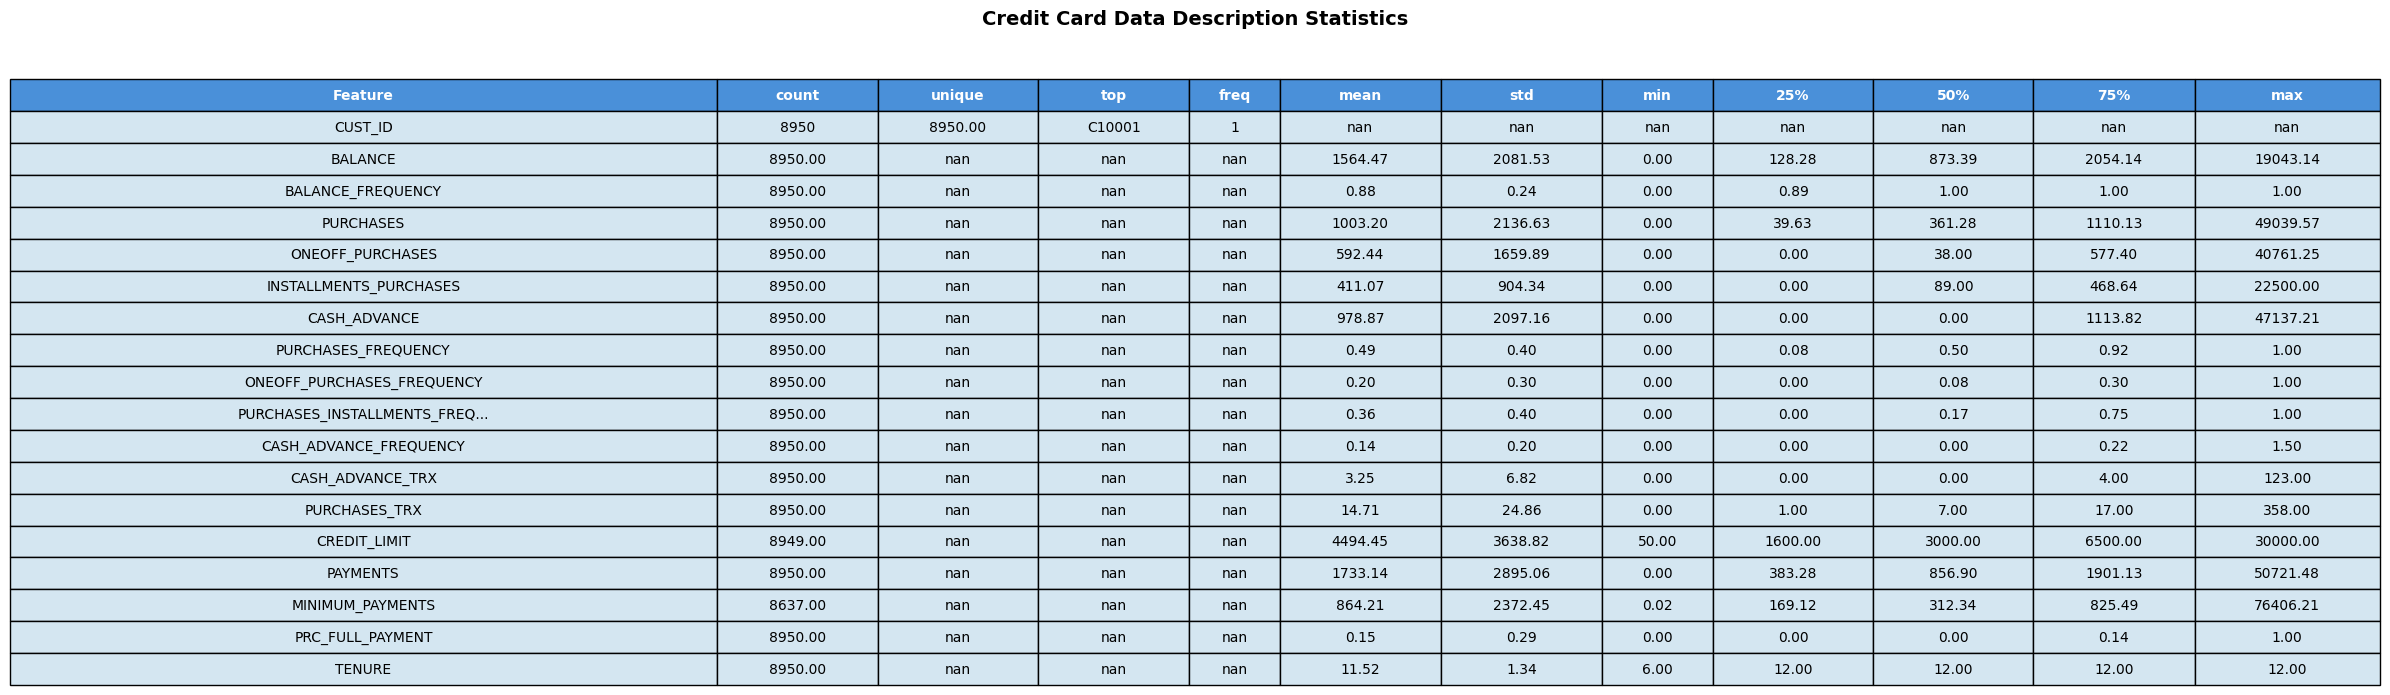

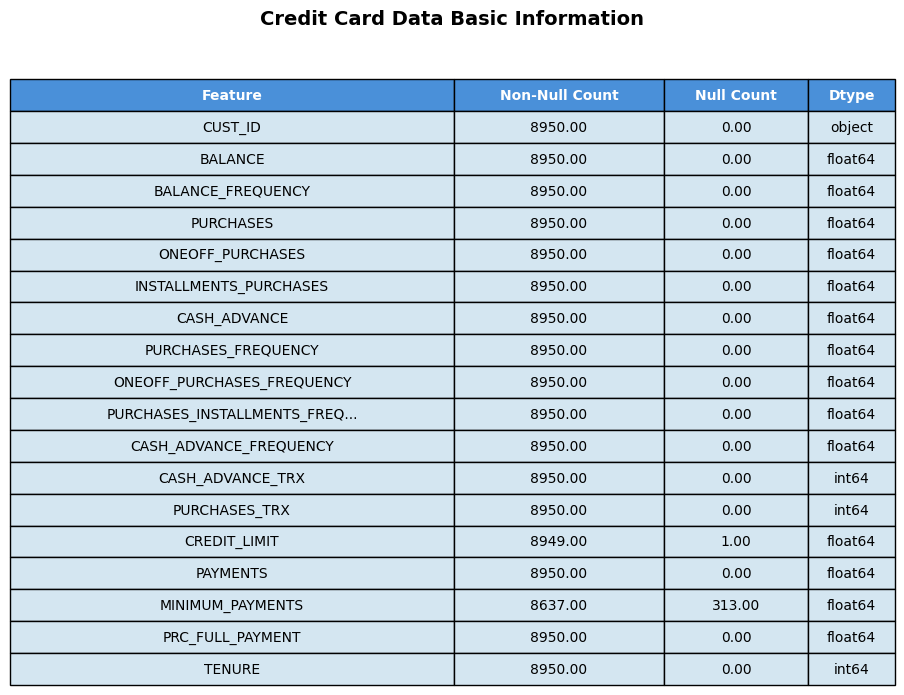

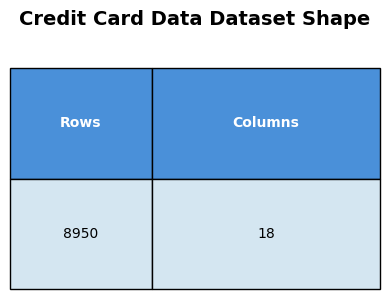




No data to display: Credit Card Data Missing Categorical (String) Data



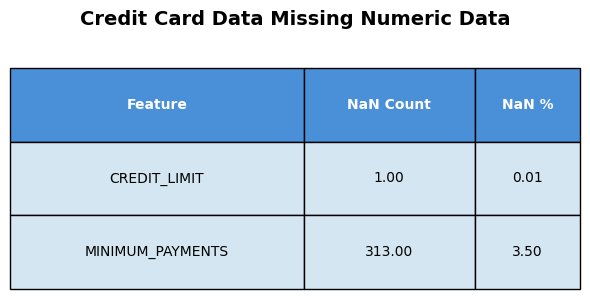

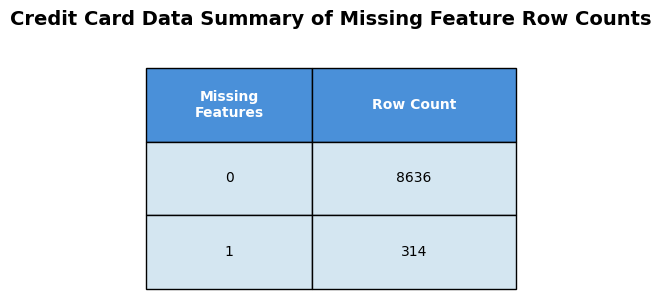

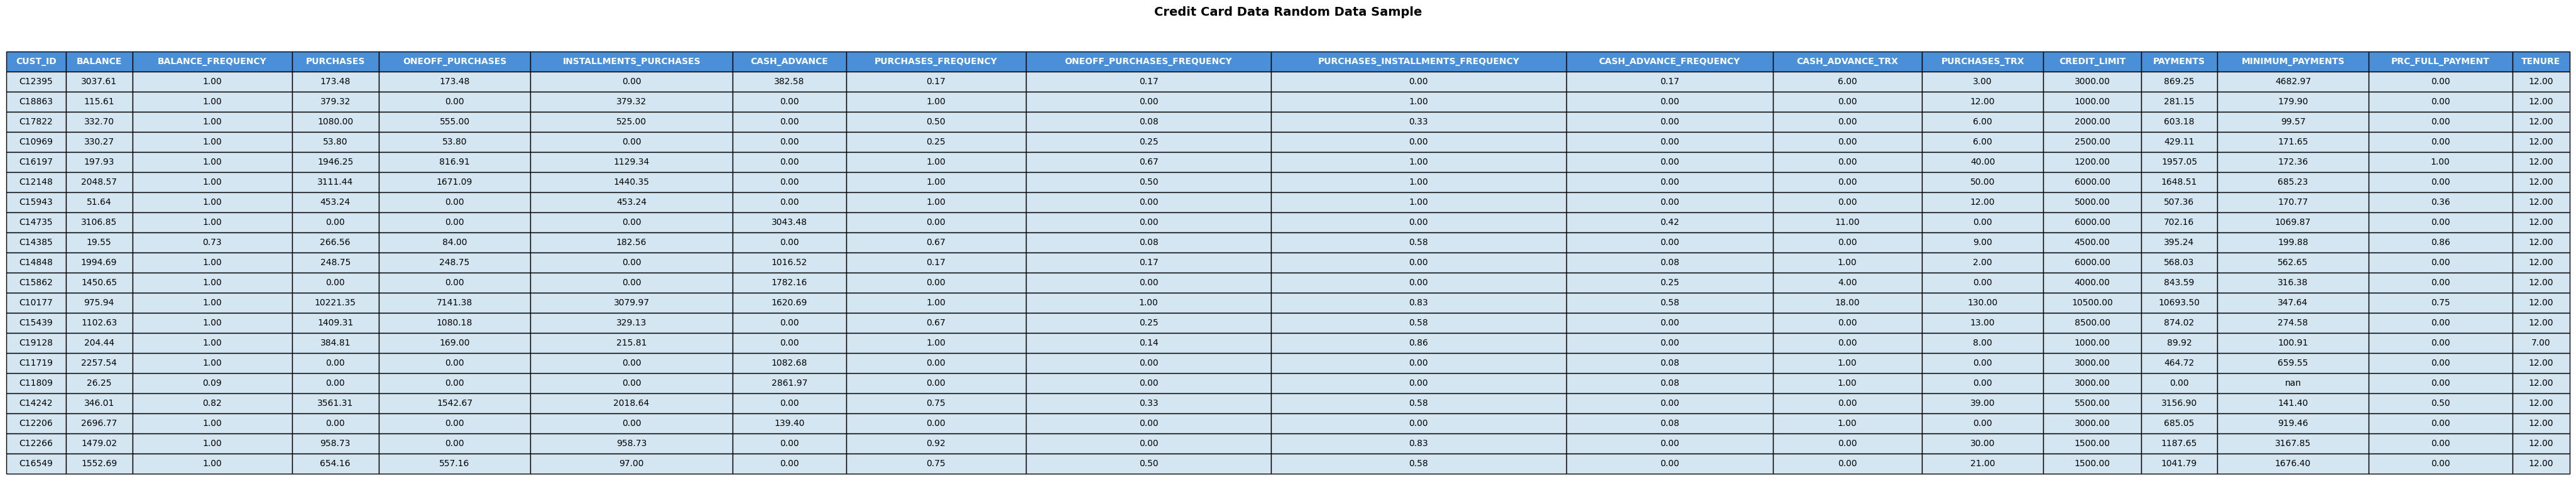

In [4]:
# print out the dataframe stats
PrintDataFrameStatistics(df_CreditCardAgency)

### **Initial EDA Analysis** ###
    - We have 8950 rows of data
    - The dataset has 18 columns of data:
        - 1 categorical feature
        - 17 numeric features
    - We have 314 rows containing missing values
        - MINIMUM_PAYMENTS  - 313 missing values
        - CREDIT_LIMIT      - 1 missing value
    - Missing values need to be imputed.
    - Need to investigate whether missing value columns have actual meaning within datarow/relationship
    - For performance considerations, we should change numeric types where appropriate (int, float32)

### **Missing Values and Imputation** ###

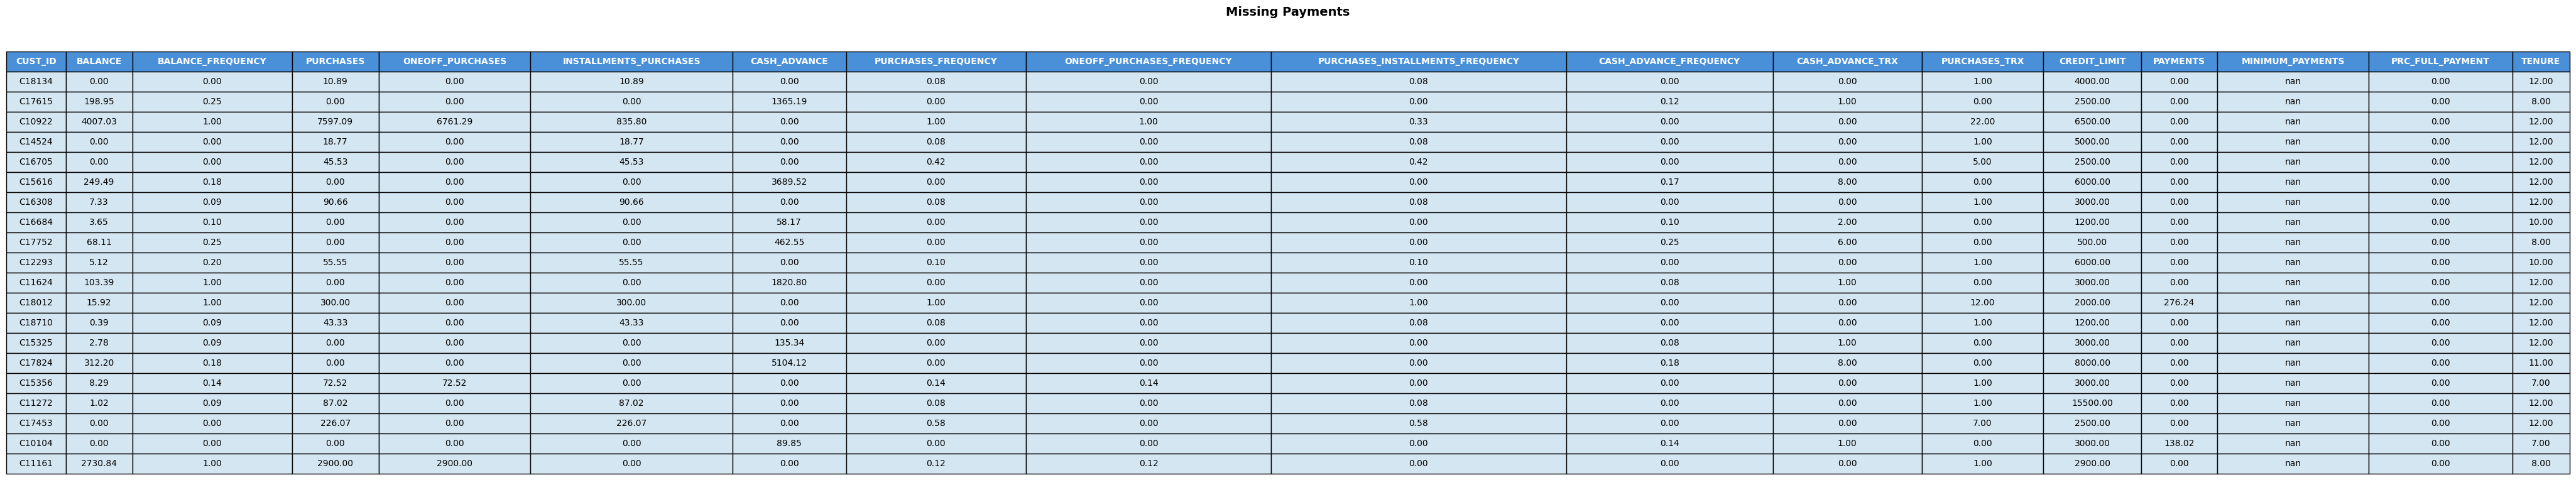

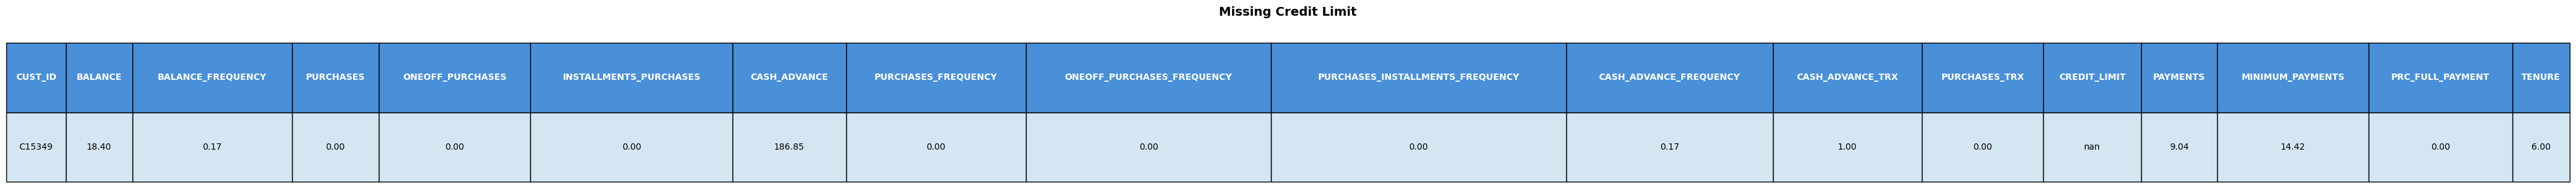

In [5]:
# Examine 
df_MissingPayments = df_CreditCardAgency[df_CreditCardAgency['MINIMUM_PAYMENTS'].isna()]
DisplayTable(df_MissingPayments.sample(n=20), 'Missing Payments')

df_CreditLimit = df_CreditCardAgency[df_CreditCardAgency['CREDIT_LIMIT'].isna()]
DisplayTable(df_CreditLimit, 'Missing Credit Limit')


##### **Missing Values Analysis** #####
    - PAYMENTS = 0 => MISSING_PAYMENT = 0
      Makes sense to imput with zero (0)
    - CREDIT_LIMIT 
      Makes sense to just take median (since there is only 1 instance)

In [6]:
# Imputation

def PerformDataImputation(df_target, display_output=False):
    # MINIMUM_PAYMENTS
    df_target['MINIMUM_PAYMENTS'] = df_target['MINIMUM_PAYMENTS'].fillna(0)

    # CREDIT_LIMIT
    df_target['CREDIT_LIMIT'] = df_target['CREDIT_LIMIT'].fillna(df_target['CREDIT_LIMIT'].median())

    if display_output == True:
        # Examine 
        df_MissingPayments = df_target[df_target['MINIMUM_PAYMENTS'].isna()]
        print(f'Missing MISSING_PAYMENTs Count:{len(df_MissingPayments)}')

        df_CreditLimit = df_target[df_target['CREDIT_LIMIT'].isna()]
        print(f'Missing CREDIT_LIMITs Count:{len(df_CreditLimit)}')

    return df_target

df_CreditCardAgency = PerformDataImputation(df_CreditCardAgency, display_output=True)

Missing MISSING_PAYMENTs Count:0
Missing CREDIT_LIMITs Count:0


### **Data Type Conversion** ###

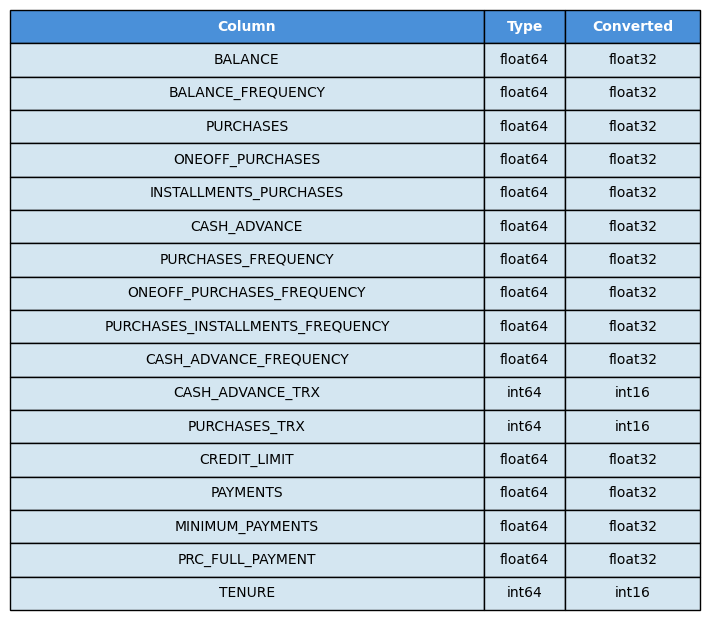



Converted Data Columns


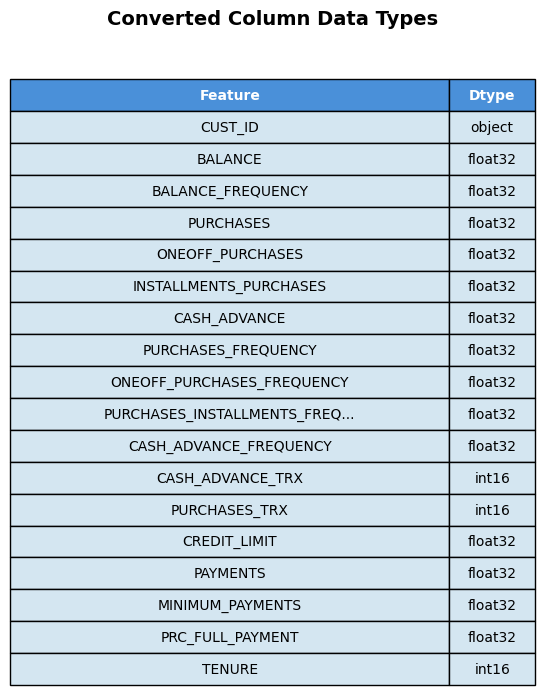

In [7]:
# Type Conversion
df_types = pd.DataFrame({
                            'Column': [
                                'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
                                'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
                                'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
                                'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
                                'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'
                            ],
                            'Type': [
                                'float64', 'float64', 'float64', 'float64', 'float64', 'float64',
                                'float64', 'float64', 'float64', 'float64', 'int64', 'int64',
                                'float64', 'float64', 'float64', 'float64', 'int64'
                            ],
                            'Converted': [
                                'float32', 'float32', 'float32', 'float32', 'float32', 'float32',
                                'float32', 'float32', 'float32', 'float32', 'int16', 'int16',
                                'float32', 'float32', 'float32', 'float32', 'int16'
                            ]
                        })

DisplayTable(df_types, max_cell_length=60)

def PerformDataConversion(df_target, display_output=False):

    # Convert Floats
    float_columns = ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
                    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
                    'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
                    'CASH_ADVANCE_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
                    'PRC_FULL_PAYMENT']
    df_target[float_columns] = df_target[float_columns].astype('float32')


    # Convert Ints
    int_columns = ['CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'TENURE']
    df_target[int_columns] = df_target[int_columns].astype('int16')

    if display_output == True:
        print('Converted Data Columns')

        df_info = pd.DataFrame({
                                'Feature': df_target.columns,
                                'Dtype': df_target.dtypes.values
                                }).reset_index(drop=True)
        DisplayTable(df_info, 'Converted Column Data Types')
    
    return df_target

df_CreditCardAgency = PerformDataConversion(df_CreditCardAgency, display_output=True)

##### **Examining Normalized Values** #####
    - It looks like the following columns are normalized Values (0.0 - 1.0)
        BALANCE_FREQUENCY
        PURCHASES_FREQUENCY
        ONEOFF_PURCHASES_FREQUENCY
        PURCHASES_INSTALLMENTS_FREQUENCY
        CASH_ADVANCE_FREQUENCY
        PRC_FULL_PAYMENT

    - A quick eyeball examination shows that CASH_ADVANCE_FREQUENCY looks like it has 1 or more values > 1.0 (outlier/anamoly)

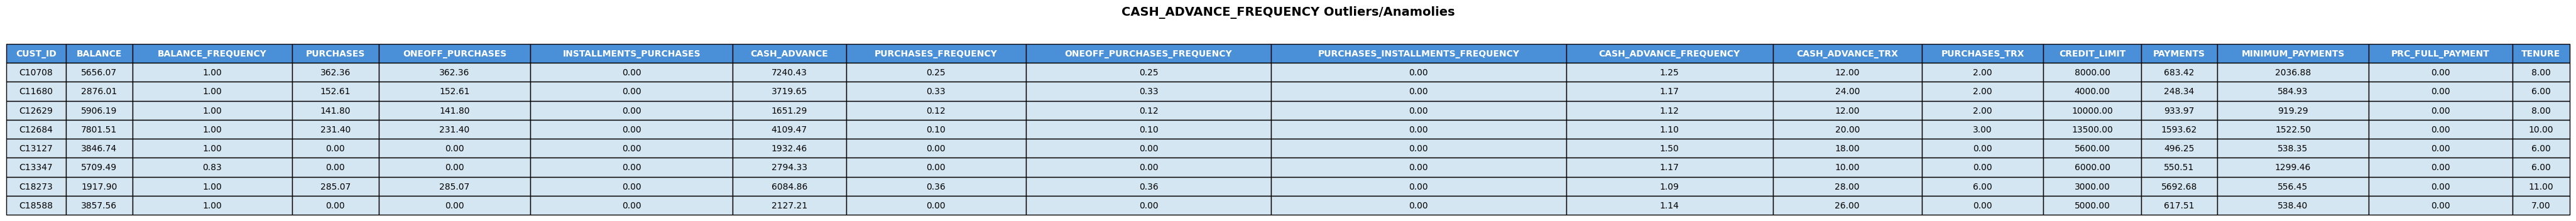

In [8]:
# How many outliers/anamolies do we have for CASH_ADVANCE_FREQUENCY

df_cashadvancefrequency_outliers = df_CreditCardAgency[df_CreditCardAgency_Original['CASH_ADVANCE_FREQUENCY'] > 1]
DisplayTable(df_cashadvancefrequency_outliers, 'CASH_ADVANCE_FREQUENCY Outliers/Anamolies')

#### **Plot Histograms of Numeric Data Columns** ####

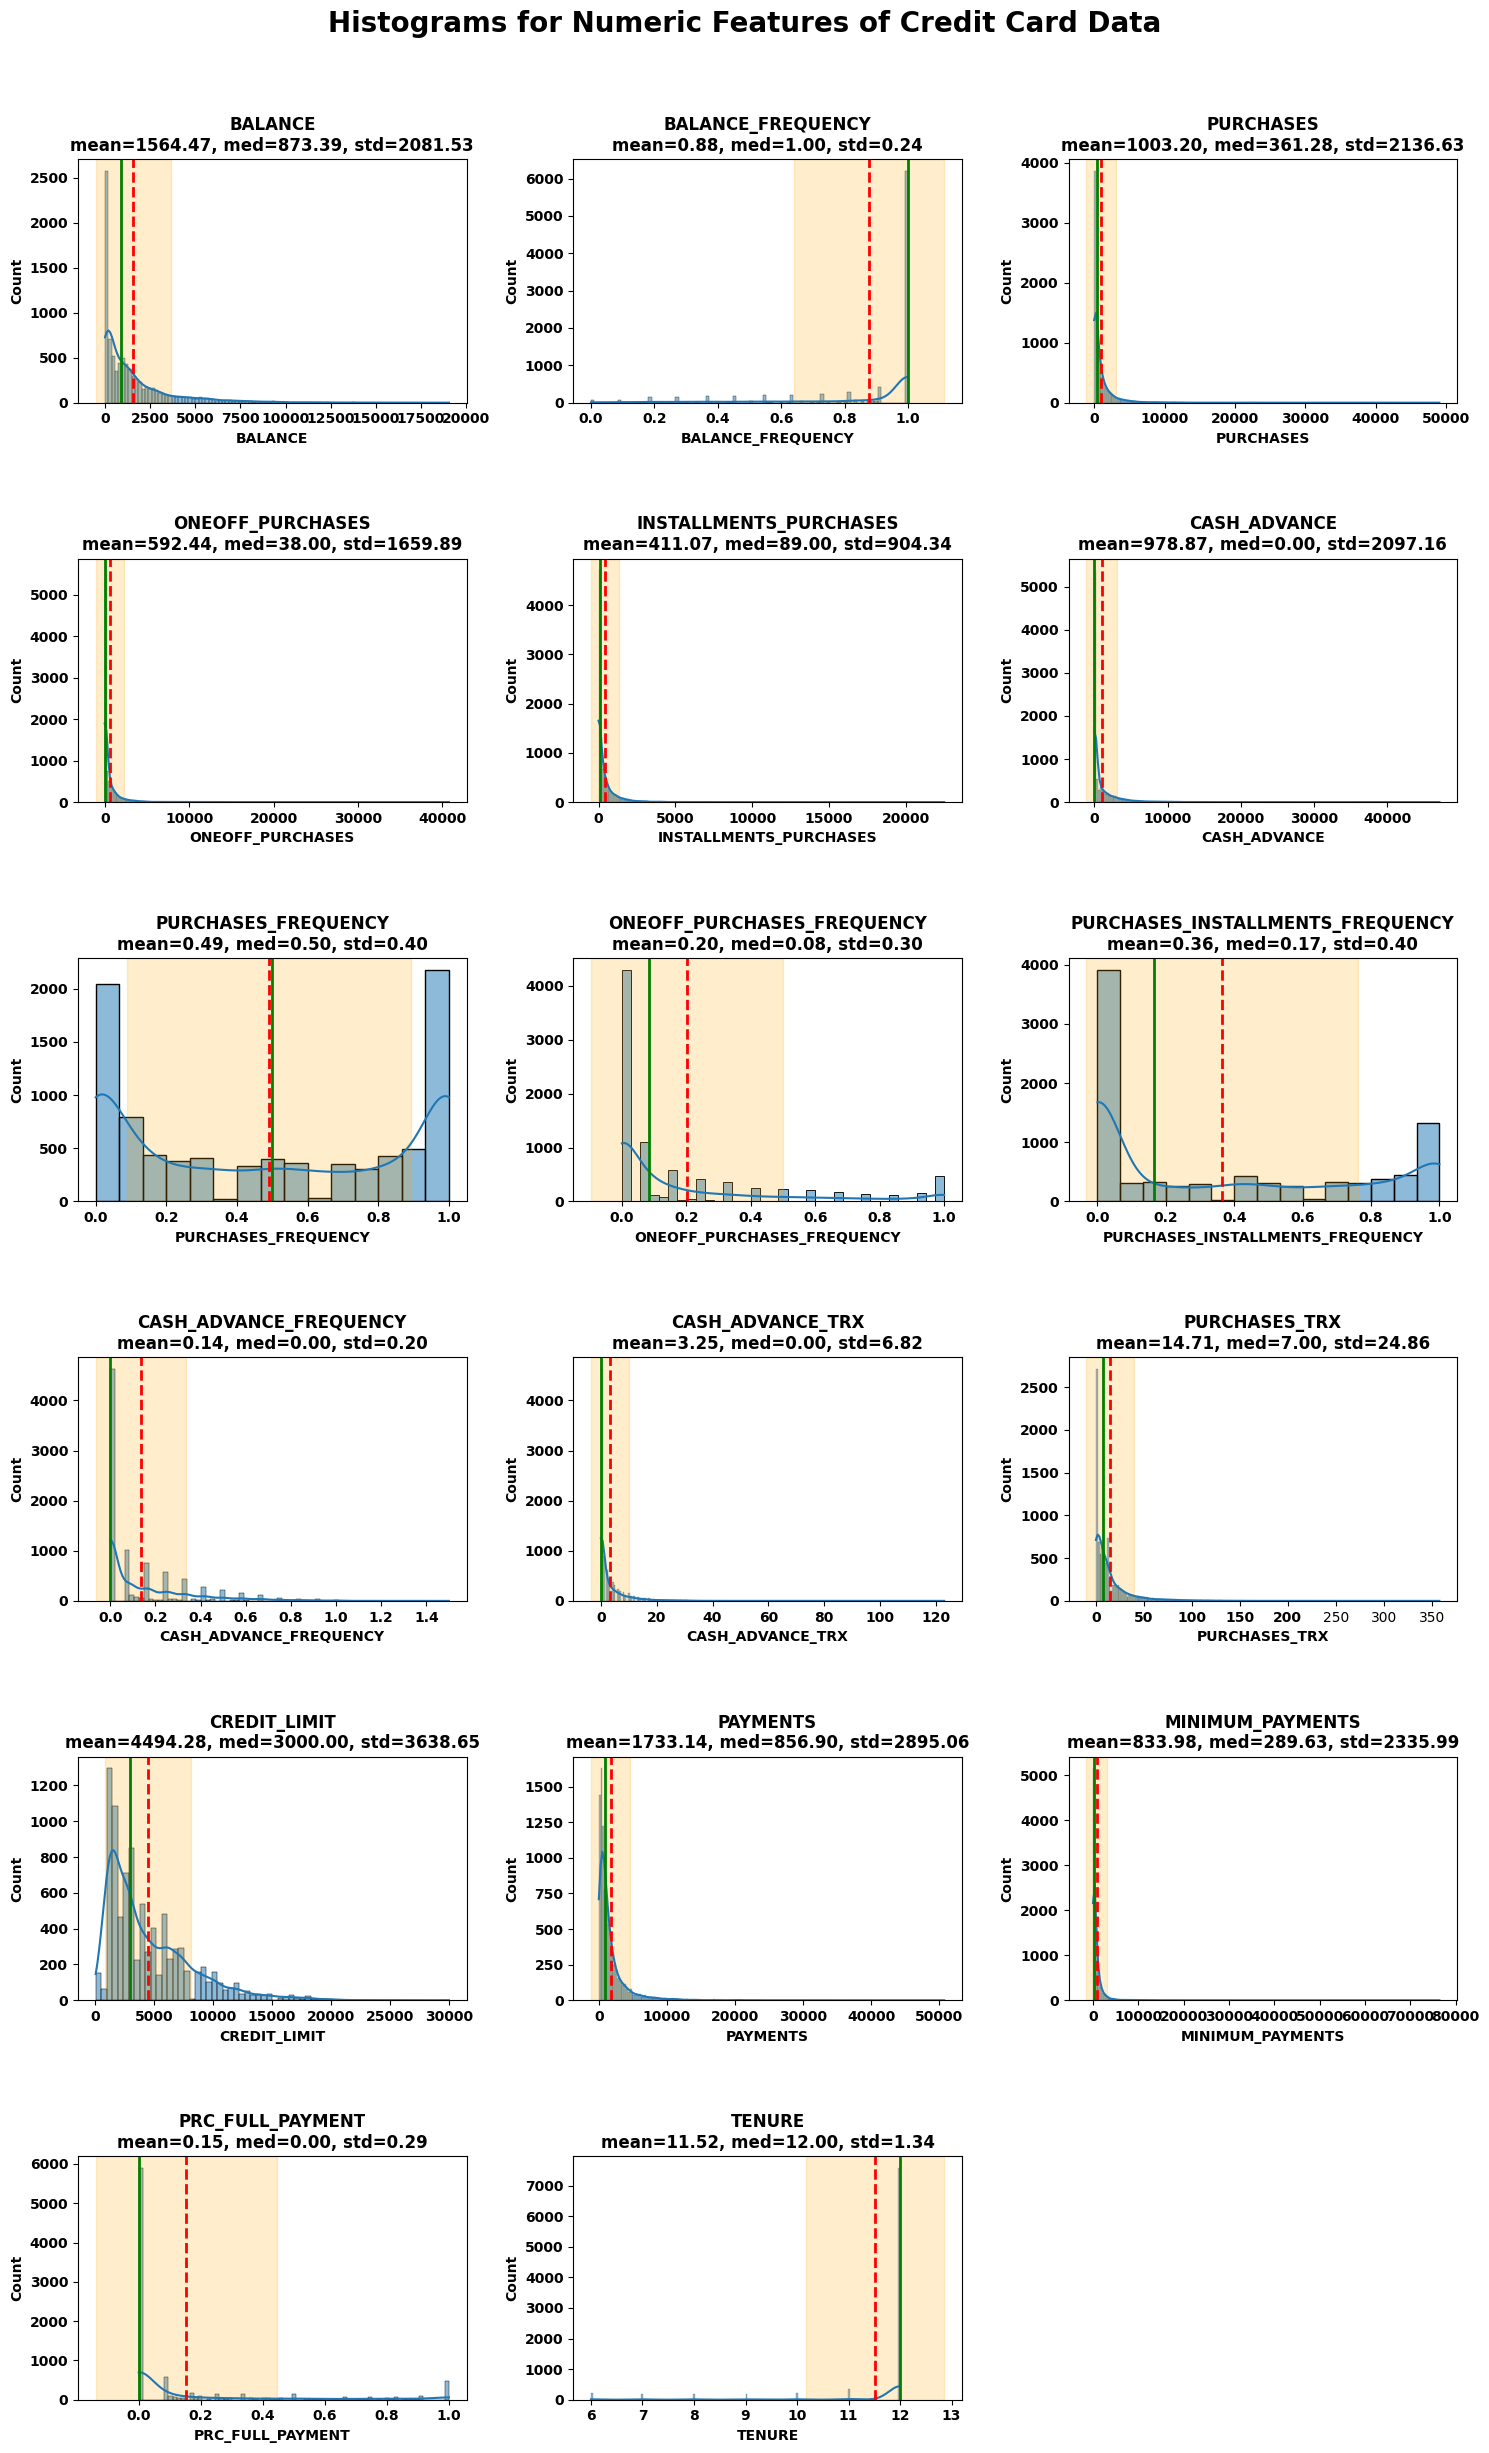

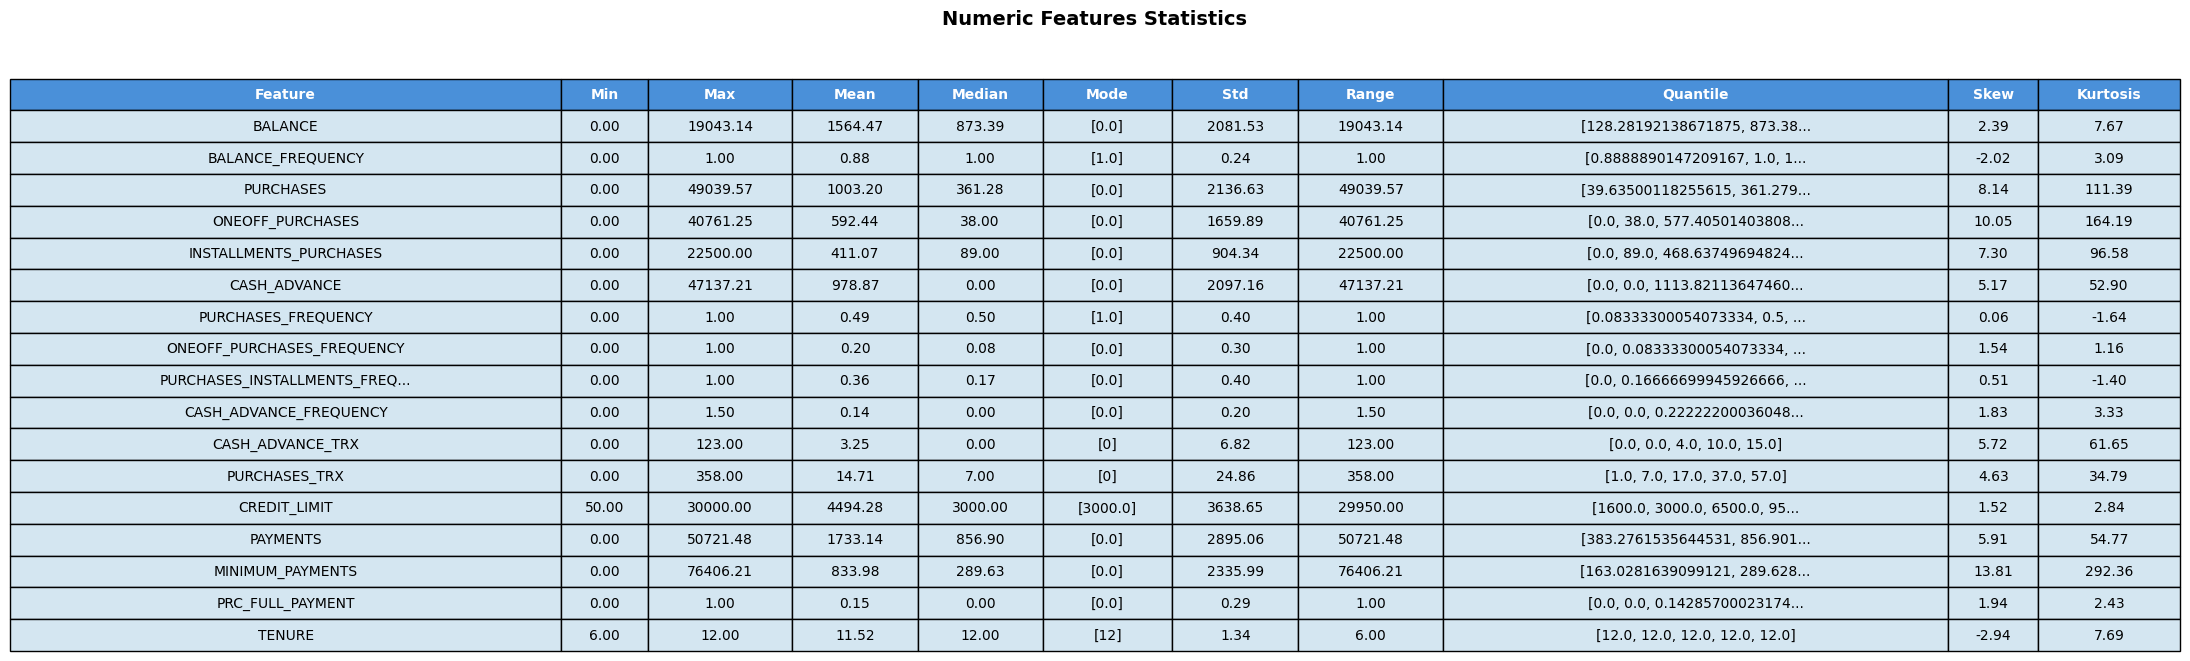

In [9]:
def DisplayNumericFeatureHistograms(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        data = df_target[col]

        if display_statistics == True:

            min_val = data.min()
            max_val = data.max()
            range_val = data.max() - data.min()
            mean_val = data.mean()
            median_val = data.median()
            mode_val = data.mode().tolist()
            std_val = data.std()
            quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
            skew_val = data.skew()
            kurtosis_val = data.kurtosis()

            stats = {
                'Feature': col,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std': std_val,
                'Range': range_val,
                'Quantile': quantile_val,
                'Skew': skew_val,
                'Kurtosis': kurtosis_val
            }            

            statistics.append(stats)

            # print(f'Min Value: {min_val:.3f}')
            # print(f'Max Value: {max_val:.3f}')
            # print(f'Mean Value: {mean_val:.3f}')
            # print(f'Median Value: {median_val:.3f}')
            # print(f'Mode Value: {mode_val}')
            # print(f'Standard Deviation: {std_val:.3f}')
            # print(f'Range Value = {range_val:.3f}')
            # print(f'Quantile Value = {quantile_val}')
            # print(f'Skew Value: {skew_val:.3f}')
            # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

            axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

            # Vertical lines for mean and median, shaded std
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
            axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

        else:
            axes[i].set_title(f'{col}', fontweight='bold')
        
        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(f'Histograms for Numeric Features of {data_set_name}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

    if display_statistics == True:
        df_statistics = pd.DataFrame(statistics)
        DisplayTable(df_statistics, 'Numeric Features Statistics')

def PlotBoxPlotsToViewDistributions(df_target, feature_columns = None, target_label=None, plot_title=None):

    cols_to_plot = []
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3X4 plot to display 10 histograms
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    #Iterate over each numeric column and plot a historgram
    for i, col in enumerate(cols_to_plot):

        sns.boxplot(data=df_target, y=col, ax=axes[i])    
        axes[i].set_title(col, fontweight='bold')

        # Optional: Add count of outliers
        Q1 = df_target[col].quantile(0.25)
        Q3 = df_target[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = len(df_target[(df_target[col] < lower) | 
                                            (df_target[col] > upper)])
        axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                    transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')
        
    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Box Plots for Numeric Features of {data_set_name}'

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])        

    plt.suptitle(title, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top
    #plt.subplots_adjust(top=0.92)        

    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show() 

    print()
    print()
    
#
#
#
DisplayNumericFeatureHistograms(df_CreditCardAgency) 

#### **Initial Observations Raw Numeric Feature Histograms** ####
        BALANCE                             - Right Skewed Distribution
        BALANCE_FREQUENCY                   - Left Skewed Distribution
        PURCHASES                           - Right Skewed Distribution
        ONEOFF_PURCHASES                    - Right Skewed Distribution
        INSTALLMENTS_PURCHASES              - Right Skewed Distribution
        CASH_ADVANCE                        - Right Skewed Distribution
        PURCHASES_FREQUENCY                 - Inverse Normal Distribution? (2 peaks and a valley)
        ONEOFF_PURCHASES_FREQUENCY          - Right Skewed Distribution
        PURCHASES_INSTALLMENTS_FREQUENCY    - Right Skewed Distribution
        CASH_ADVANCE_FREQUENCY              - Right Skewed Distribution
        CASH_ADVANCE_TRX                    - Right Skewed Distribution
        PURCHASES_TRX                       - Normal Distribution
        CREDIT_LIMIT                        - Right Skewed Distribution
        PAYMENTS                            - Right Skewed Distribution
        MINIMUM_PAYMENTS                    - Right Skewed Distribution
        PRC_FULL_PAYMENT                    - Right Skewed Distribution
        TENURE                              - Left Skewed Distribution
    

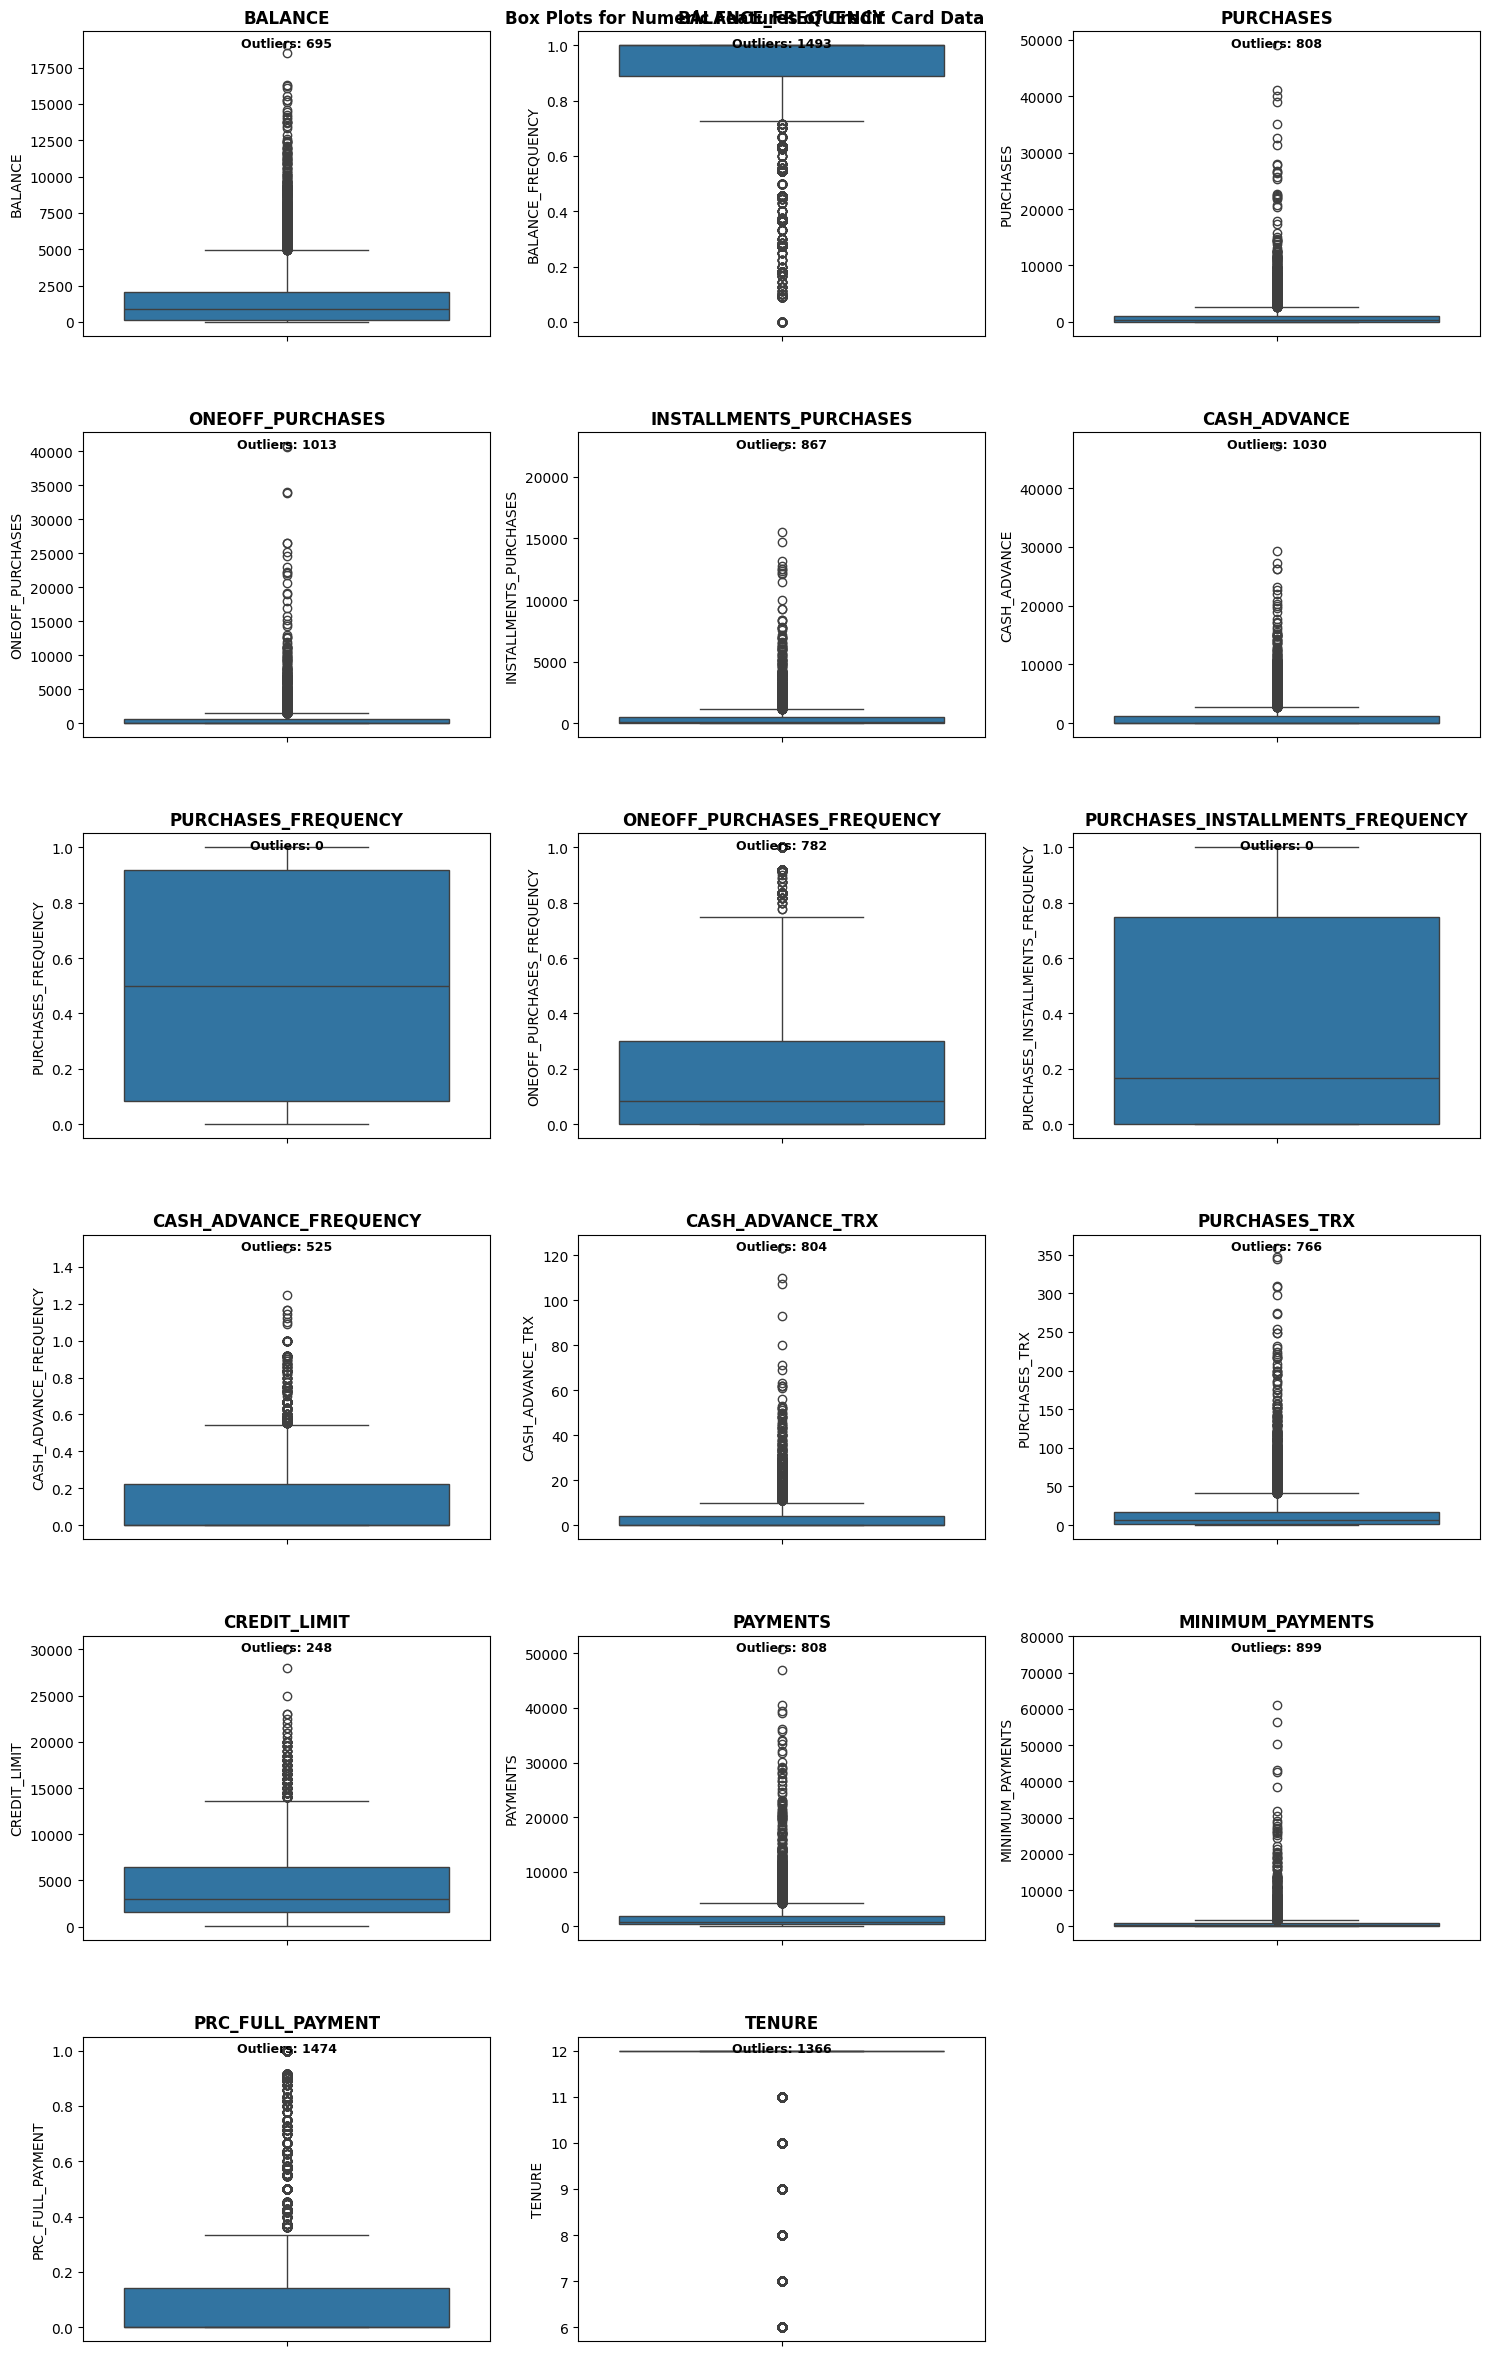

In [10]:
PlotBoxPlotsToViewDistributions(df_CreditCardAgency)

#### **Outliers Analysis** ####
    The following features have a considerable amount of outliers.
        BALANCE                             
        BALANCE_FREQUENCY                   
        PURCHASES                           
        ONEOFF_PURCHASES                    
        INSTALLMENTS_PURCHASES              
        CASH_ADVANCE                        
        ONEOFF_PURCHASES_FREQUENCY          
        CASH_ADVANCE_FREQUENCY              
        CASH_ADVANCE_TRX                    
        PURCHASES_TRX                       
        CREDIT_LIMIT                        
        PAYMENTS                            
        MINIMUM_PAYMENTS                    
        PRC_FULL_PAYMENT                    
        TENURE                                  

##

##### **Compare Normalization Techniques** #####

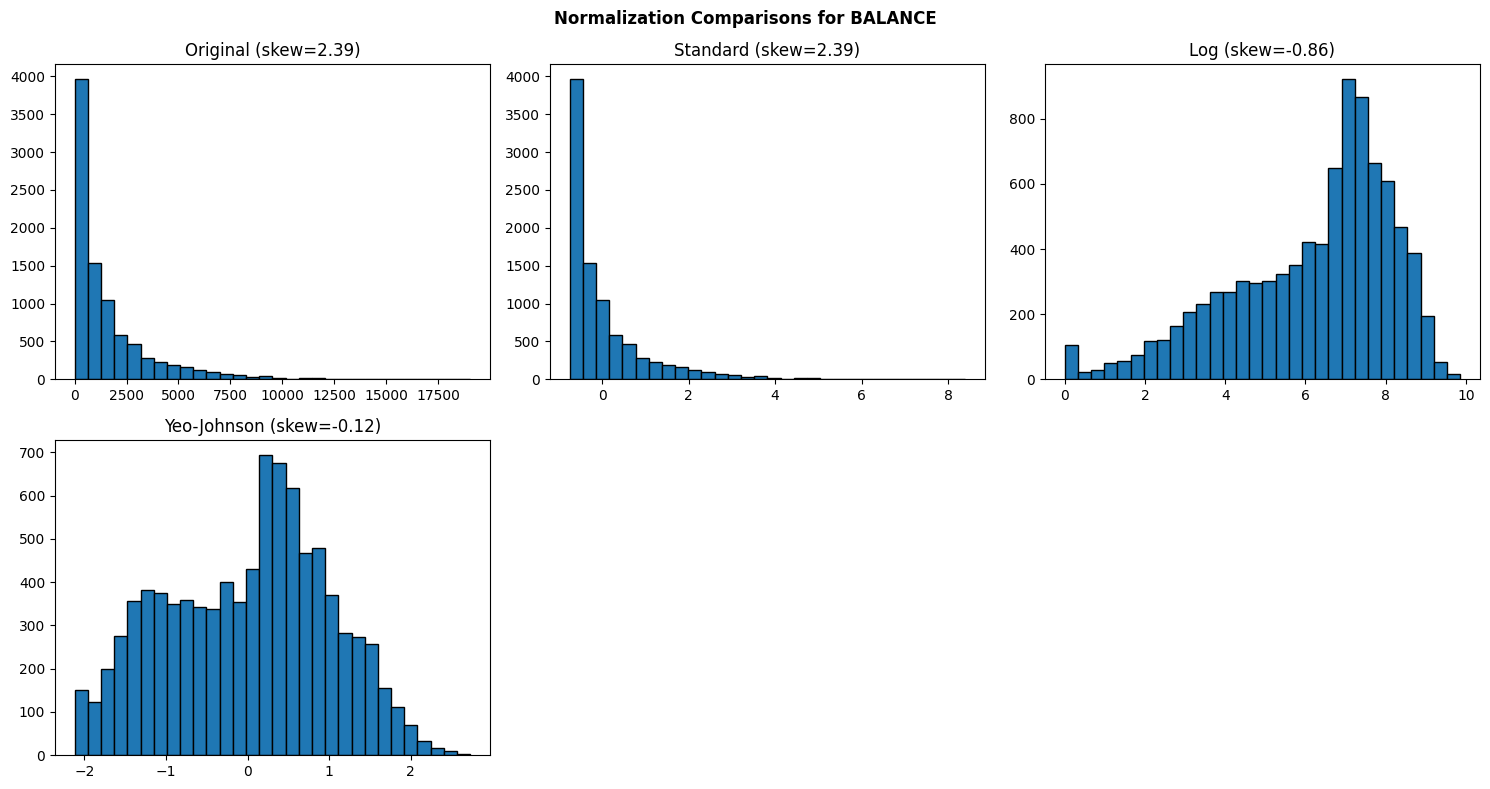

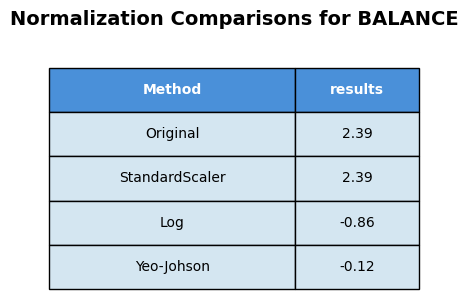

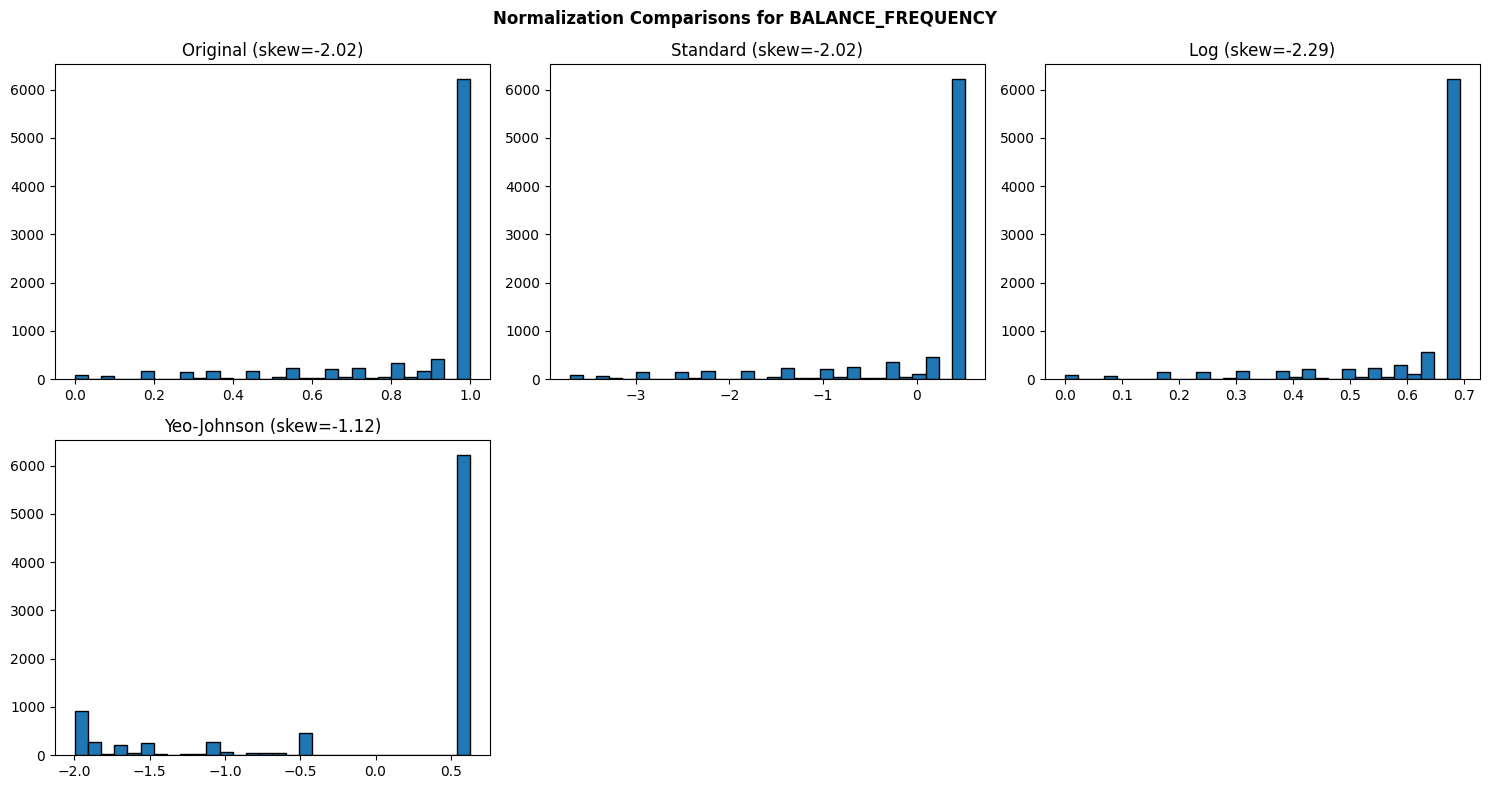

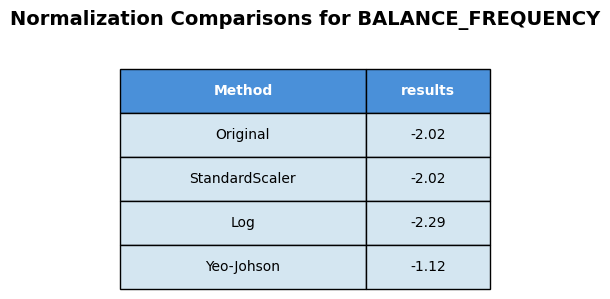

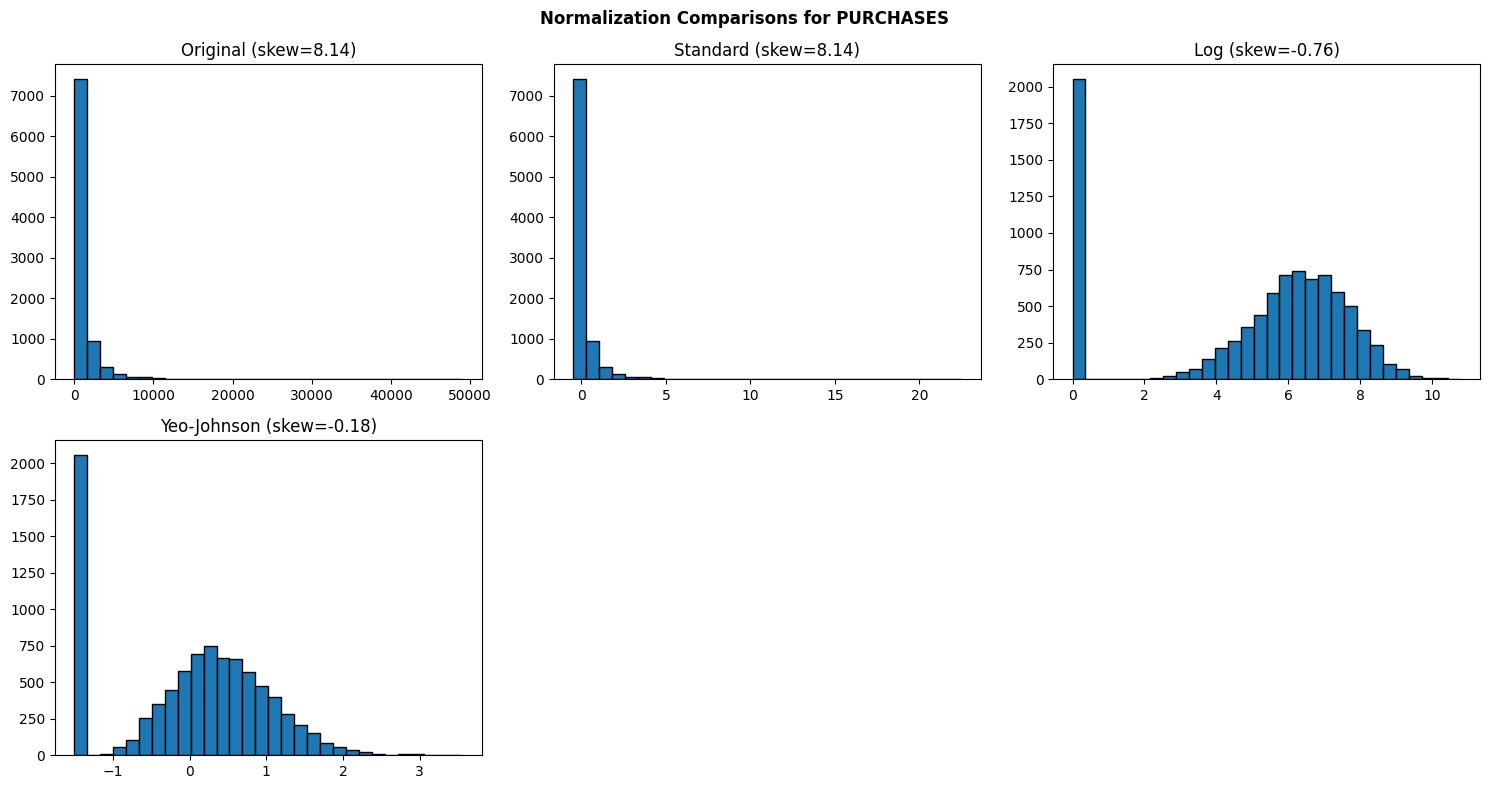

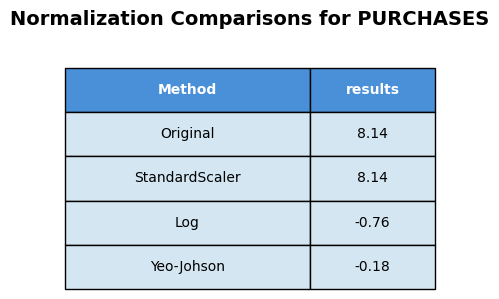

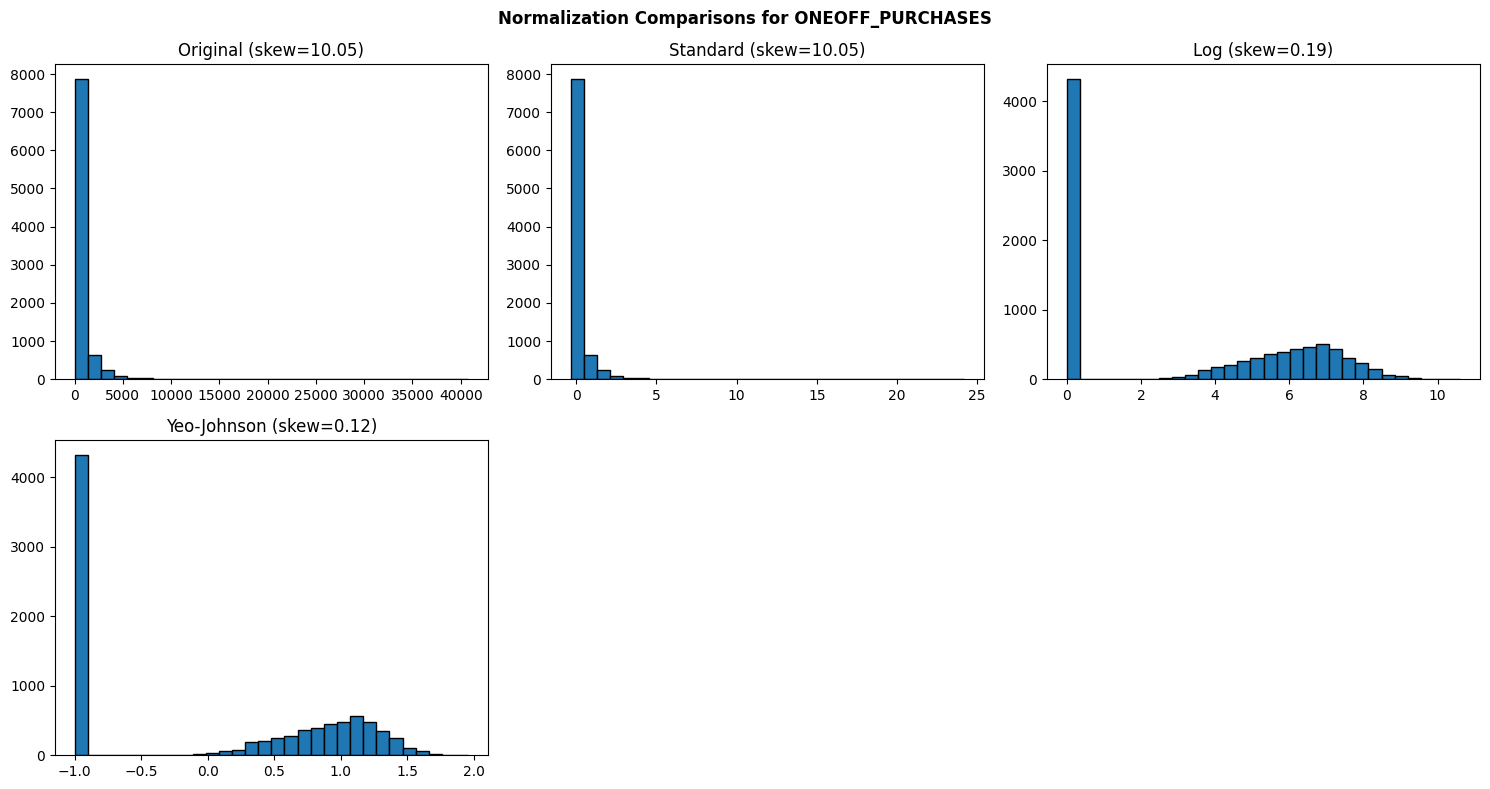

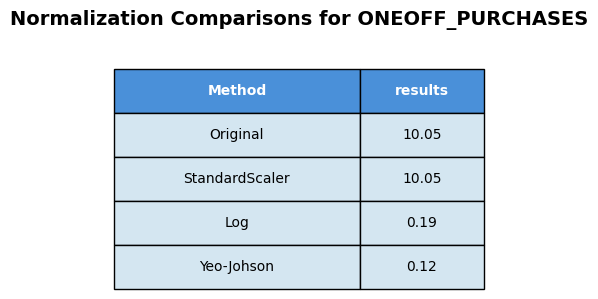

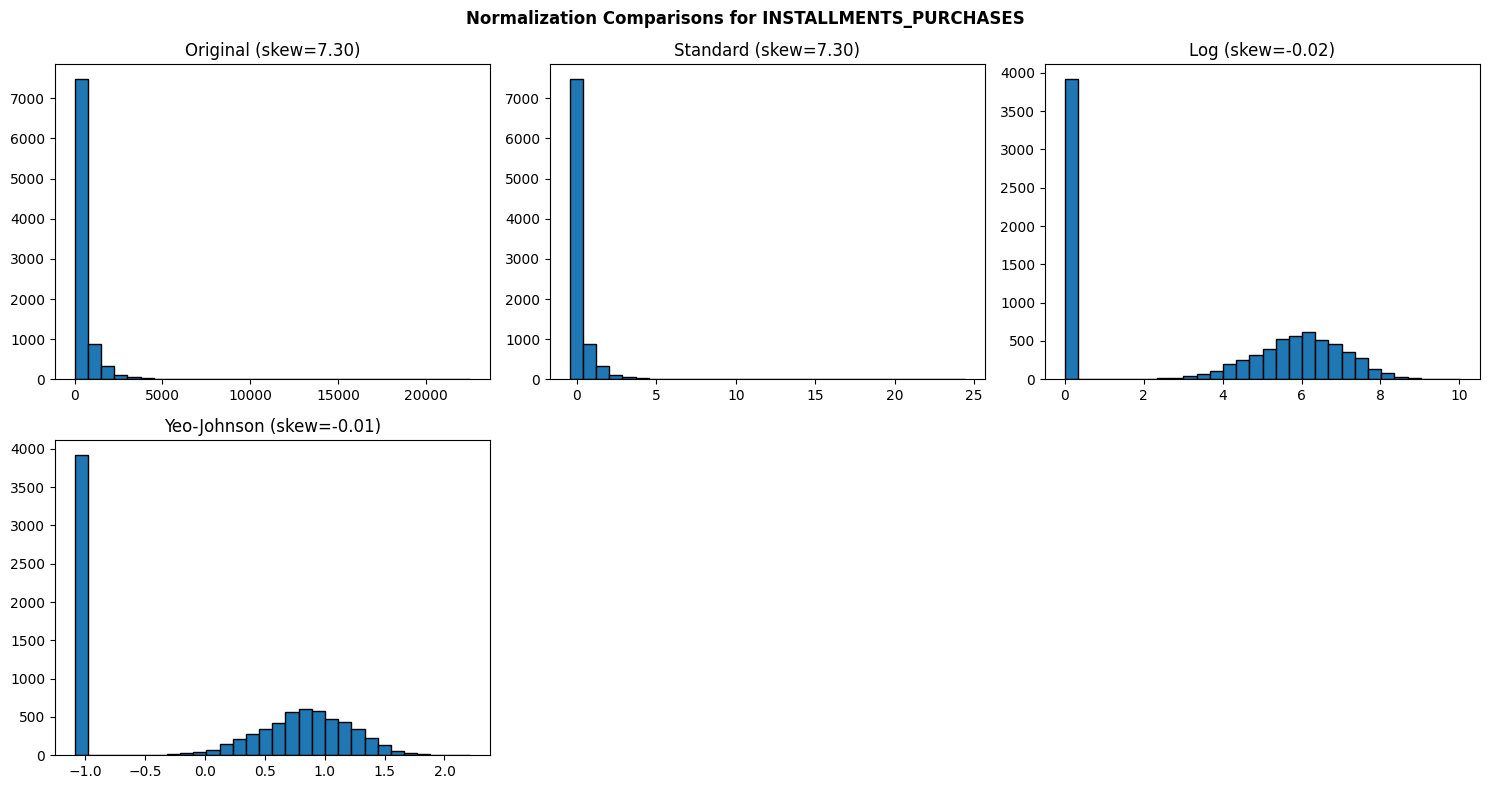

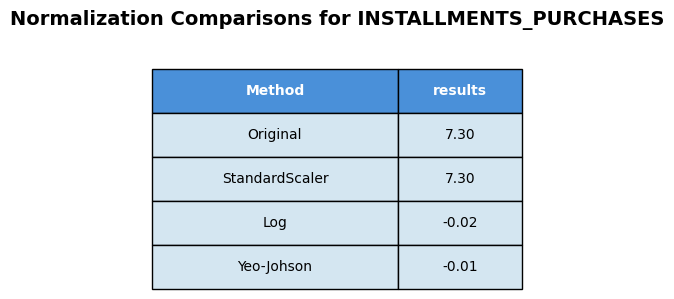

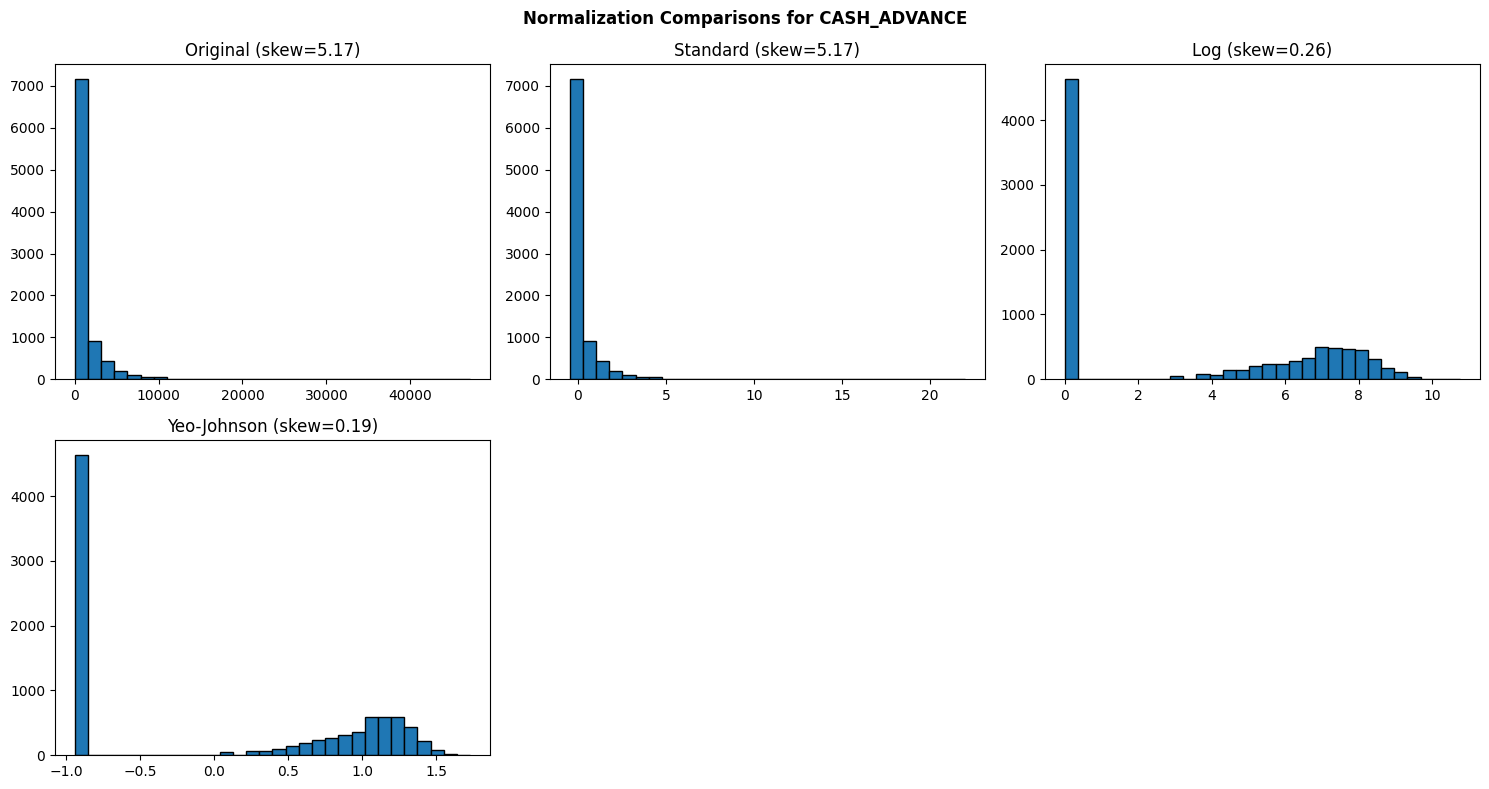

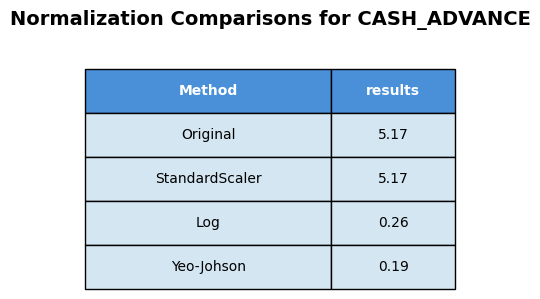

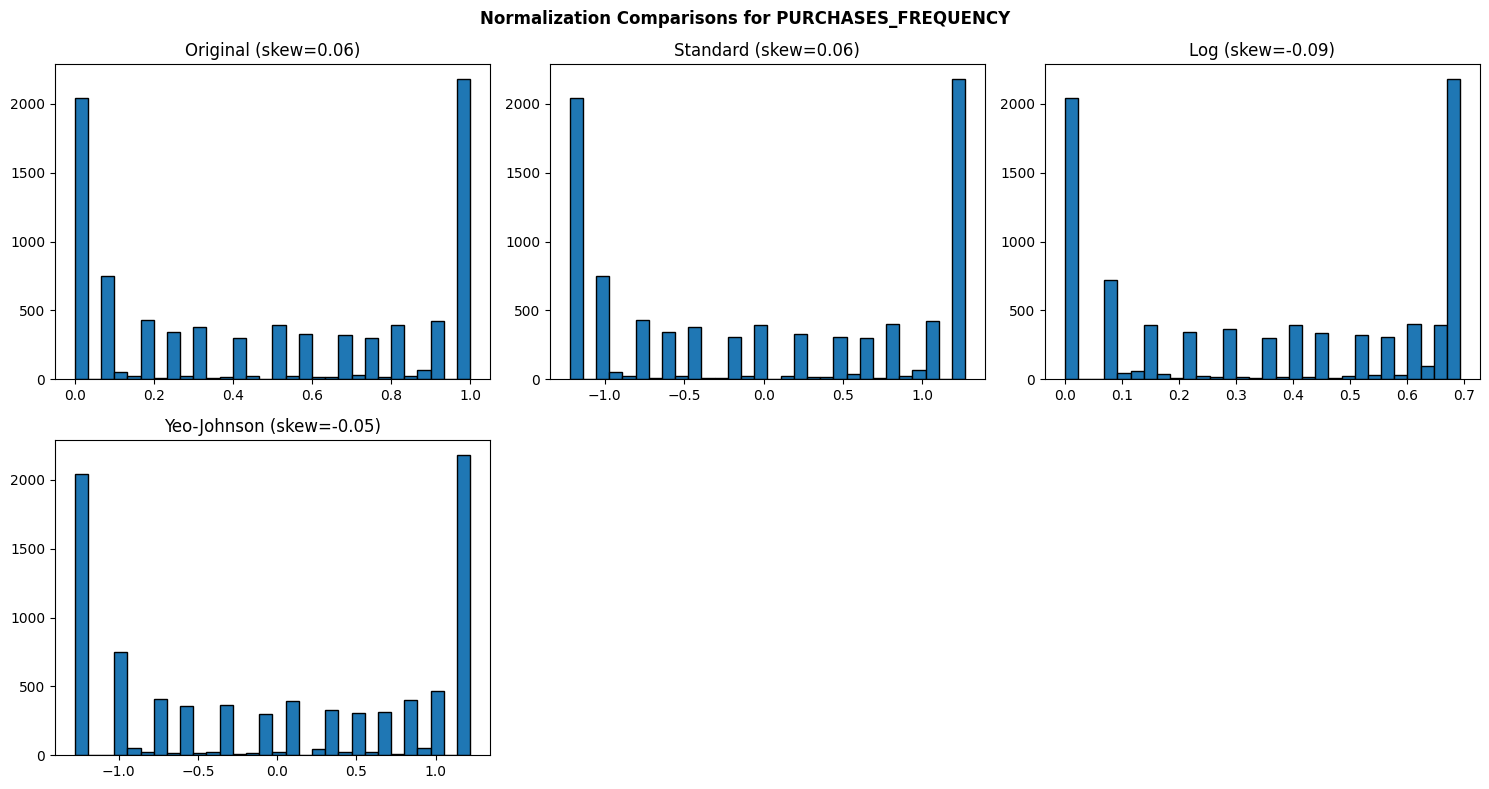

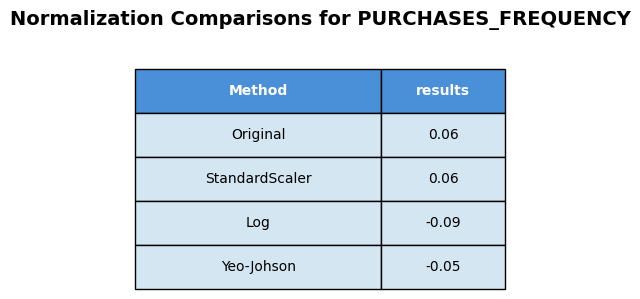

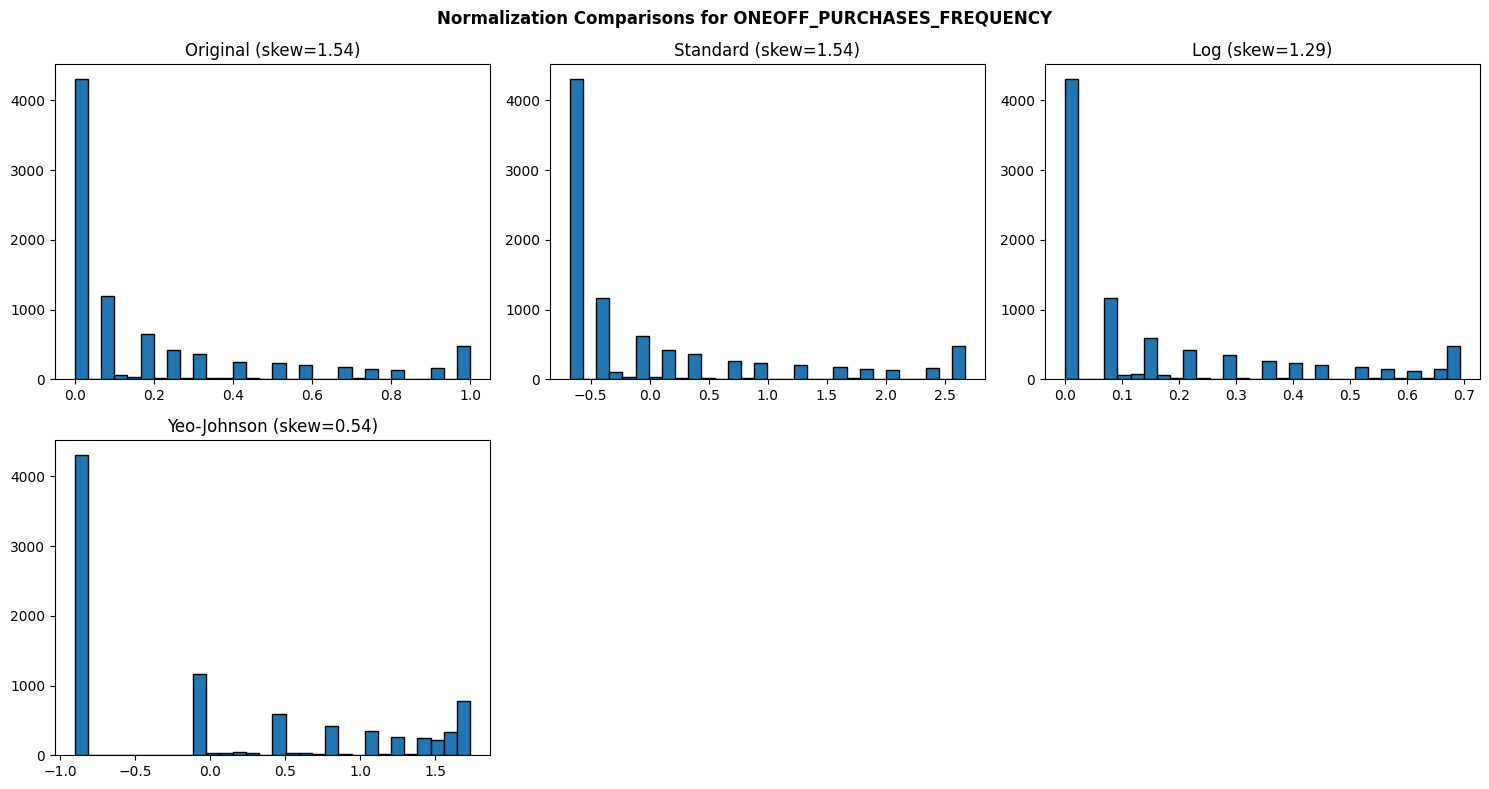

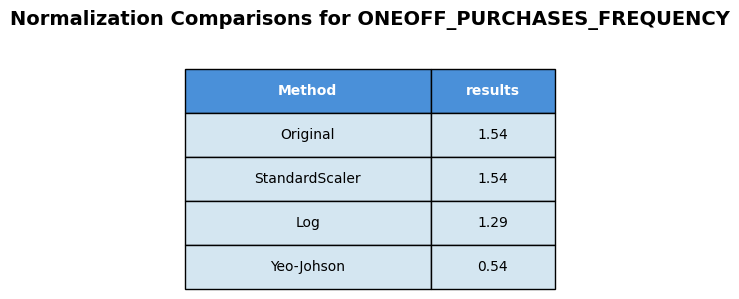

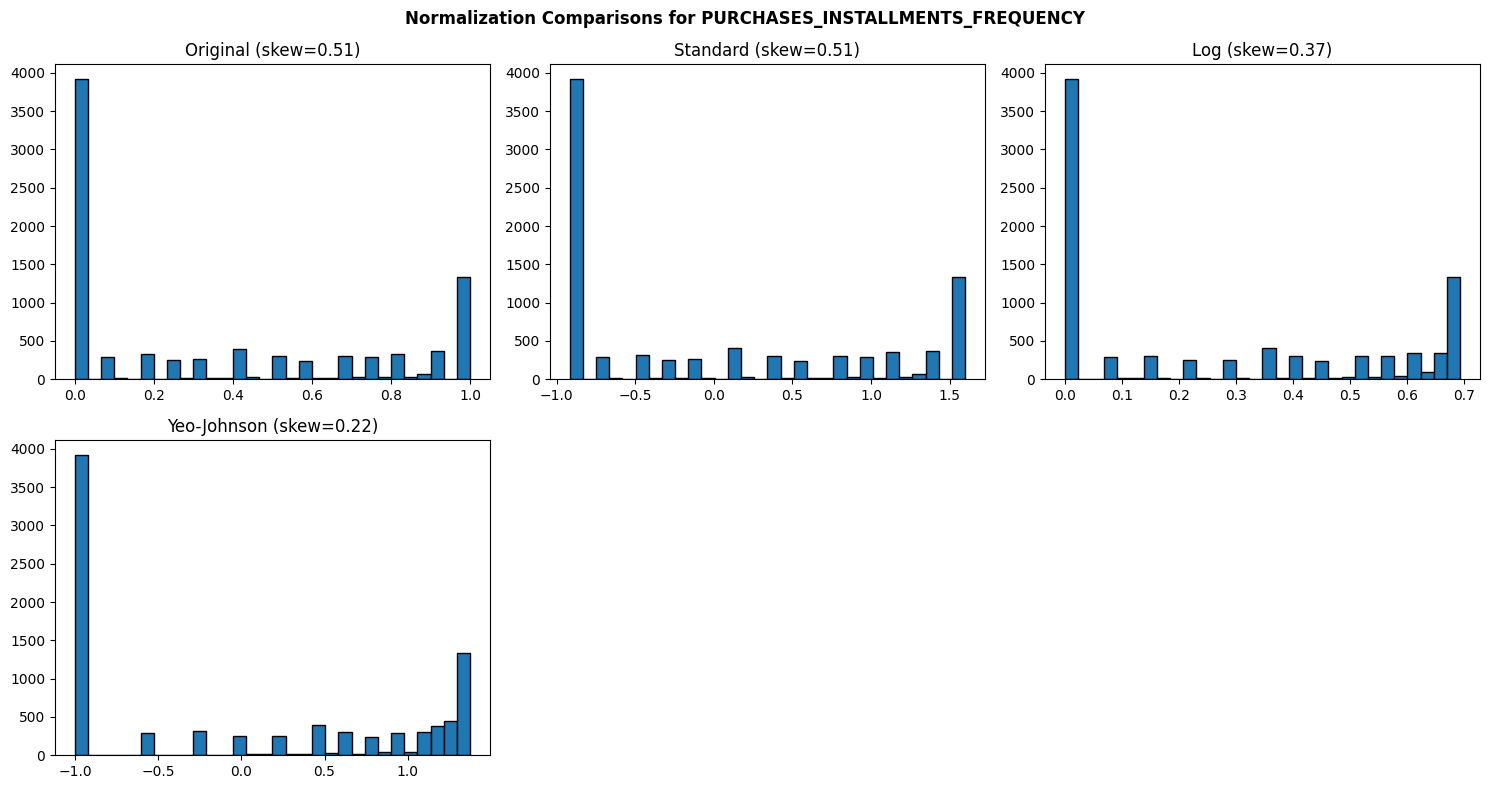

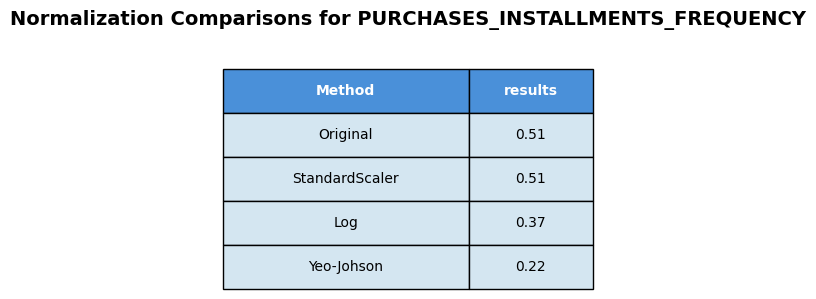

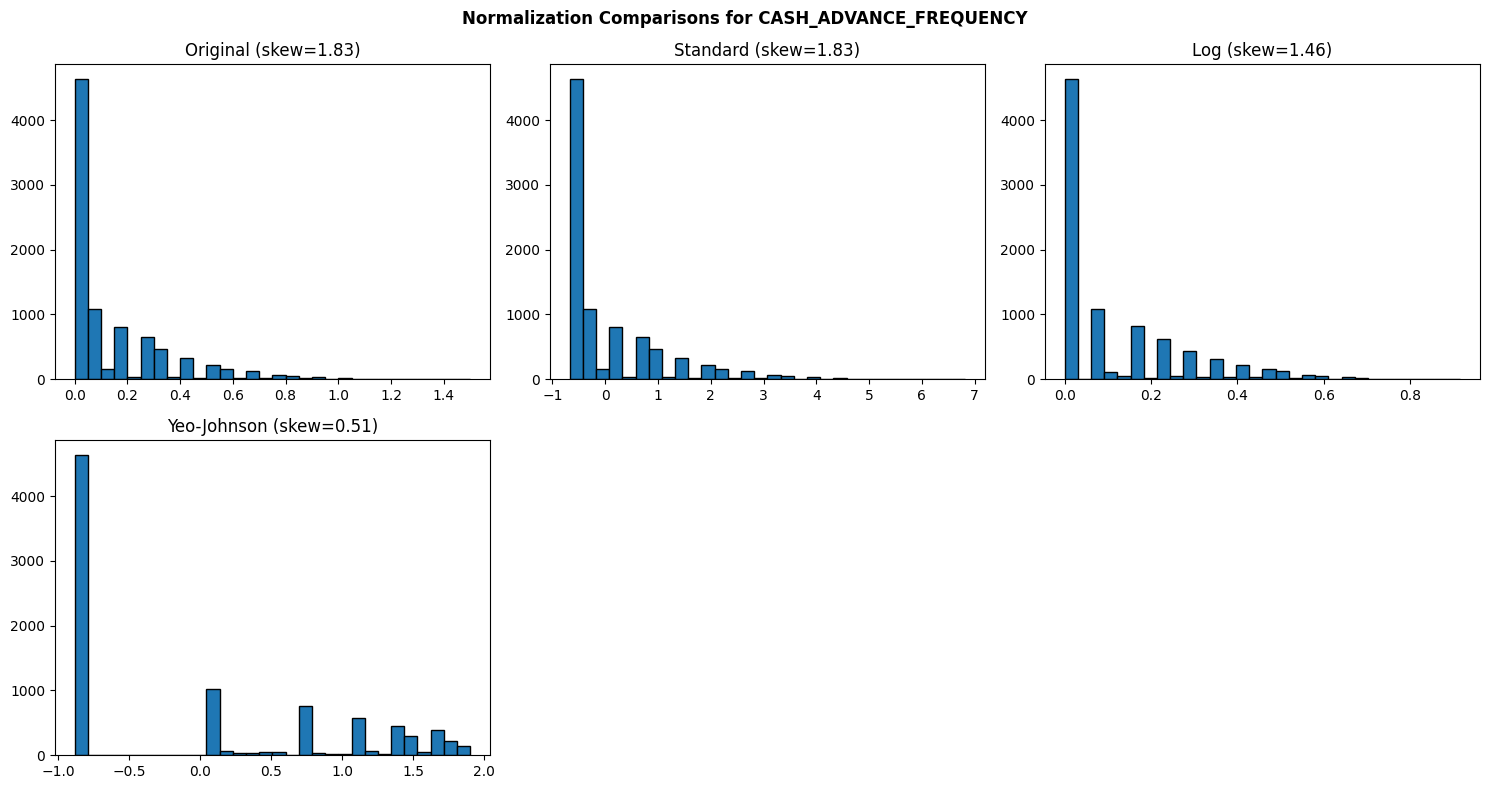

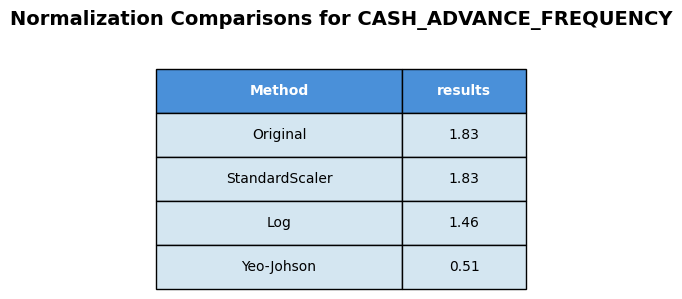

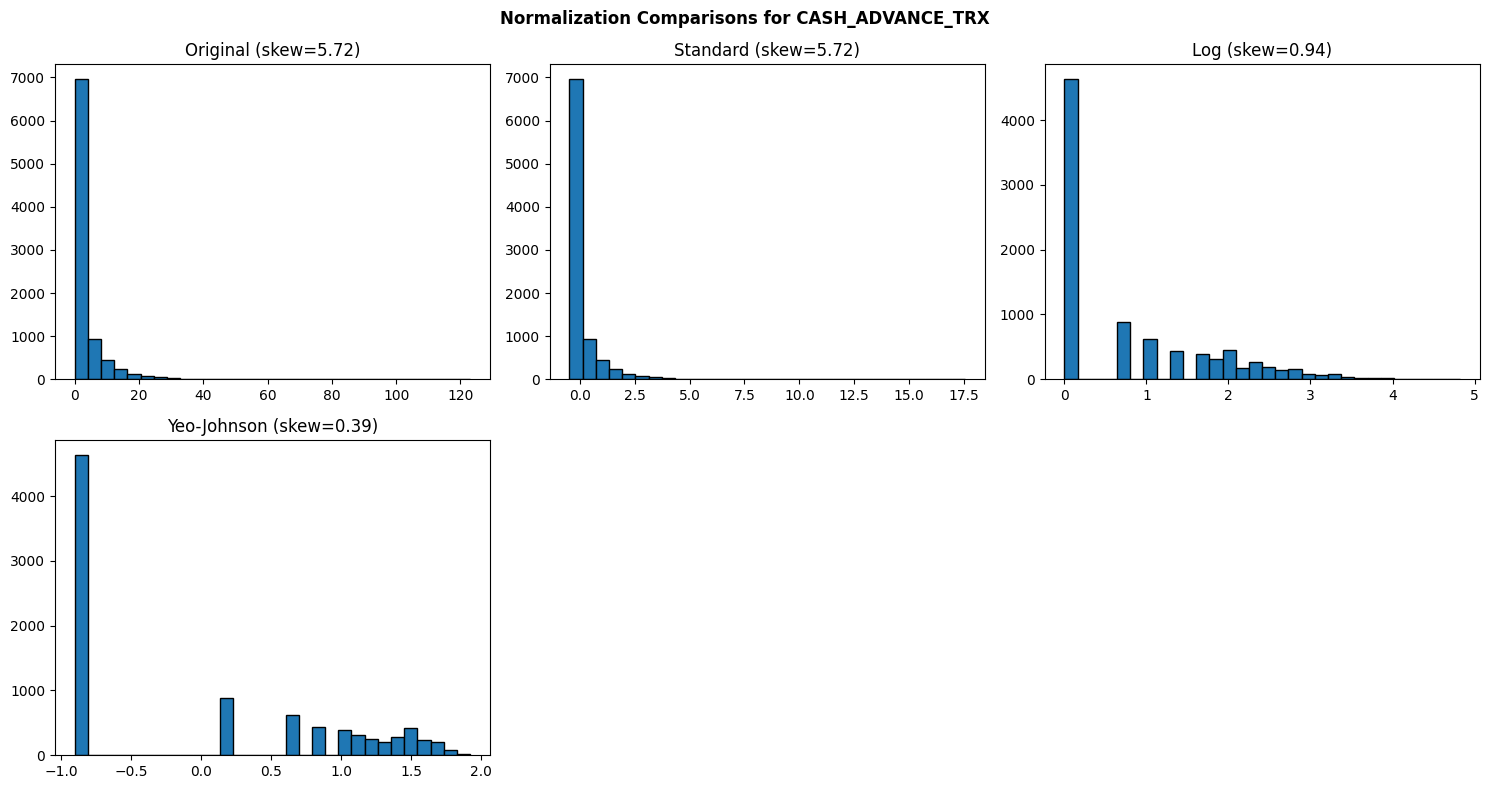

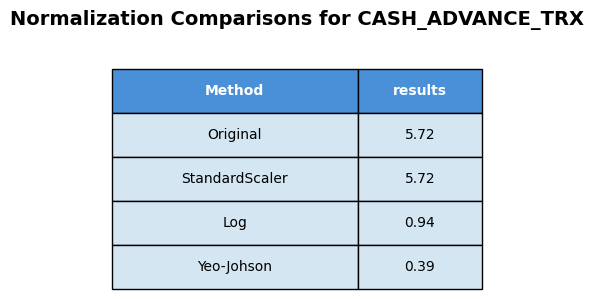

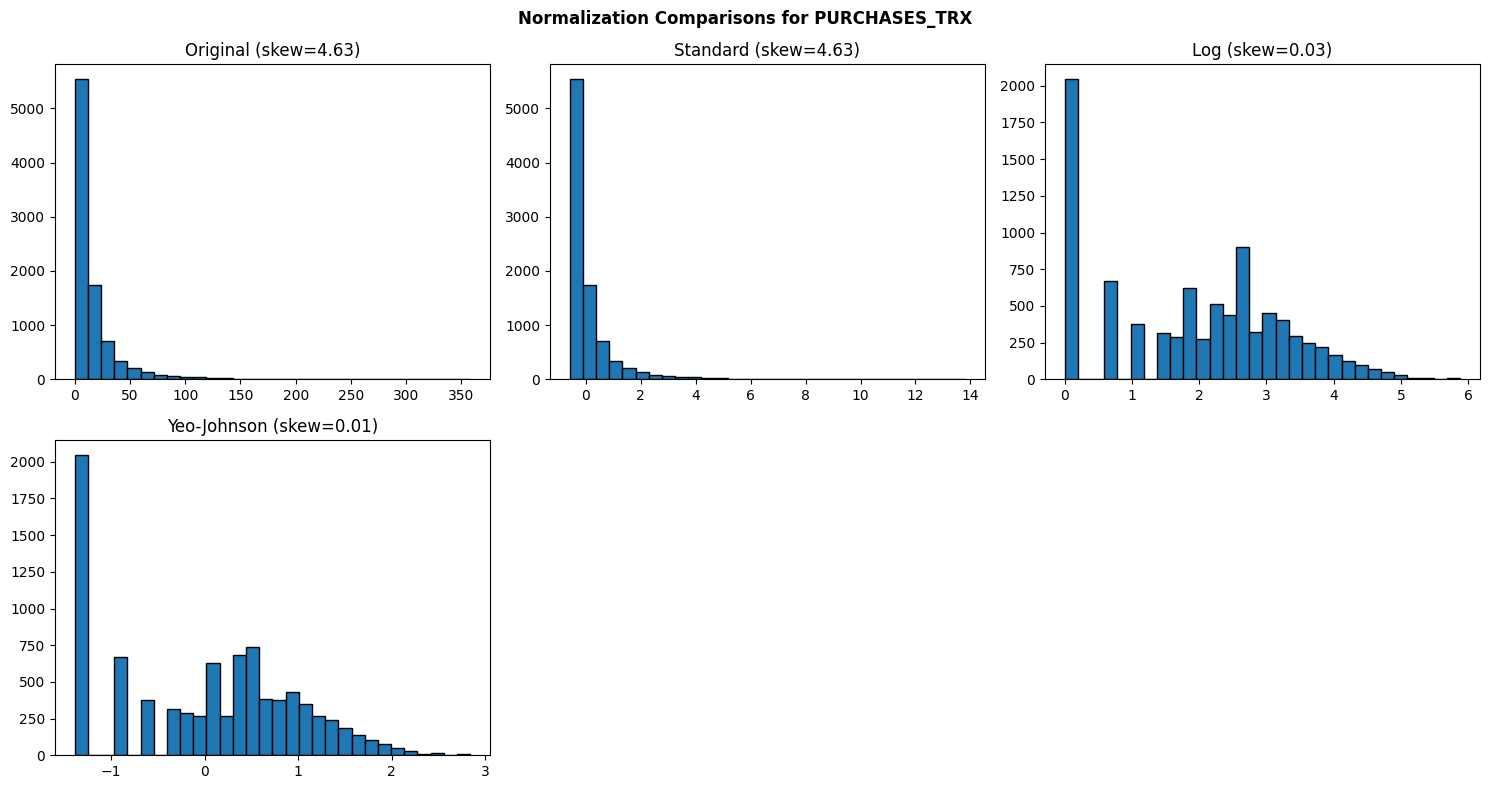

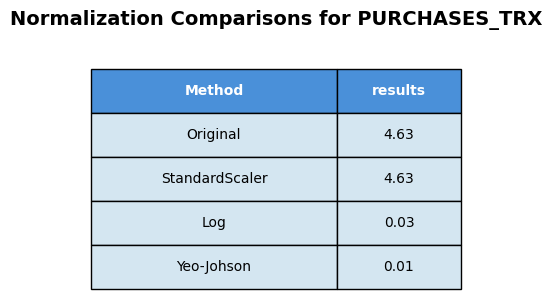

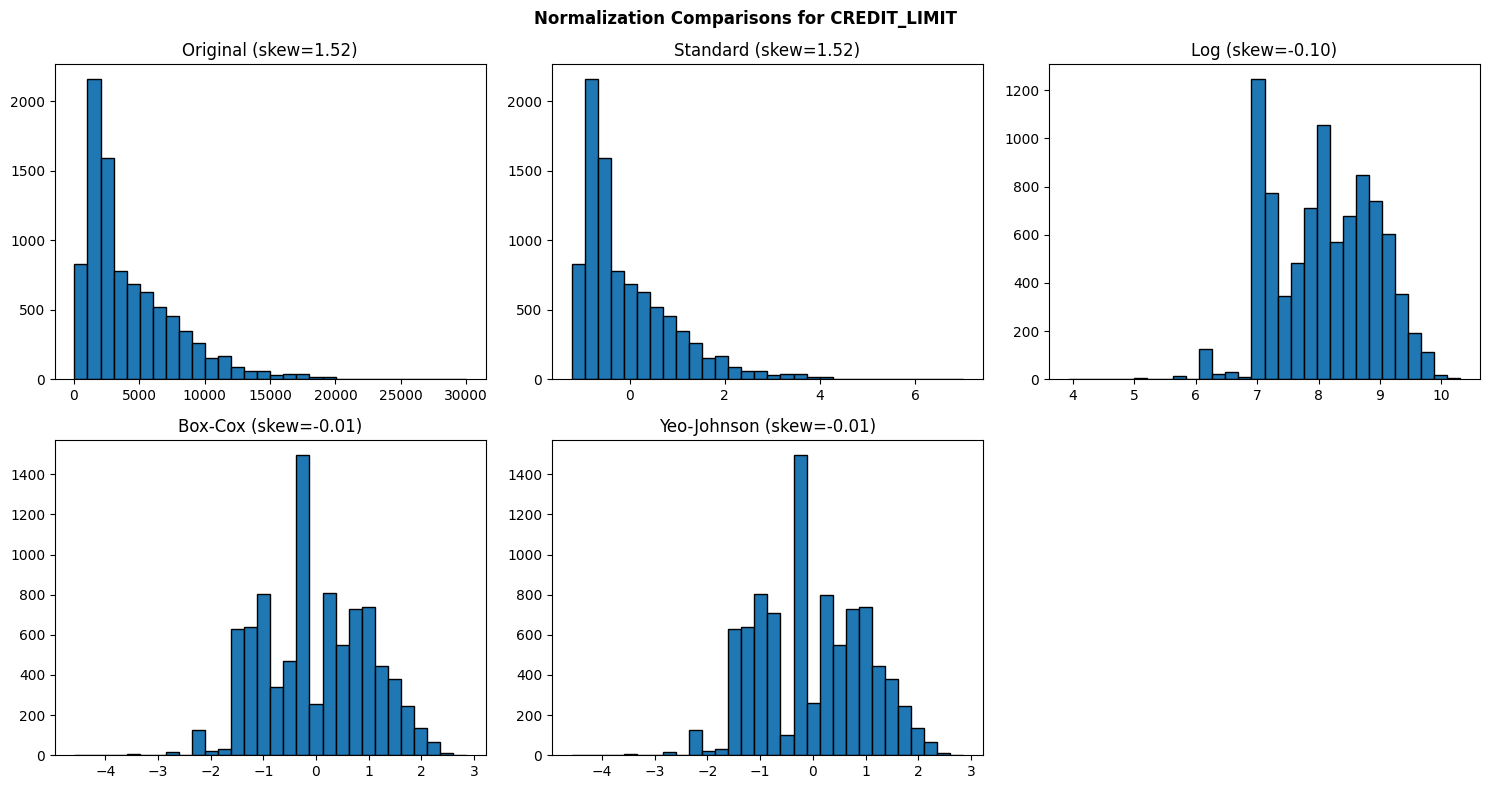

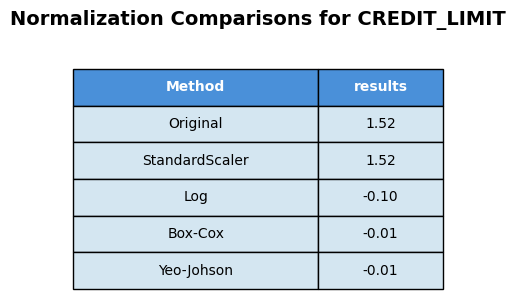

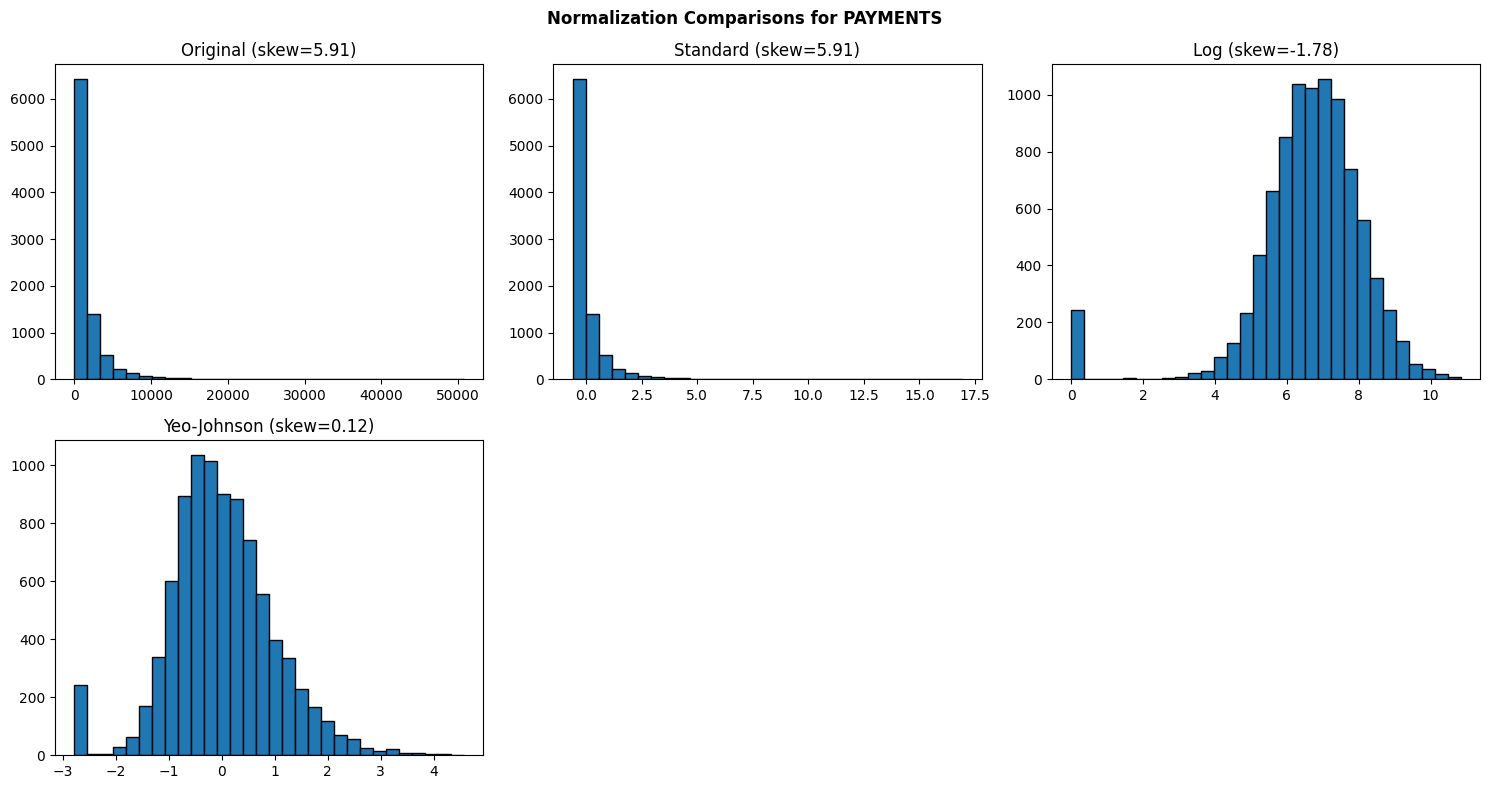

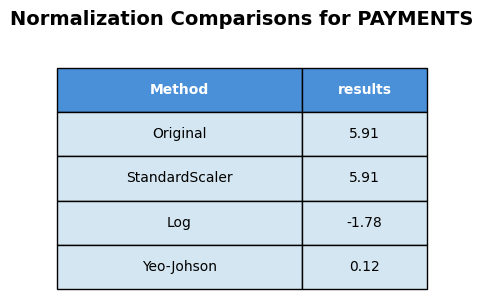

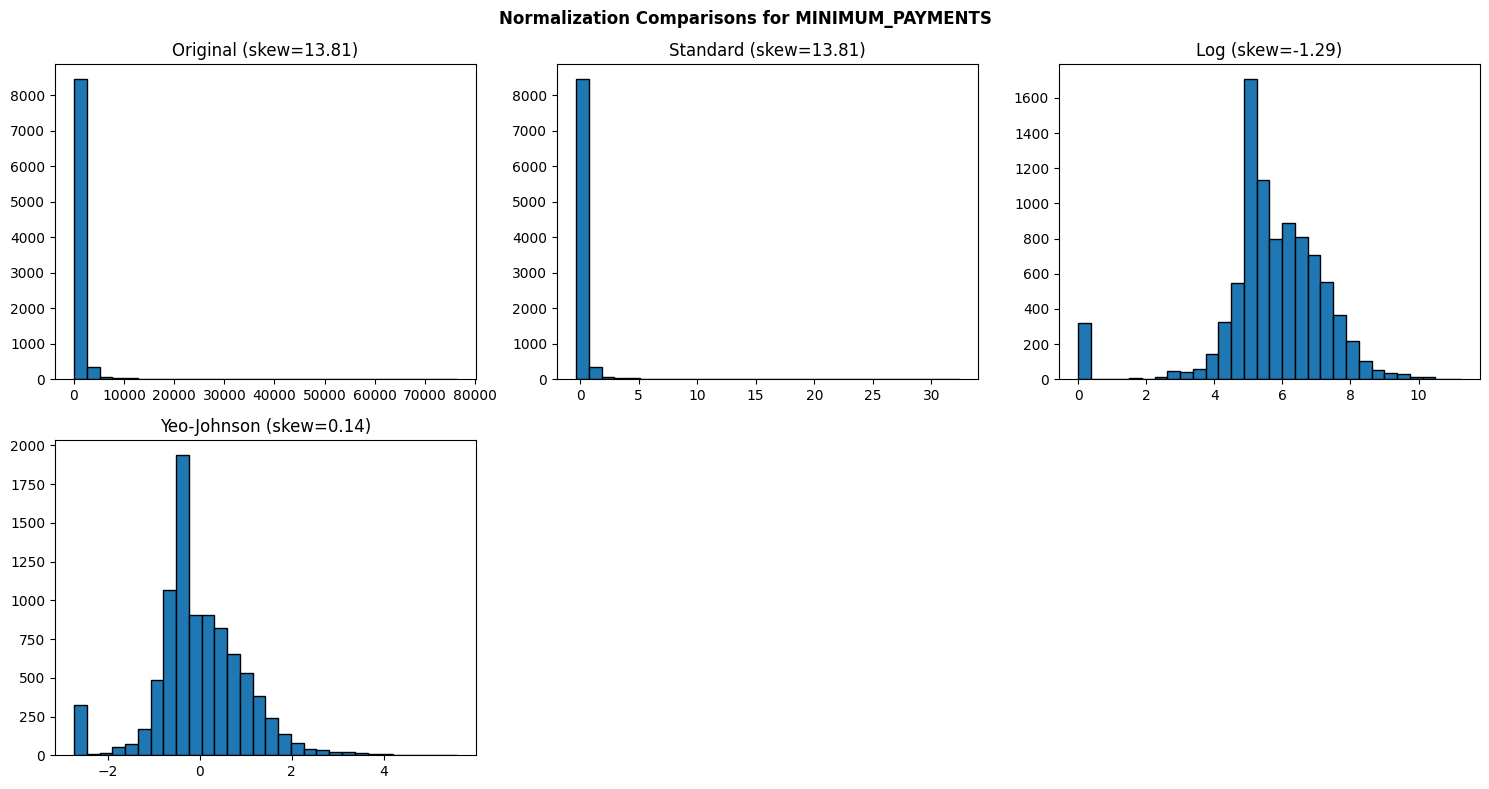

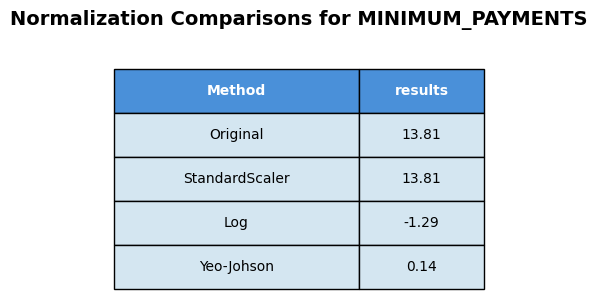

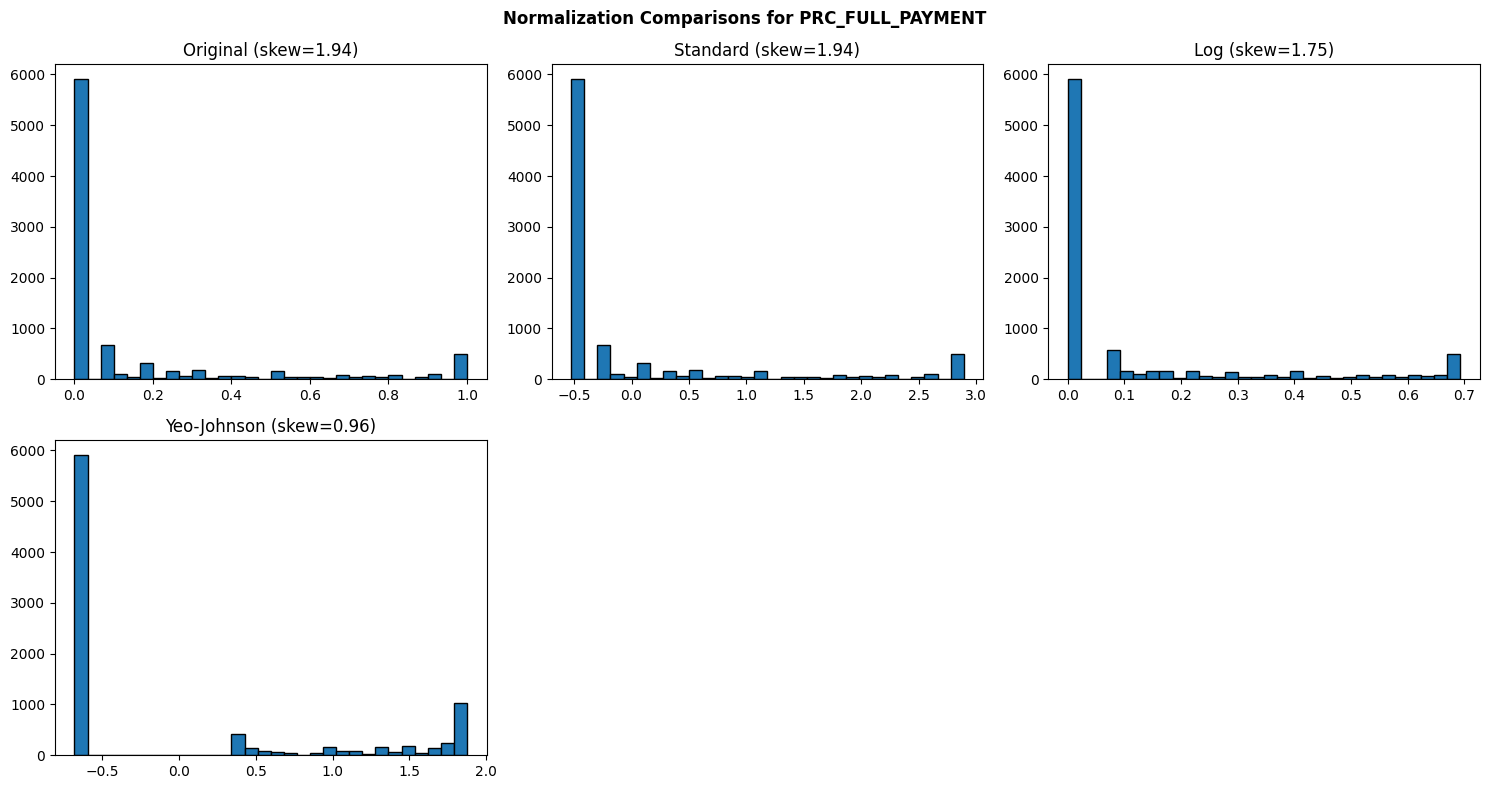

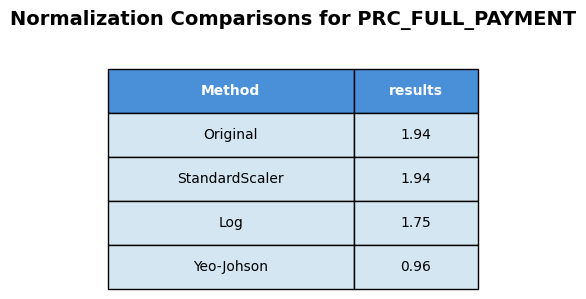

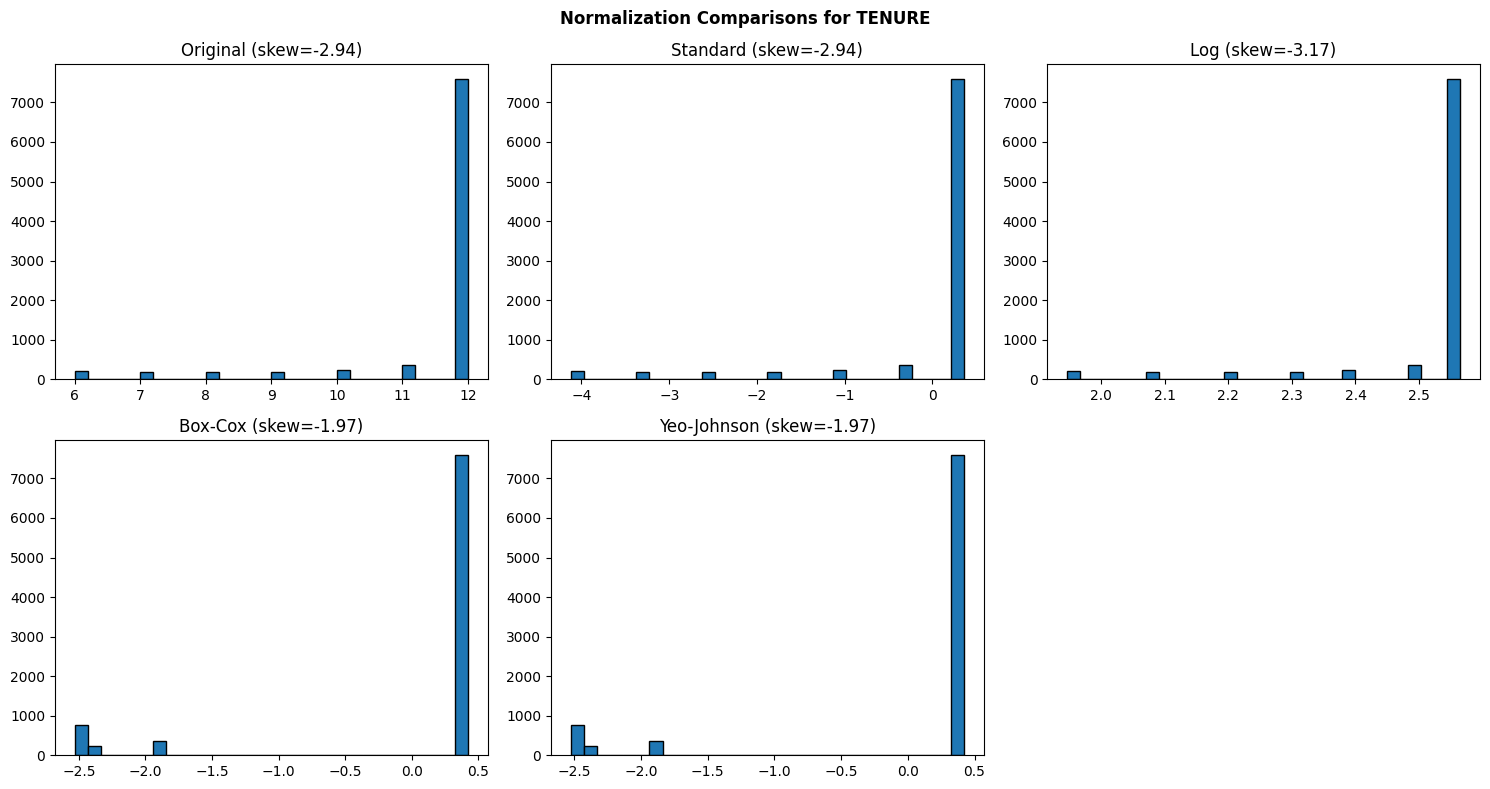

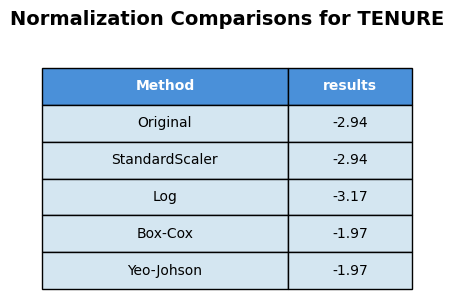

In [11]:
def CompareNormalizationMethods(df_target, feature_name):

    normalization_results = []

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()  # Now axes has 6 elements

    # Original
    axes[0].hist(df_target[feature_name], bins=30, edgecolor='black')
    axes[0].set_title(f"Original (skew={df_target[feature_name].skew():.2f})")
    normalization_results.append({'Method':'Original', 'results': f'{df_target[feature_name].skew():.2f}'})

    # Standard
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df_target[[feature_name]]).flatten()
    axes[1].hist(scaled, bins=30, edgecolor='black')
    axes[1].set_title(f"Standard (skew={pd.Series(scaled).skew():.2f})")
    normalization_results.append({'Method':'StandardScaler', 'results': f'{pd.Series(scaled).skew():.2f}'})

    # Log
    log_vals = np.log1p(df_target[feature_name])
    axes[2].hist(log_vals, bins=30, edgecolor='black')
    axes[2].set_title(f"Log (skew={log_vals.skew():.2f})")
    normalization_results.append({'Method':'Log', 'results': f'{log_vals.skew():.2f}'})

    plot_count = 3  # track how many plots used

    # Box-Cox
    if df_target[feature_name].min() > 0:
        scaler = PowerTransformer(method='box-cox')
        scaled = scaler.fit_transform(df_target[[feature_name]]).flatten()
        axes[plot_count].hist(scaled, bins=30, edgecolor='black')
        axes[plot_count].set_title(f"Box-Cox (skew={pd.Series(scaled).skew():.2f})")
        normalization_results.append({'Method':'Box-Cox', 'results': f'{pd.Series(scaled).skew():.2f}'})
        plot_count += 1

    # Yeo-Johnson
    scaler = PowerTransformer(method='yeo-johnson')
    scaled = scaler.fit_transform(df_target[[feature_name]]).flatten()
    axes[plot_count].hist(scaled, bins=30, edgecolor='black')
    axes[plot_count].set_title(f"Yeo-Johnson (skew={pd.Series(scaled).skew():.2f})")
    normalization_results.append({'Method':'Yeo-Johson', 'results': f'{pd.Series(scaled).skew():.2f}'})
    plot_count += 1

    # Hide unused plots
    for i in range(plot_count, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(f'Normalization Comparisons for {feature_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()
    print()

    df_results = pd.DataFrame(normalization_results)
    DisplayTable(df_results, f'Normalization Comparisons for {feature_name}')


#PrintDataFrameStatus(df_CreditCardAgency)

numeric_features = df_CreditCardAgency.select_dtypes(include=['number']).columns.tolist()   
for feature in numeric_features:
    CompareNormalizationMethods(df_CreditCardAgency, feature)

##### **Normalization Comparison Analysis** #####
    Yeo-Johnson is the clear choice for Normalization technique to apply. 
    It consistently scored results closest to zero(0)

##### **Apply Yeo-Johnson Transformation** #####

In [12]:
def ApplyYeoJohnsonTransformation(df_target):

    numeric_features = df_target.select_dtypes(include=['number']).columns.tolist() 
    pt_yeo_johnson = PowerTransformer(method='yeo-johnson')

    # Replace original columns
    df_target[numeric_features] = pt_yeo_johnson.fit_transform(df_target[numeric_features])
    return df_target

df_CreditCardAgency = ApplyYeoJohnsonTransformation(df_CreditCardAgency)


##### **Examine Yeo-Johnson Transformed Results via Histograms** #####

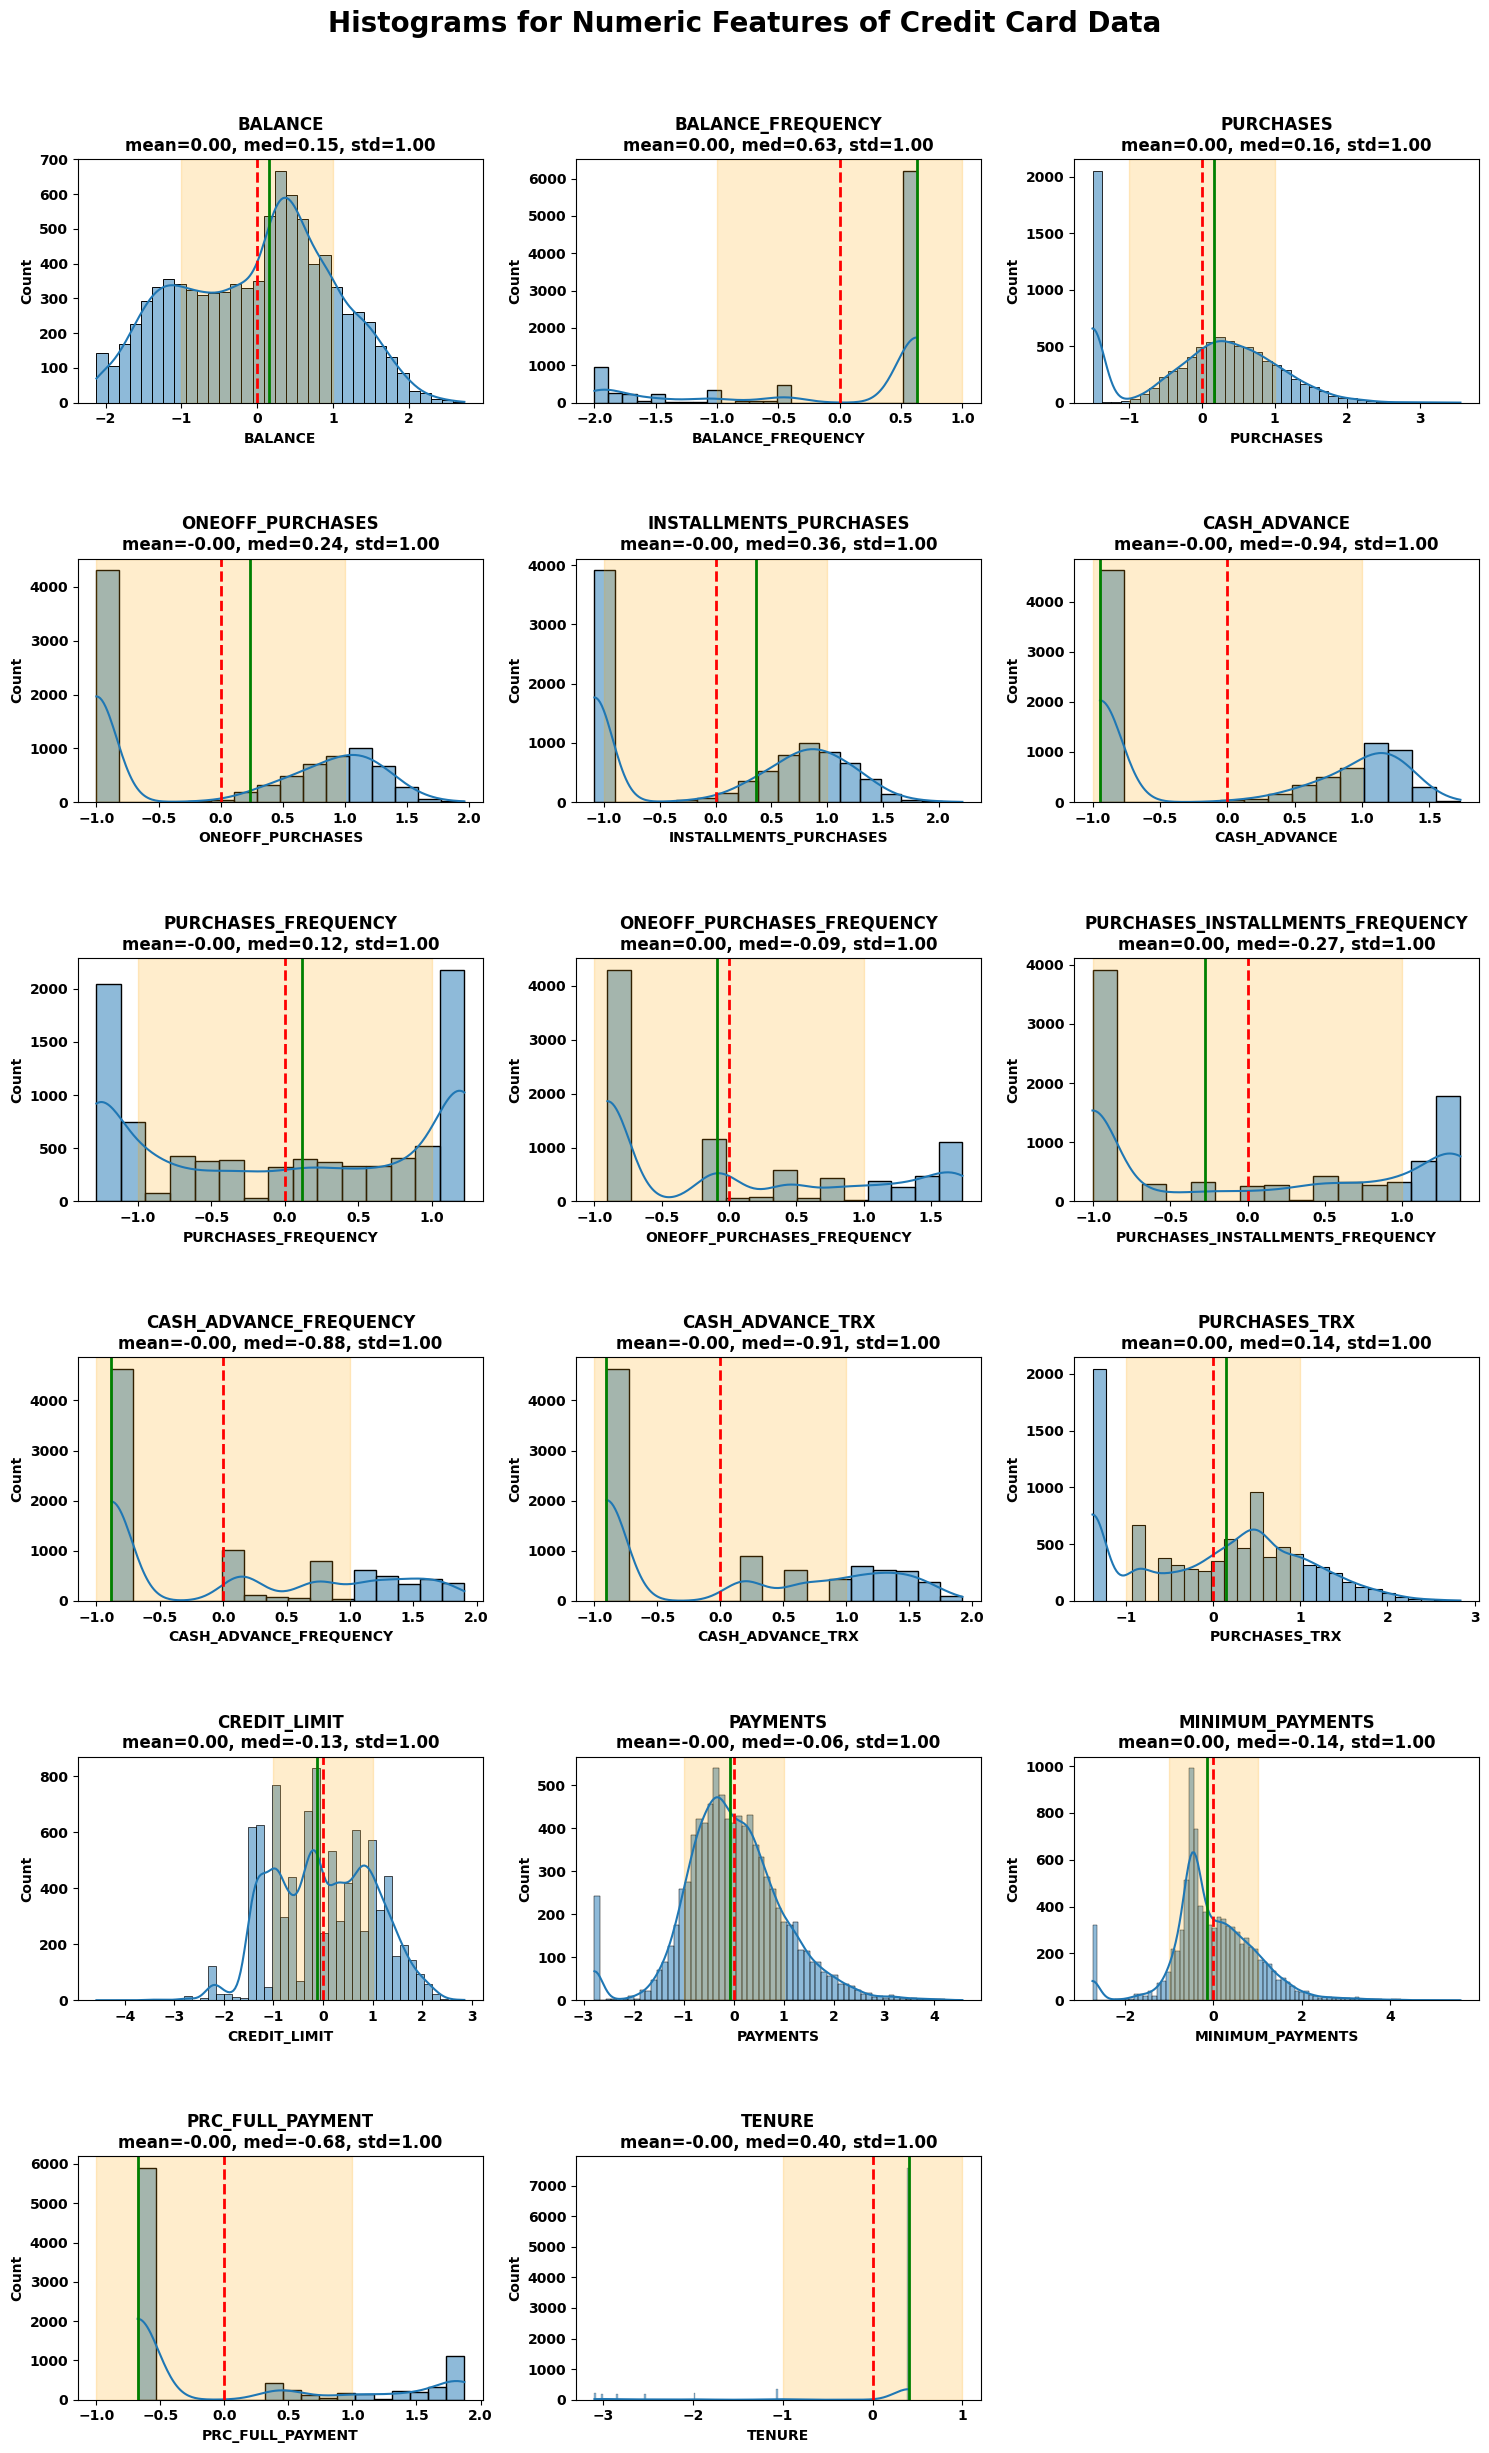

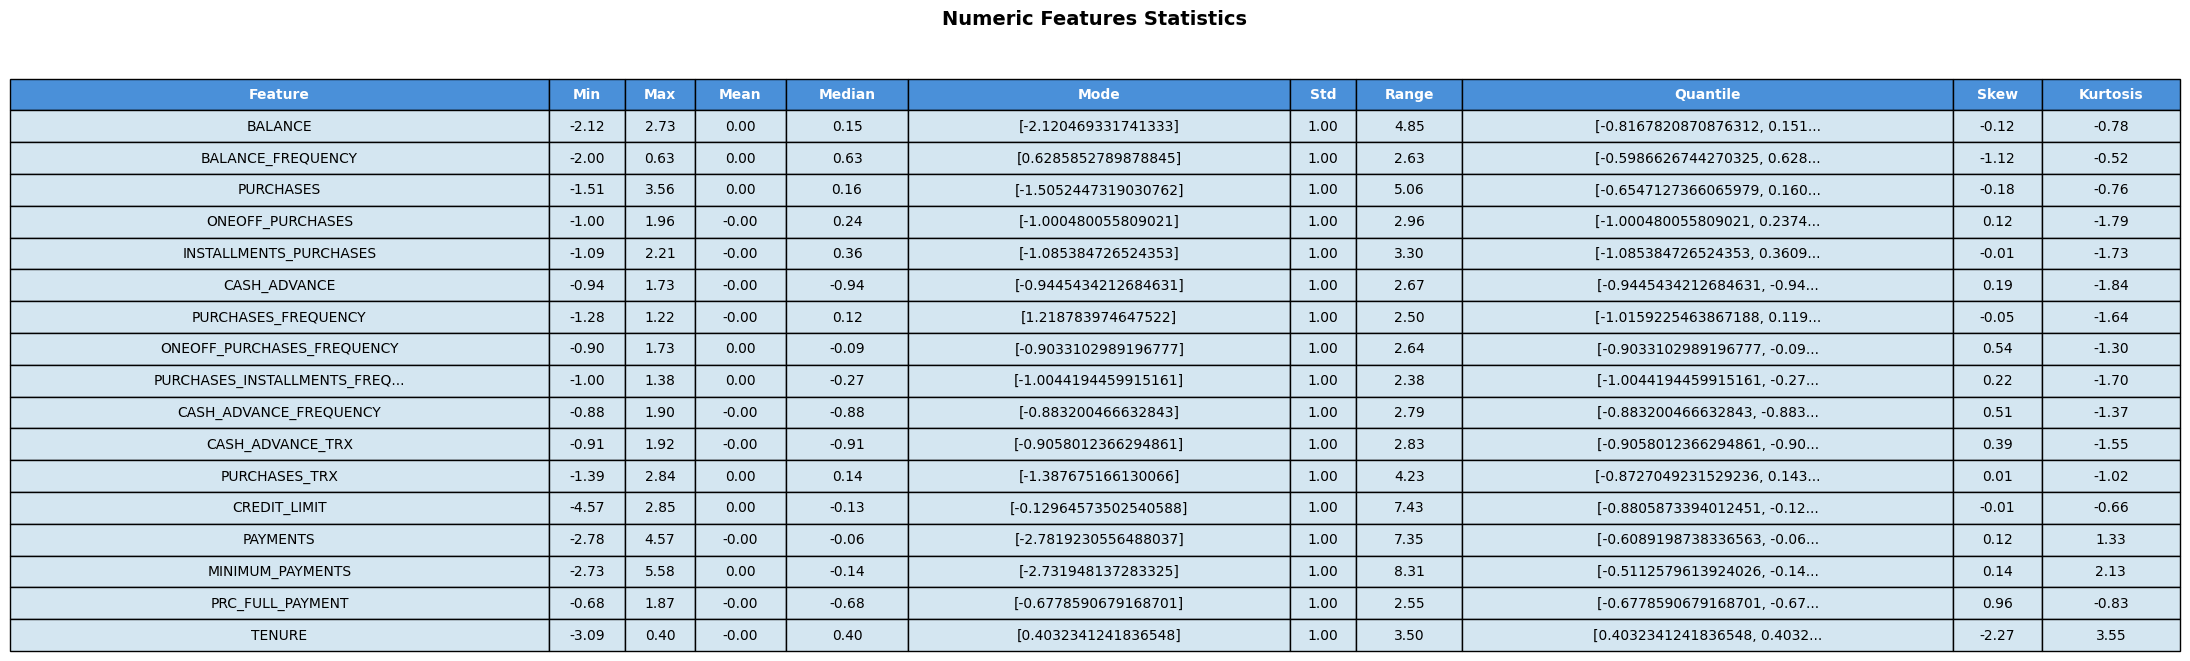

In [13]:
# Uncomment this if you want to see the transformed histograms
DisplayNumericFeatureHistograms(df_CreditCardAgency) 
print()
print()

##### **Examine Yeo-Johnson Transformed Results via BoxPlots** #####

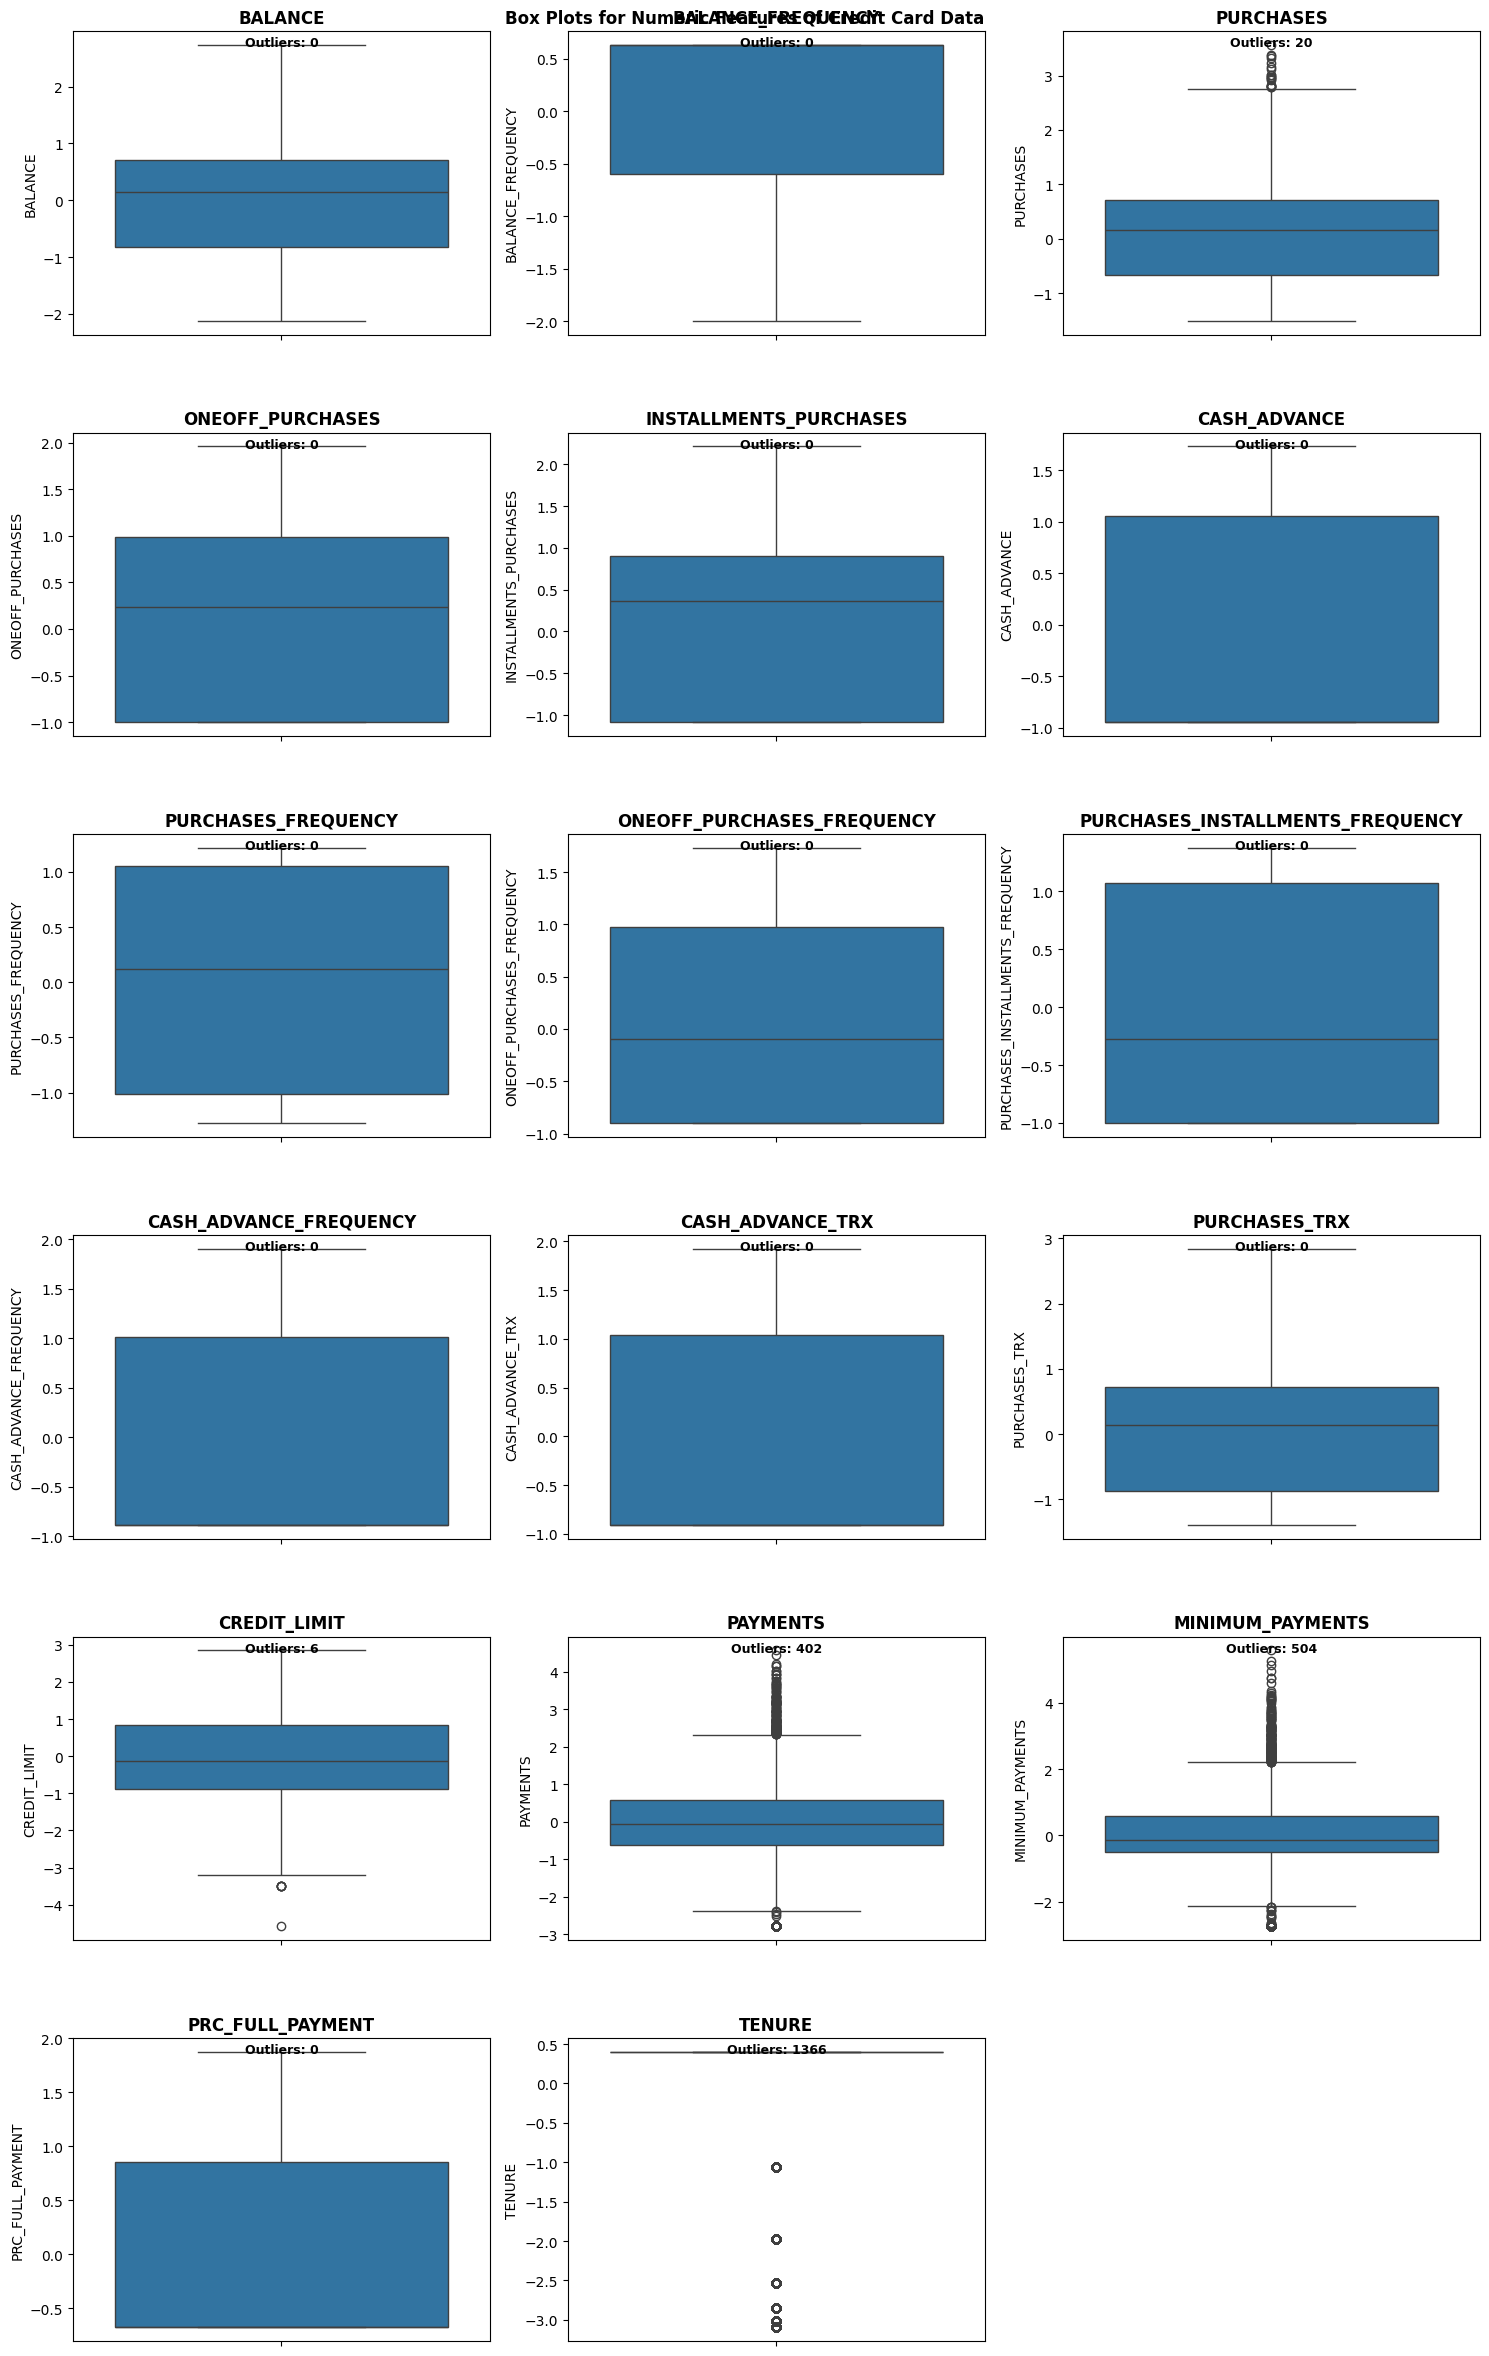

In [14]:
# Uncomment this if you want to see the transformed boxplots
PlotBoxPlotsToViewDistributions(df_CreditCardAgency) 
print()
print()

##### **Handle Outliers** #####

Updated Features with Capped Outliers


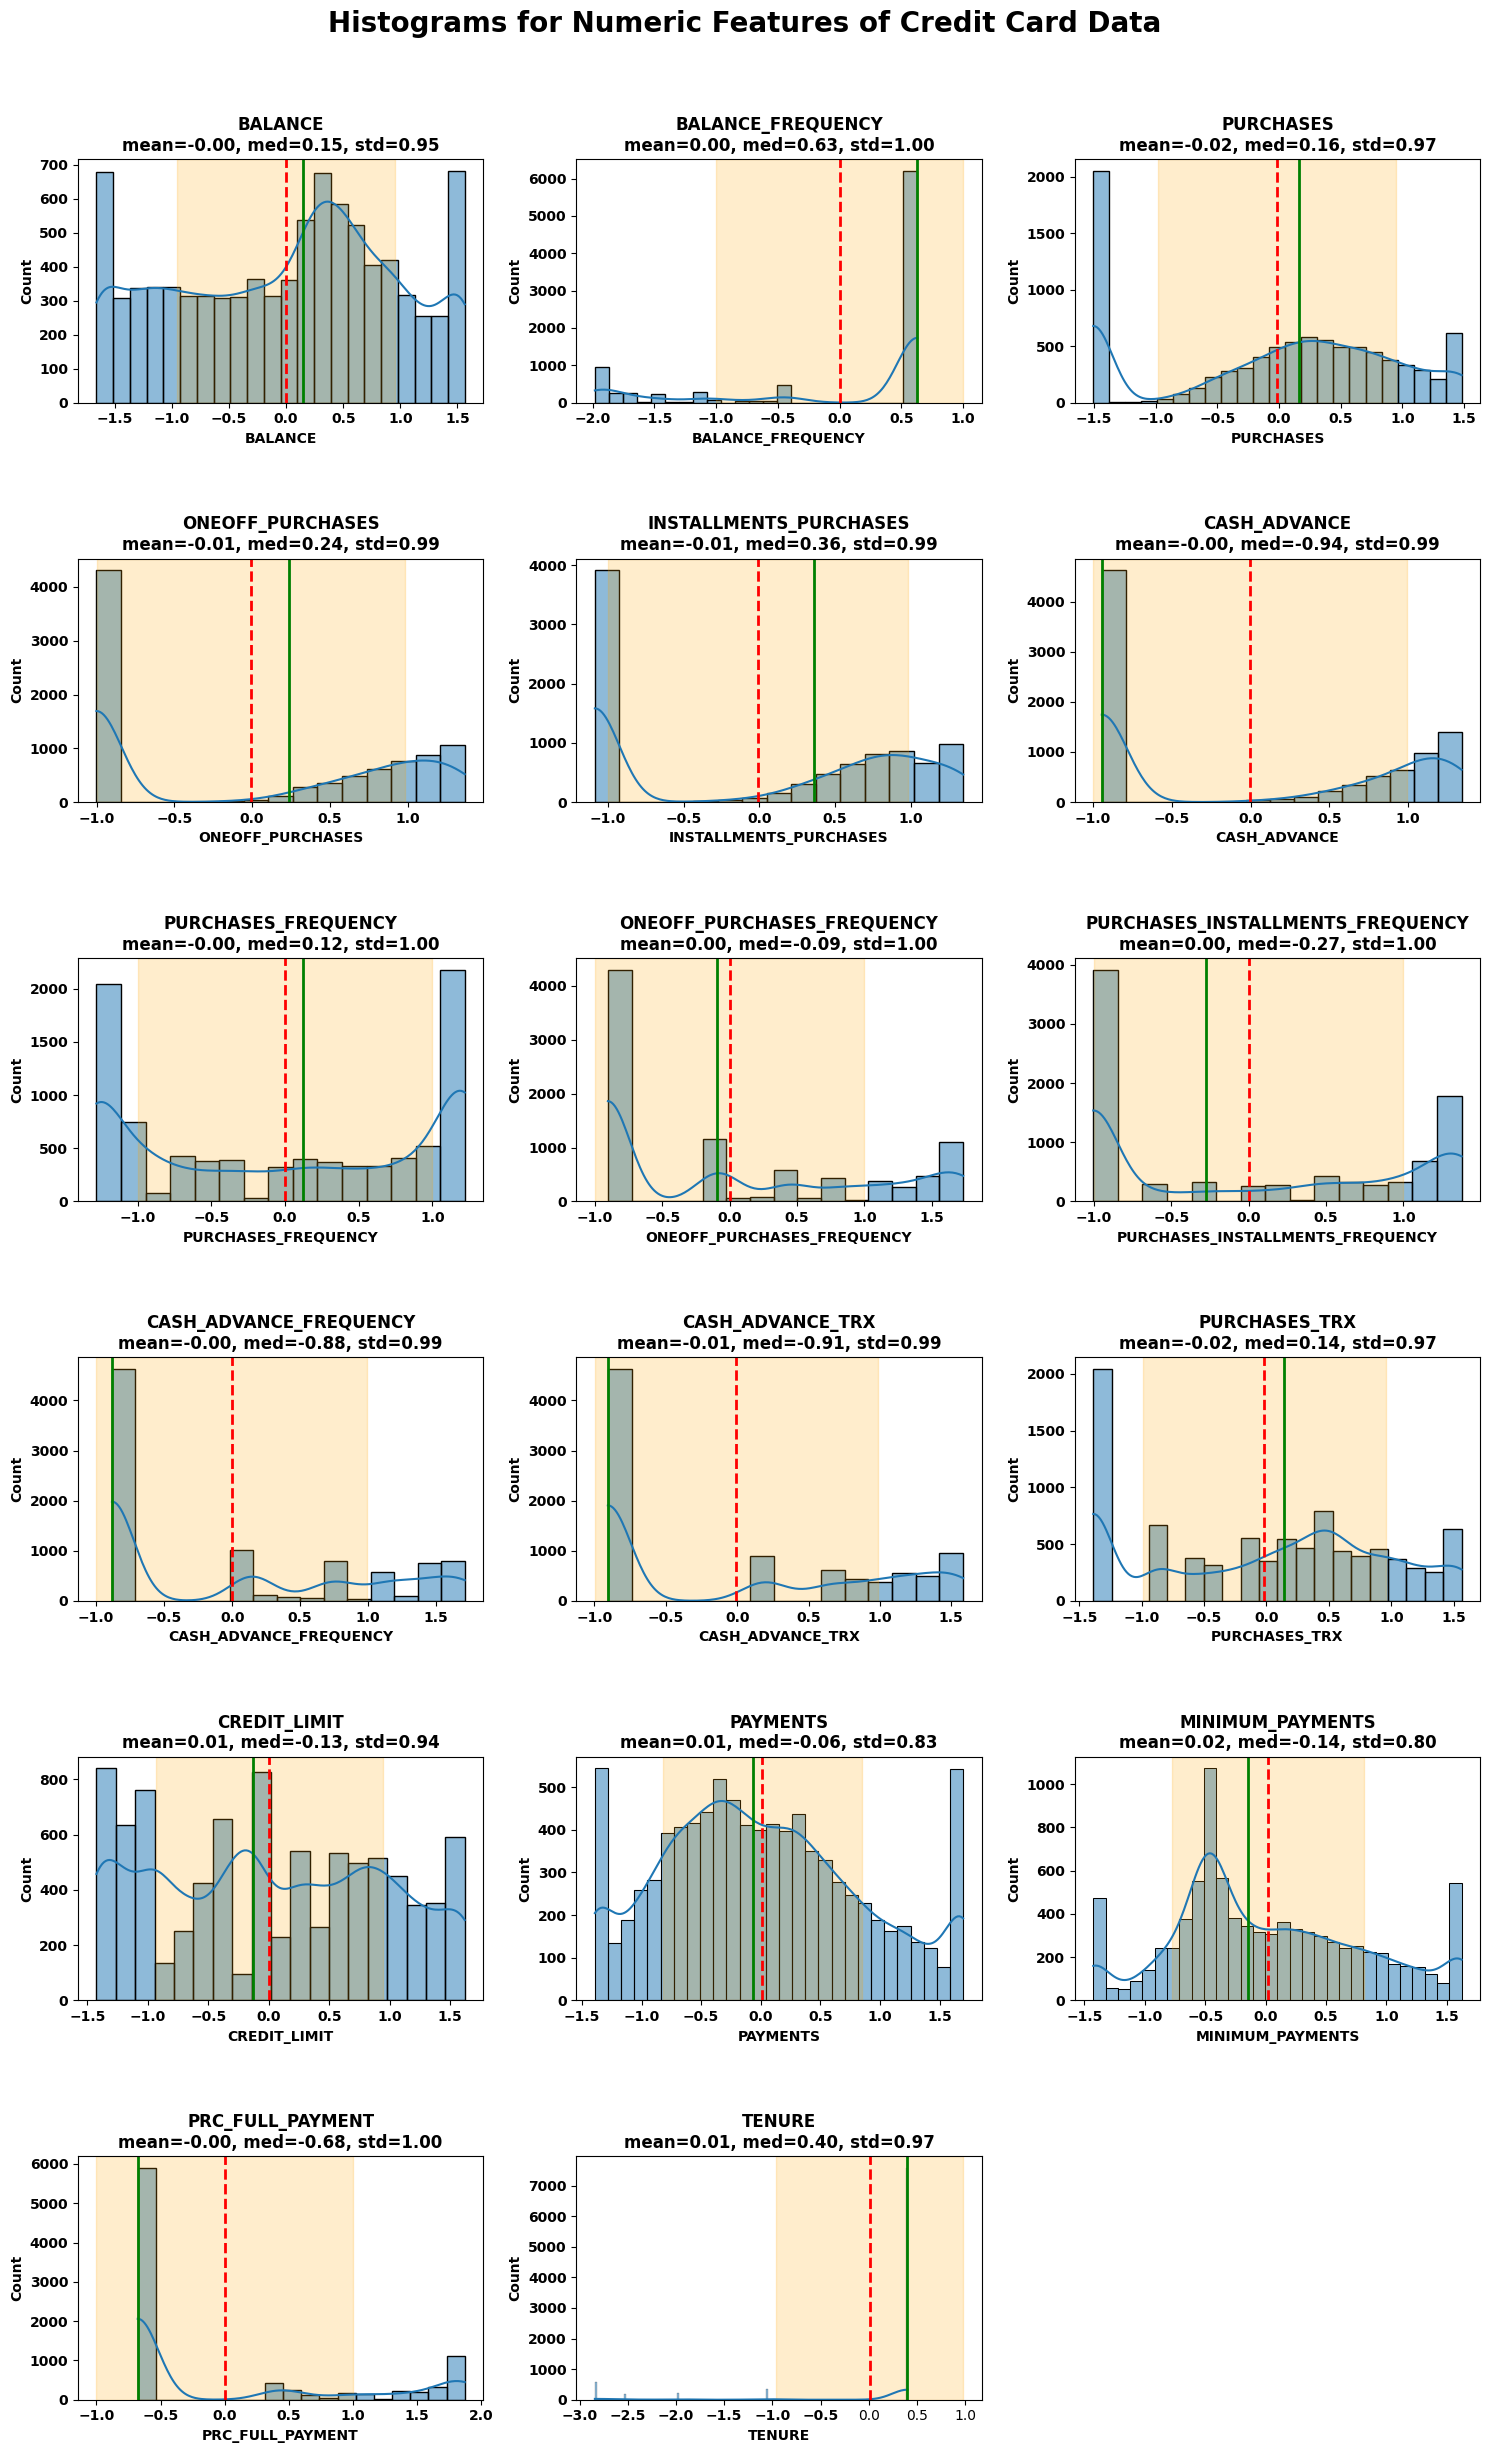

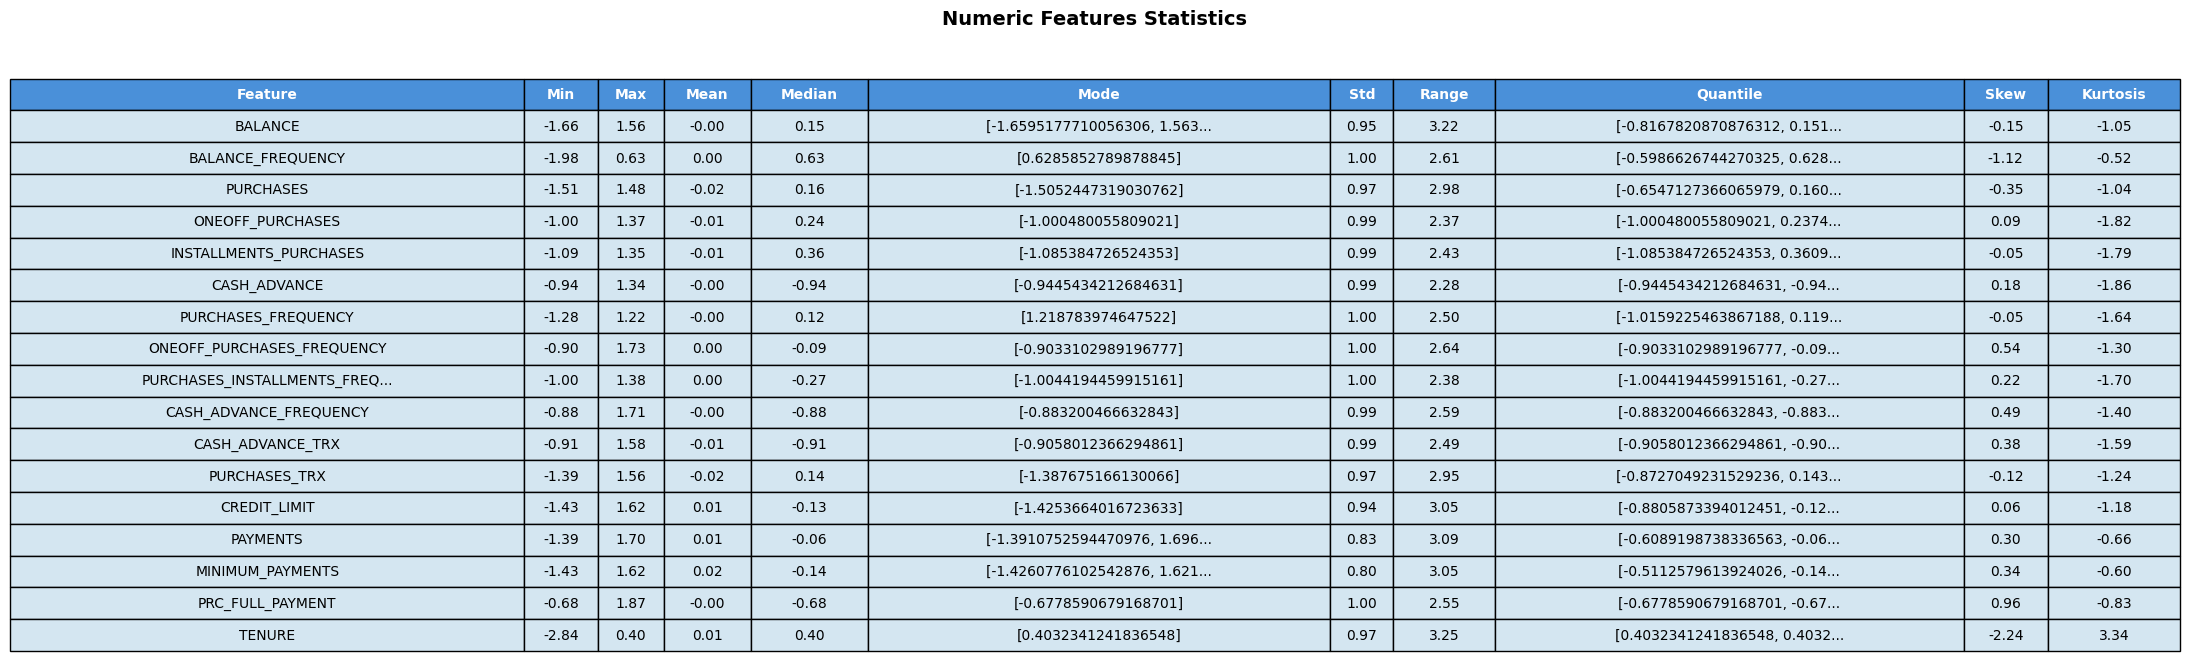

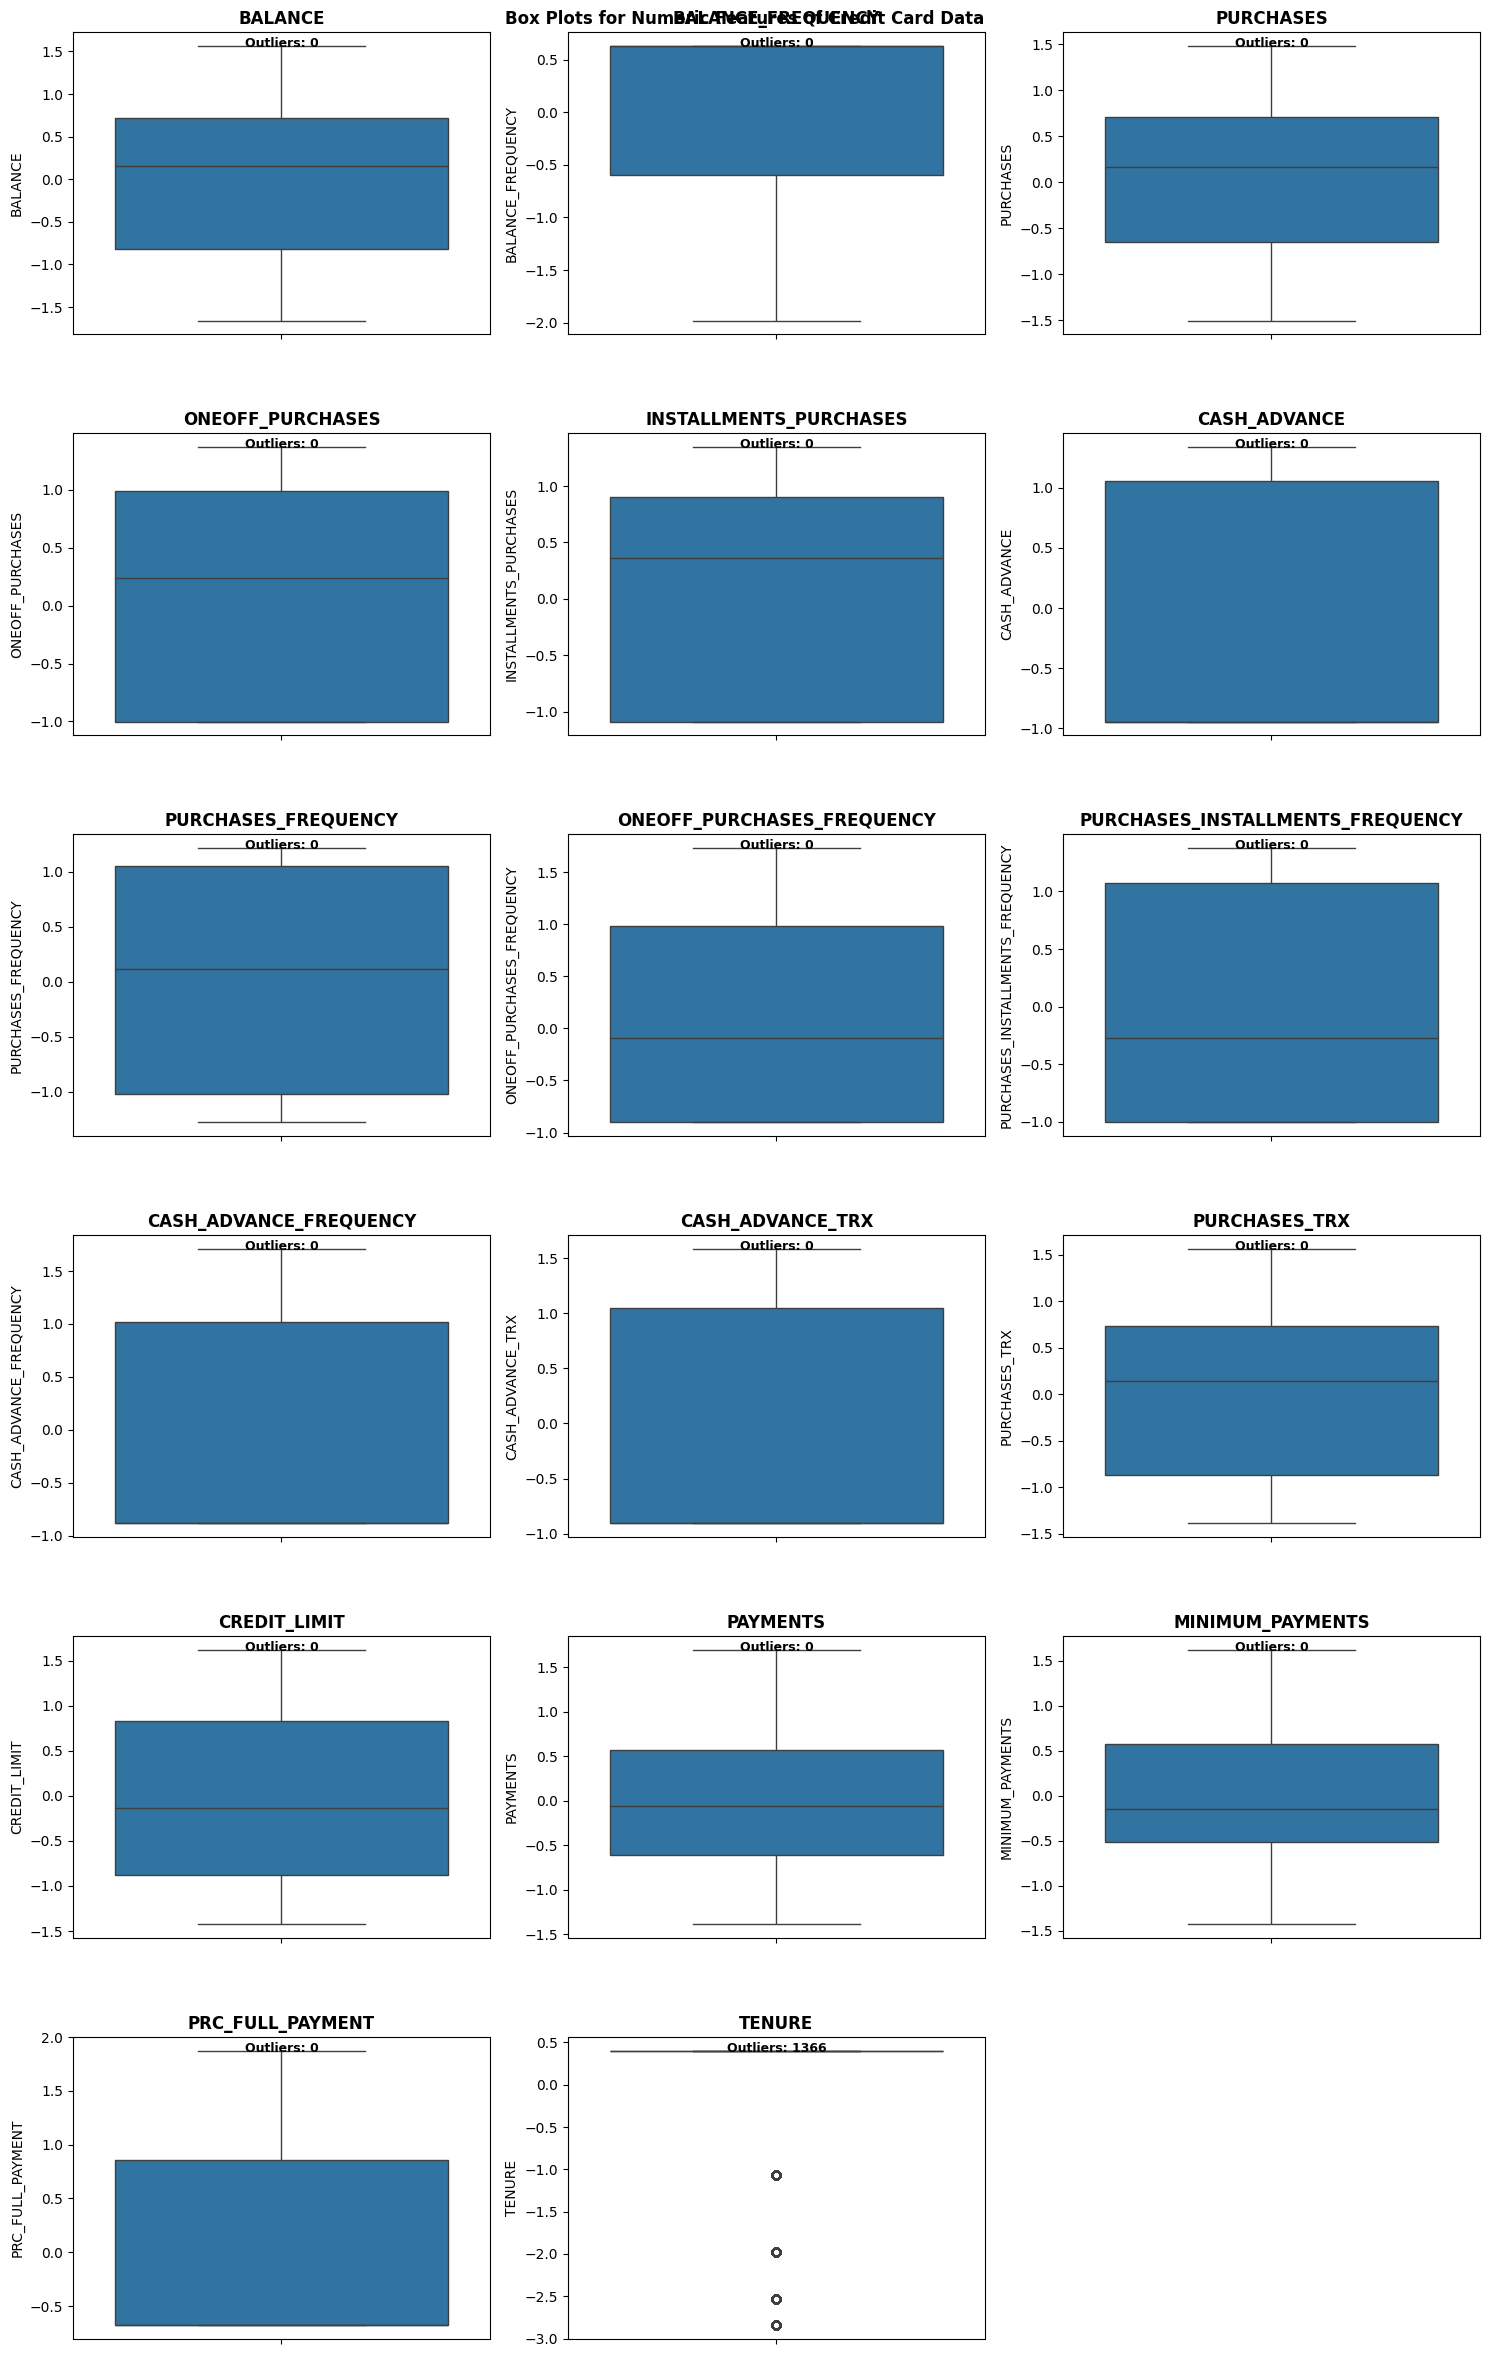

In [15]:
# Winsorization
# Cap at 5th and 95th percentiles
def CapOutliers(df_target, column, lower_pct=0.05, upper_pct=0.95):
    lower = df_target[column].quantile(lower_pct)
    upper = df_target[column].quantile(upper_pct)
    df_target[column] = df_target[column].clip(lower, upper)
    return df_target

def CapAllOutliers(df_target):

    numeric_features = df_target.select_dtypes(include=['number']).columns.tolist() 

    for feature in numeric_features:
        df_target = CapOutliers(df_target, feature)

    return df_target

df_CreditCardAgency = CapAllOutliers(df_CreditCardAgency)

# Uncomment if you want to see updated feature columns with capped outliers
print('Updated Features with Capped Outliers')
DisplayNumericFeatureHistograms(df_CreditCardAgency) 
print()
print()
PlotBoxPlotsToViewDistributions(df_CreditCardAgency)
print()
print()

##### **Column Dropper Utility** #####

In [16]:
def PerformColumnDropping(df_target, columnsToBeDropped=None):

    if columnsToBeDropped is not None:
        df_target.drop(columns=['CUST_ID'], axis=1, inplace=True)

    return df_target

## **2. Clustering** ##

Optimal k: 5


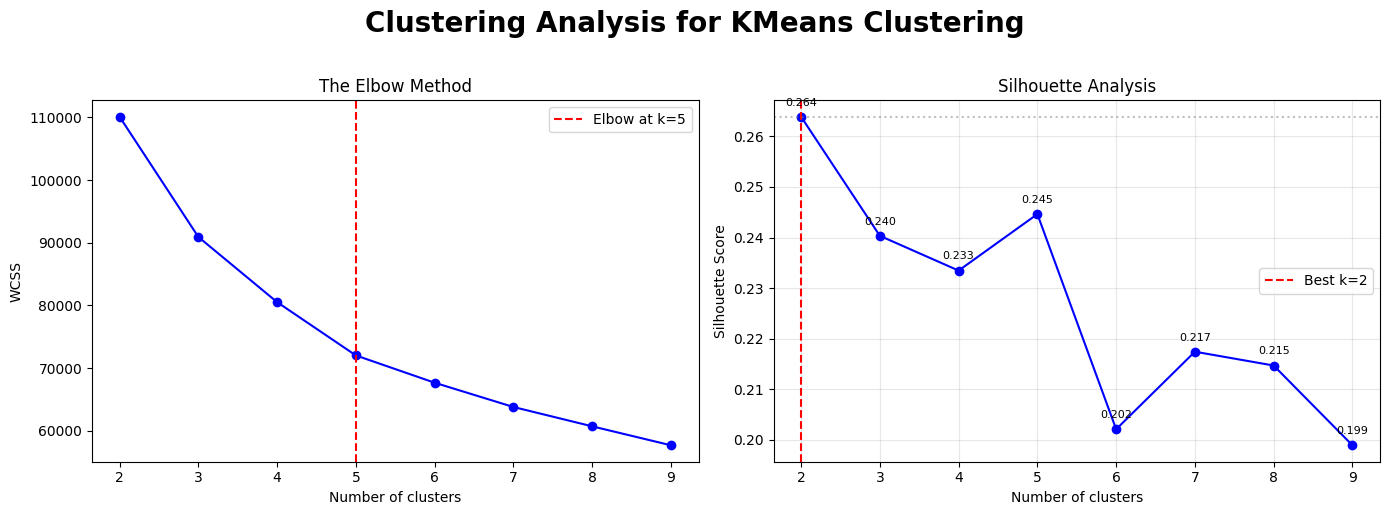

In [17]:
def PlotClusterResults(k_range, wcss, sil_scores, cluster_type):

    #
    # Plot the Elbow Method
    #

    # I need a 1X2 plot to display 2 plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes = axes.flatten()

    axes[0].plot(k_range, wcss, 'b-', marker='o')

    kl = KneeLocator(k_range, wcss, curve='convex', direction='decreasing')
    print(f"Optimal k: {kl.elbow}")
    axes[0].axvline(x=kl.elbow, color='r', linestyle='--', label=f'Elbow at k={kl.elbow}')

    axes[0].set_title('The Elbow Method')
    axes[0].set_xlabel('Number of clusters')
    axes[0].set_ylabel('WCSS')
    axes[0].legend()
    
    #
    # Plot Silhouette Analysis
    #
    best_k = k_range[np.argmax(sil_scores)]
    best_score = max(sil_scores)

    axes[1].plot(k_range, sil_scores, 'b-', marker='o')
    axes[1].axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')
    axes[1].axhline(y=best_score, color='gray', linestyle=':', alpha=0.5)

    # Annotate each point
    for k, score in zip(k_range, sil_scores):
        axes[1].annotate(f'{score:.3f}', (k, score), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

    axes[1].set_xlabel('Number of clusters')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Analysis')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Clustering Analysis for {cluster_type}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout()
    plt.show()
    print()
    print()


kmeans_wcss = []
kmeans_sil_scores = []
k_range = range(2, 10) 

# Scale data before applying kmeans
scaler = StandardScaler()

df_for_scaling = PerformColumnDropping(df_CreditCardAgency, ['CUST_ID'])
#df_CreditCardAgency_scaled = scaler.fit_transform(df_for_scaling)

# Create a dataframe from scale (which returns npdarray)
df_CreditCardAgency_scaled = pd.DataFrame(
                                        scaler.fit_transform(df_for_scaling),
                                        columns=df_for_scaling.columns,
                                        index=df_for_scaling.index
                                    )

#
# KMeans Clustering
# 

# Iterate through K-Means cluster with number of clusters 2-10
for i in k_range:
    model = KMeans(n_clusters = i, n_init=10, init = 'k-means++', random_state = 315)
    model.fit(df_CreditCardAgency_scaled)
    kmeans_wcss.append(model.inertia_)

    labels = model.predict(df_CreditCardAgency_scaled)
    kmeans_sil_scores.append(silhouette_score(df_CreditCardAgency_scaled, labels))

PlotClusterResults(k_range, kmeans_wcss, kmeans_sil_scores, 'KMeans Clustering')


##### **KMeans Results and Analysis** #####
    Elbow method indicates 4 clusters is optimal
    Silhouette scores indicate that 3 clusters is optimal

Optimal k: 5


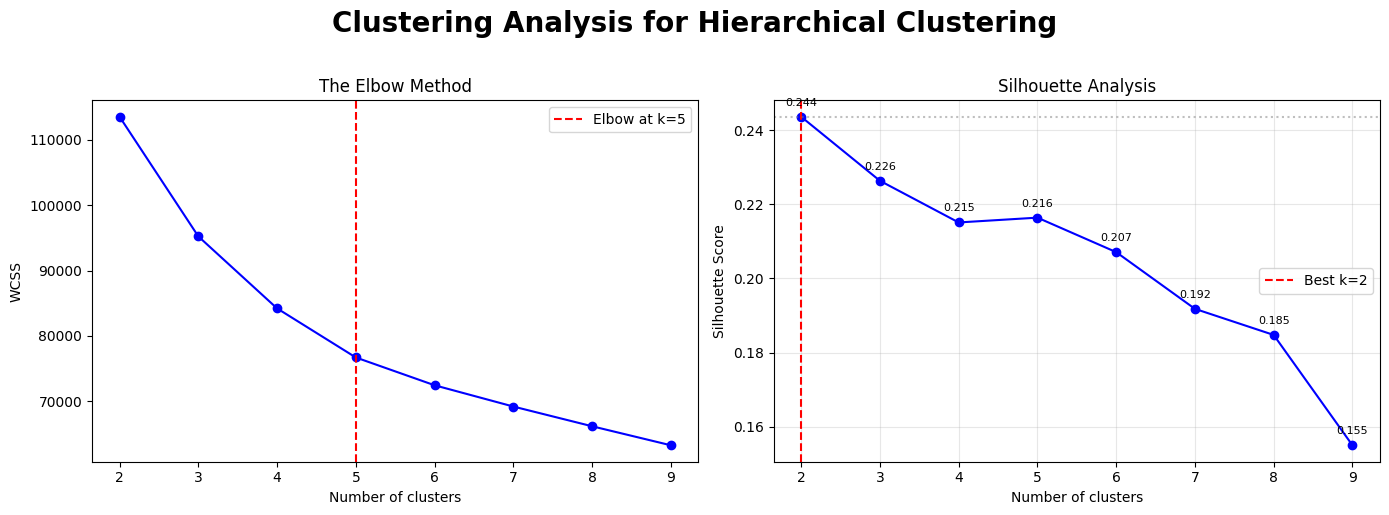

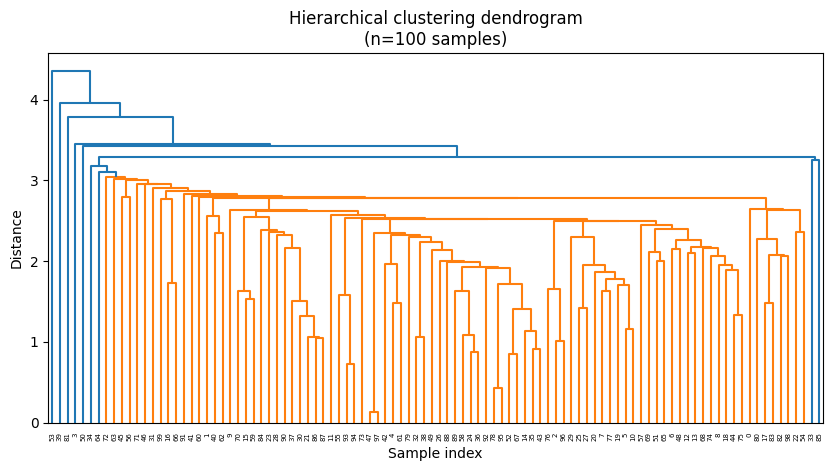

In [18]:
#
# Hierarchical (Agglomerative) Clustering
#
agglo_sil_scores = []
agglo_wcss = []

# Iterate through K-Means cluster with number of clusters 2-10
for i in k_range:
    # Fit hierarchical clustering
    model = AgglomerativeClustering(n_clusters=i)
    labels = model.fit_predict(df_CreditCardAgency_scaled)

    # Calculate WCSS manually
    wcss = 0
    for cluster in range(i):
        cluster_points = df_CreditCardAgency_scaled[labels == cluster]
        centroid = cluster_points.mean(axis=0)
        wcss += ((cluster_points - centroid) ** 2).sum().sum()

    agglo_wcss.append(wcss)
    agglo_sil_scores.append(silhouette_score(df_CreditCardAgency_scaled, labels))

PlotClusterResults(k_range, agglo_wcss, agglo_sil_scores, 'Hierarchical Clustering')

# Create dendrogram
linkage_matrix = linkage(df_CreditCardAgency_scaled.iloc[:100])

plt.figure(figsize=(10, 4.8))
dendrogram(linkage_matrix)
plt.title('Hierarchical clustering dendrogram\n(n=100 samples)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()



##### **Hierarchical Results and Analysis** #####
   Elbow method indicates 5 clusters is optimal
   Silhouette scores indicate that 2 clusters is optimal

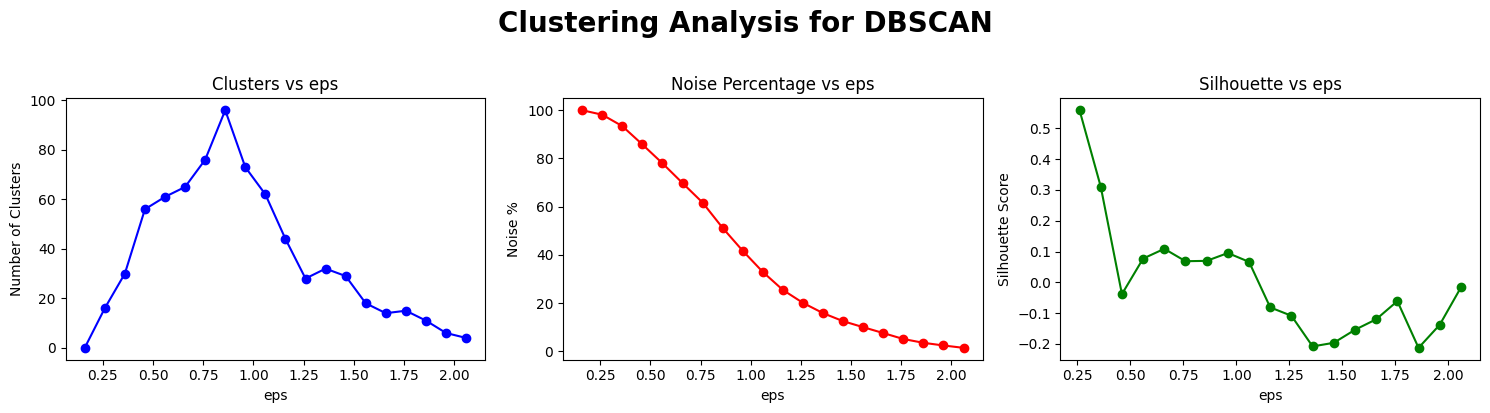

In [19]:
#
# DBSCAN Clustering
#

# Parameter ranges to test
eps_range = np.arange(0.16, 2.1, 0.1)  # Adjust based on your data
min_samples = 5  # Can also loop over this

dbscan_results = []

for eps in eps_range:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(df_CreditCardAgency_scaled)
    
    # Count clusters (excluding noise labeled as -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Silhouette score (only if more than 1 cluster and not all noise)
    if n_clusters > 1 and n_noise < len(labels):
        # Exclude noise points for silhouette
        mask = labels != -1
        sil_score = silhouette_score(df_CreditCardAgency_scaled[mask], labels[mask])
    else:
        sil_score = -1  # Invalid
    
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': n_noise / len(labels) * 100,
        'silhouette': sil_score
    })

df_dbscan_results = pd.DataFrame(dbscan_results)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Number of clusters
axes[0].plot(df_dbscan_results['eps'], df_dbscan_results['n_clusters'], 'b-', marker='o')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('Number of Clusters')
axes[0].set_title('Clusters vs eps')

# Plot 2: Noise percentage
axes[1].plot(df_dbscan_results['eps'], df_dbscan_results['noise_pct'], 'r-', marker='o')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Noise %')
axes[1].set_title('Noise Percentage vs eps')

# Plot 3: Silhouette score
valid = df_dbscan_results[df_dbscan_results['silhouette'] > -1]
axes[2].plot(valid['eps'], valid['silhouette'], 'g-', marker='o')
axes[2].set_xlabel('eps')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette vs eps')

plt.suptitle(f'Clustering Analysis for DBSCAN', y=1.02, fontsize=20, fontweight='bold')
plt.subplots_adjust(top=0.92)  

plt.tight_layout()
plt.show()    



##### **DBSCAN Results and Analysis** #####
    Lower noise around eps of 2.0 - noise decreases as eps increases
    Silhouette scores indicate that eps of .24 and/or around 2.0 are optimal (highest Silhouette scores)
    Eps of .25 - too many clusters - roughly 20
    Eps of around 2.0 - 2 - 4 clusters?

##### **Final Analysis??** #####
    DBScan - difficult to interpret results accurately
    Hierarchical - Silhouette (2 nodes) and Elbow Method (5 nodes) have a wide spread; don't converge on aggreement
    KMeans - Silhouette (3 nodes) and Elbow Method (4 nodes) closer in aggreement

    Use KMeans because Silhouette and Elbow Method are closer in agreement and results are simpler/easier to interpret.
    KMeans (Best Silhouette - .25) vs Hierarchical (Best Silhouette - .188) - KMeans highest score - best


## **3. Visualize Clusters via Dimensionality Reduction** ##

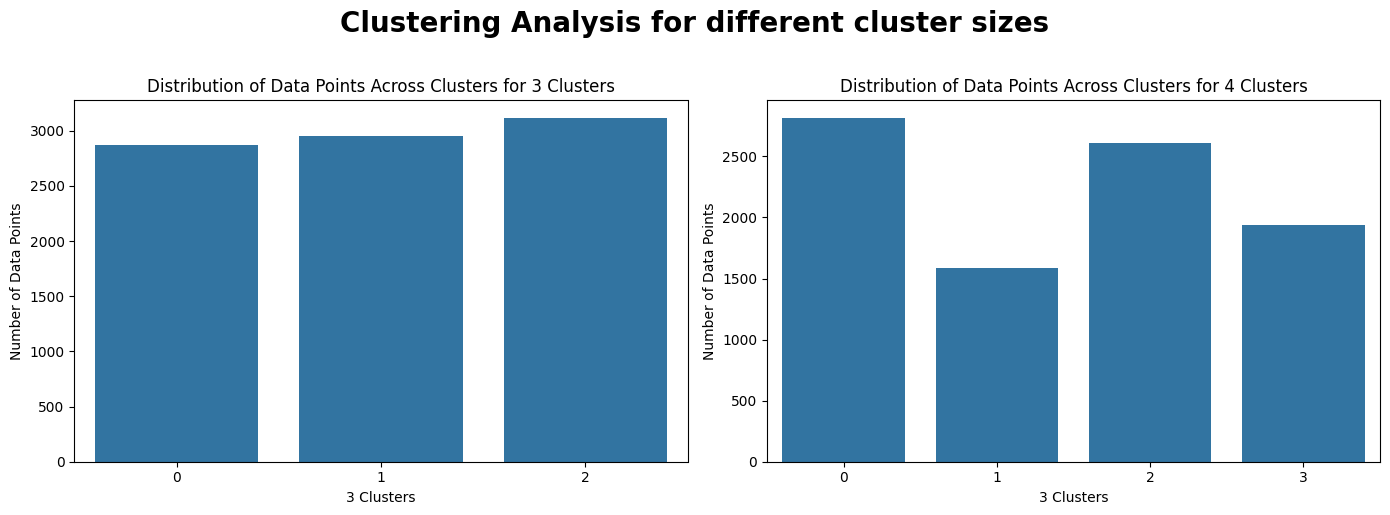

In [20]:
df_CreditCardAgency_WithLabel = df_CreditCardAgency_scaled.copy(deep=True)

# Now add clusters back to dataframe
model = KMeans(n_clusters = 3, n_init=10, init = 'k-means++', random_state = 315)
model.fit(df_CreditCardAgency_WithLabel)
cluster_labels = model.labels_

df_CreditCardAgency_WithLabel['3 Clusters'] = cluster_labels

model = KMeans(n_clusters = 4, n_init=10, init = 'k-means++', random_state = 315)
model.fit(df_CreditCardAgency_WithLabel)
cluster_labels = model.labels_

df_CreditCardAgency_WithLabel['4 Clusters'] = cluster_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()

# Create a visualization to show the distribution of data points across clusters
sns.countplot(x='3 Clusters', data=df_CreditCardAgency_WithLabel, ax=axes[0])
axes[0].set_xlabel('3 Clusters')
axes[0].set_ylabel('Number of Data Points')
axes[0].set_title('Distribution of Data Points Across Clusters for 3 Clusters')

# Create a visualization to show the distribution of data points across clusters
sns.countplot(x='4 Clusters', data=df_CreditCardAgency_WithLabel, ax=axes[1])
axes[1].set_xlabel('3 Clusters')
axes[1].set_ylabel('Number of Data Points')
axes[1].set_title('Distribution of Data Points Across Clusters for 4 Clusters')

plt.suptitle(f'Clustering Analysis for different cluster sizes', y=1.02, fontsize=20, fontweight='bold')
plt.subplots_adjust(top=0.92)  

plt.tight_layout()
plt.show()
print()
print()


##### **Clustering Analysis Results** #####
    Based on the visuals of the comparison plots, going with 3 clusters is the better approach.
    Results are much cleaner and clearer. The addition of the 4th cluster creates a small subset (500 data points)
    which doesn't really add to the intrepretation.

#### **Dimensionality Reduction** ####

In [21]:

# PCA
X_pca = PCA(n_components=2).fit_transform(df_CreditCardAgency_scaled)

# Feature Agglomeration
X_fa = FeatureAgglomeration(n_clusters=2).fit_transform(df_CreditCardAgency_scaled)

# t-SNE
X_tsne = TSNE(n_components=2, random_state=315).fit_transform(df_CreditCardAgency_scaled)

# TruncatedSVD
X_svd = TruncatedSVD(n_components=2).fit_transform(df_CreditCardAgency_scaled)

#### **Plot Dimensionality Reduction Results** ####

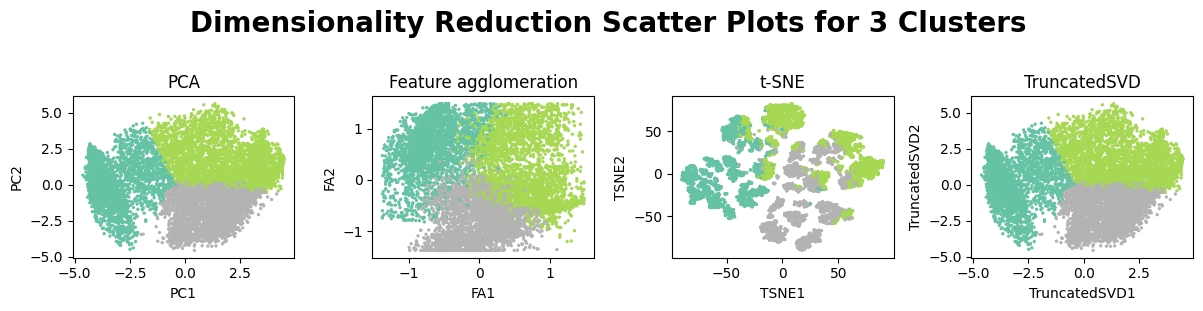

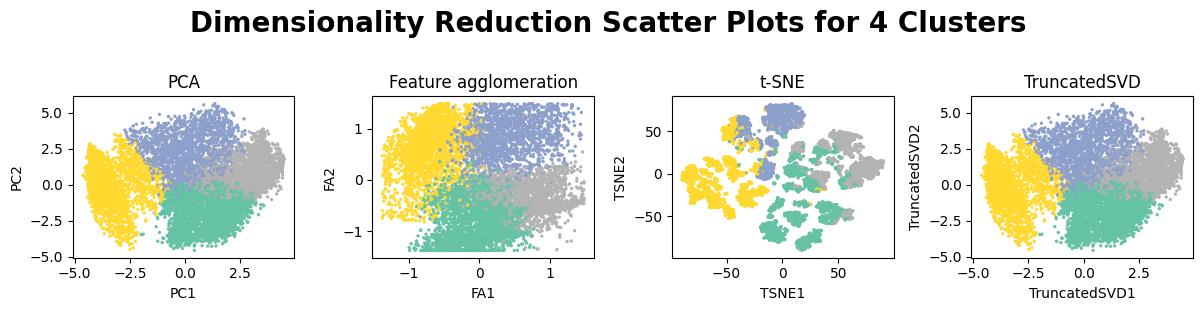

In [22]:

def DisplayScatterPlots(color_labels, plot_title):
    ncols = 4
    nrows = 1

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3))

    # PCA
    axes[0].set_title('PCA')
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=color_labels, cmap='Set2', s=2)
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')

    # Feature Agglomeration
    axes[1].set_title('Feature agglomeration')
    axes[1].scatter(X_fa[:, 0], X_fa[:, 1], c=color_labels, cmap='Set2' ,s=2)
    axes[1].set_xlabel('FA1')
    axes[1].set_ylabel('FA2')

    # t-SNE
    axes[2].set_title('t-SNE')
    axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=color_labels, cmap='Set2', s=2)
    axes[2].set_xlabel('TSNE1')
    axes[2].set_ylabel('TSNE2')

    # TruncatedSVD
    axes[3].set_title('TruncatedSVD')
    axes[3].scatter(X_svd[:, 0], X_svd[:, 1], c=color_labels, cmap='Set2', s=2)
    axes[3].set_xlabel('TruncatedSVD1')
    axes[3].set_ylabel('TruncatedSVD2')

    plt.suptitle(f'Dimensionality Reduction Scatter Plots for {plot_title}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout()
    plt.show()
    print()
    print()

DisplayScatterPlots(df_CreditCardAgency_WithLabel['3 Clusters'], '3 Clusters')

DisplayScatterPlots(df_CreditCardAgency_WithLabel['4 Clusters'], '4 Clusters')

##### **Dimensionality Conclusions** #####
    3 Clusters and PCA
        - 3 Clusters gives cleaner/easier to interpret results
        - PCA shows more cohesive, continuous, dense cluster regions

## **4. Supervised Learning** ##
    Examine Classification models to find best performing model.
    Use Classification rather than Regression Model because the labels are discrete categories, not continuous values.
    Evaluate model performance for both "3 Cluster" and "4 Cluster" labels.

***********************************
Description Stats
***********************************

                             Feature   count          mean       std  \
0                            BALANCE  8950.0 -1.270244e-17  1.000056   
1                  BALANCE_FREQUENCY  8950.0 -1.270244e-17  1.000056   
2                          PURCHASES  8950.0 -2.540488e-17  1.000056   
3                   ONEOFF_PURCHASES  8950.0  2.540488e-17  1.000056   
4             INSTALLMENTS_PURCHASES  8950.0 -1.270244e-17  1.000056   
5                       CASH_ADVANCE  8950.0  6.351220e-18  1.000056   
6                PURCHASES_FREQUENCY  8950.0 -9.526830e-18  1.000056   
7         ONEOFF_PURCHASES_FREQUENCY  8950.0  0.000000e+00  1.000056   
8   PURCHASES_INSTALLMENTS_FREQUENCY  8950.0  3.969512e-17  1.000056   
9             CASH_ADVANCE_FREQUENCY  8950.0  1.587805e-17  1.000056   
10                  CASH_ADVANCE_TRX  8950.0  1.905366e-17  1.000056   
11                     PURCHASES_TRX  8950.0 

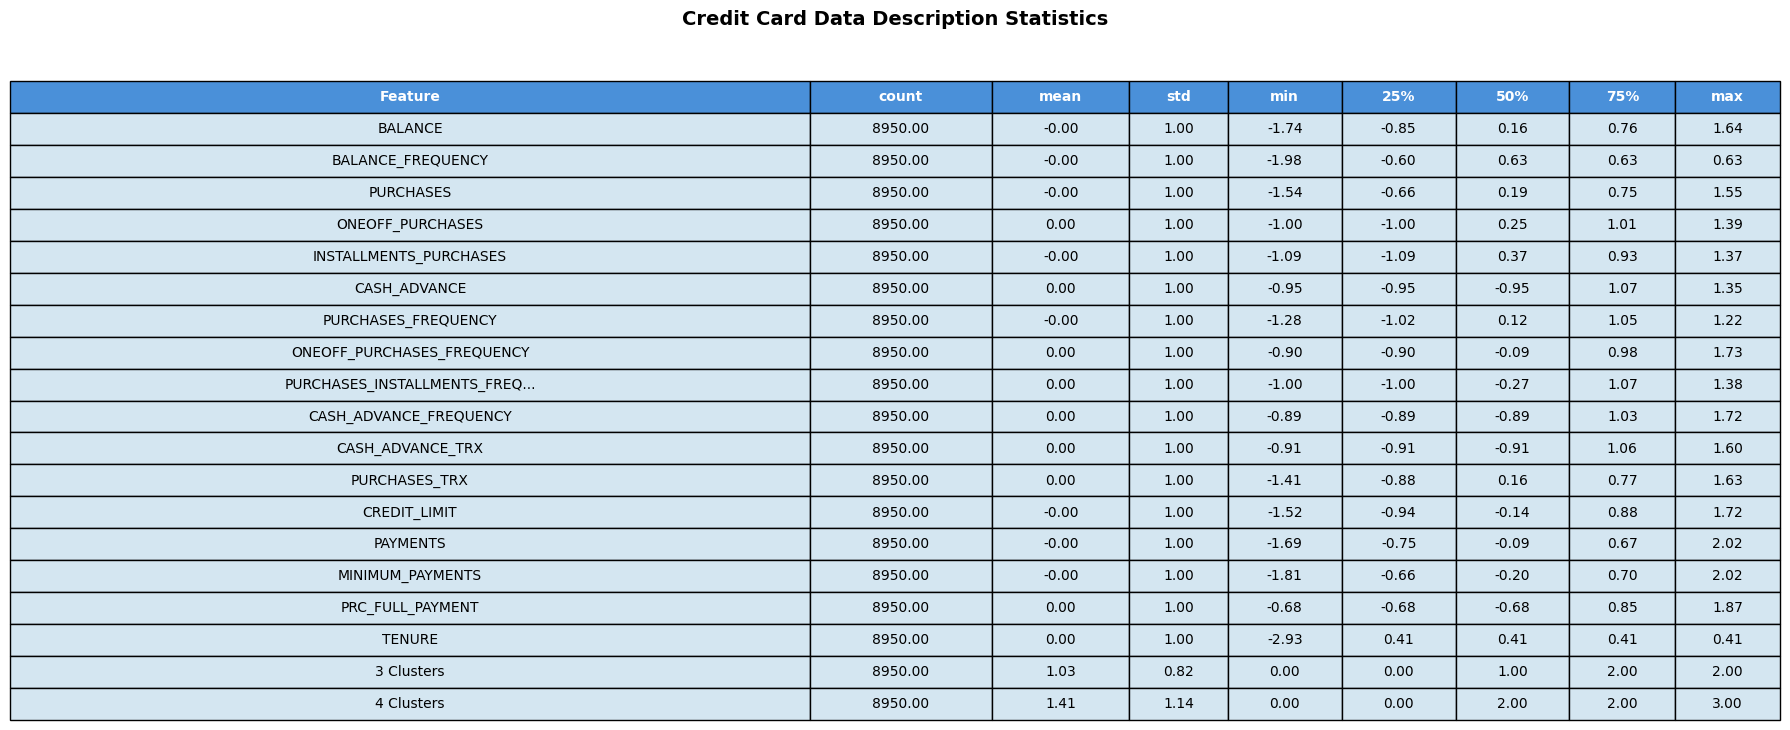

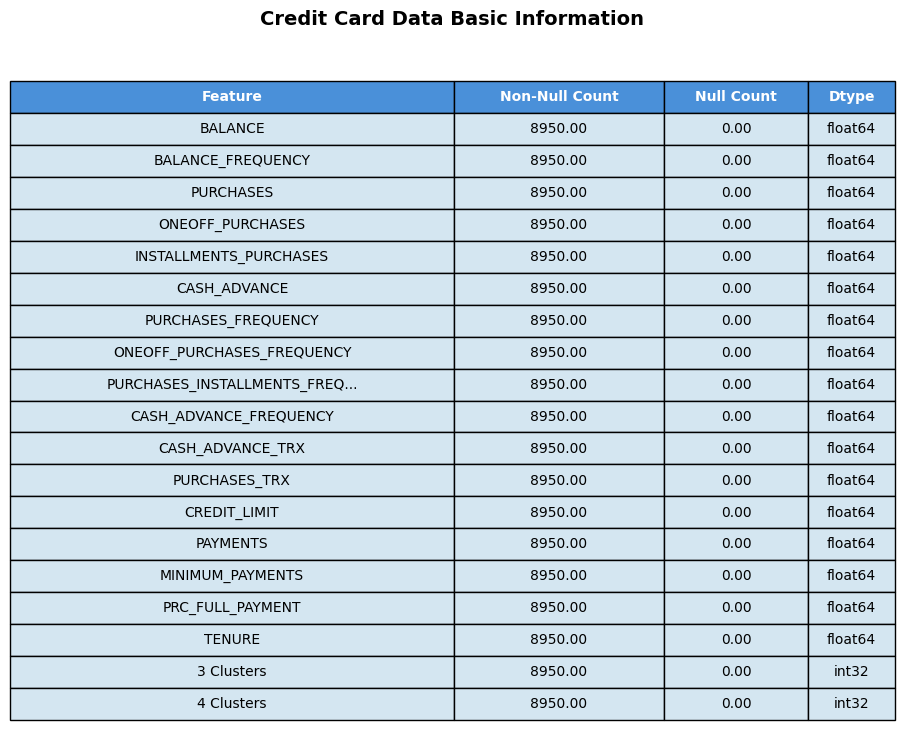

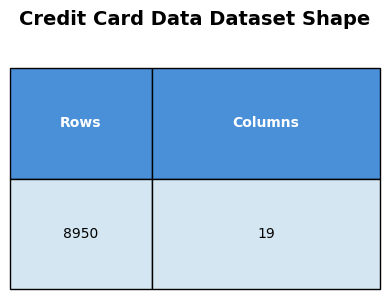




No data to display: Credit Card Data Missing Categorical (String) Data

No data to display: Credit Card Data Missing Numeric Data



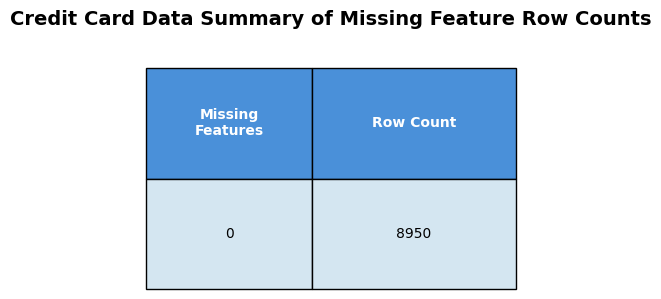

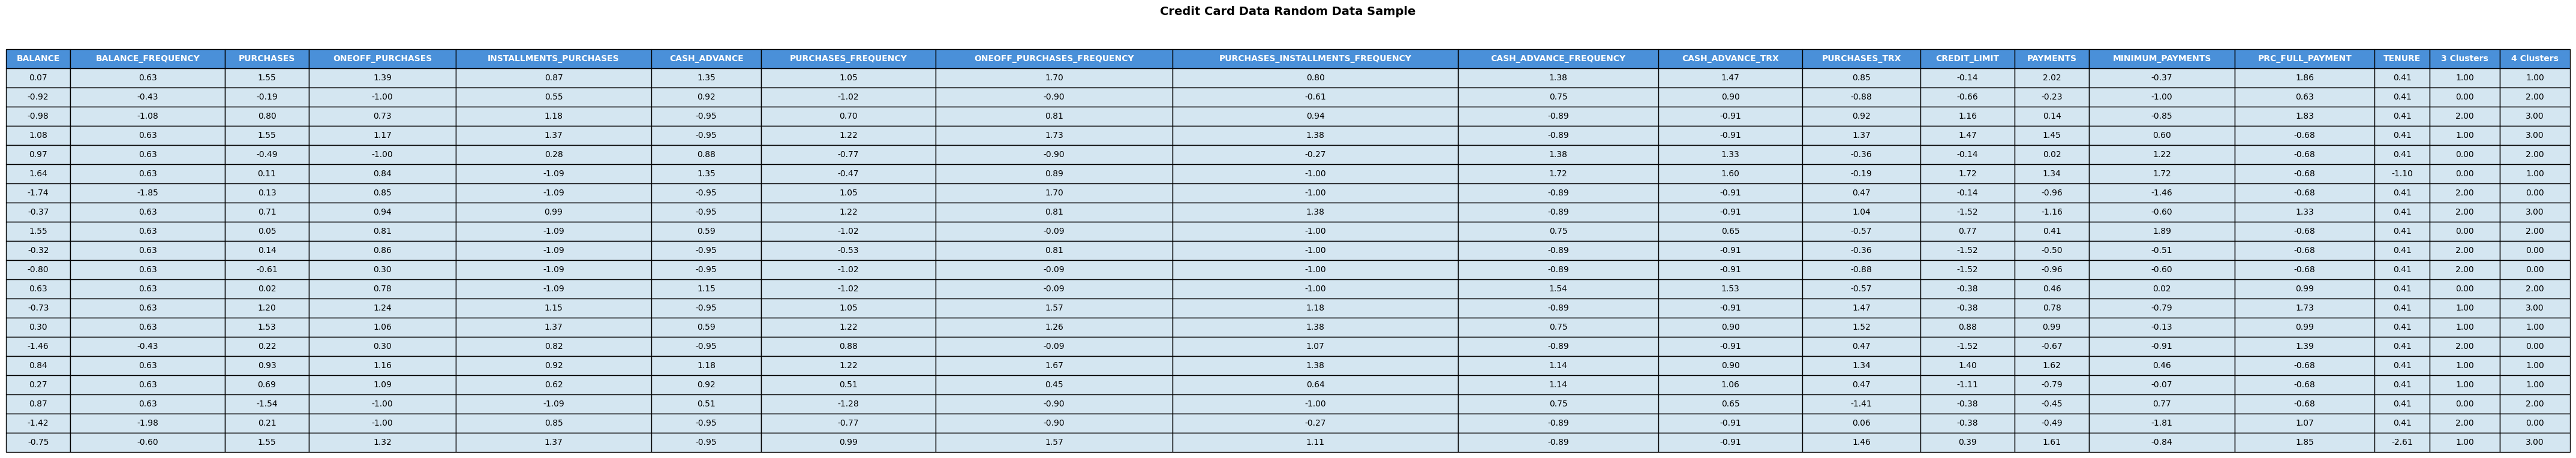

In [23]:
# Examine scaled dataframe with category labels
PrintDataFrameStatistics(df_CreditCardAgency_WithLabel)

##### **Handle Imbalances Before Classification** #####
    - Class Imbalances handled by using class_weight='balanced' during model instantiation

##### **Classification Models Utility Functions** #####

In [24]:
#
# LogisticRegression
# 
def RunLogisticRegression(df_target, target_label, plot_title=None, apply_scaling=False, apply_pca=False):

    X = df_target.drop(target_label, axis=1)
    y = df_target[target_label]

    #
    # Split Data into Training/Test => 80/20
    #
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

    if apply_scaling == True:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)  # fit + transform
        X_test = scaler.transform(X_test)        # transform only (uses training params)

    # PCA - after scaling, before model
    if apply_pca:
        pca = PCA(n_components=0.95)
        X_train = pca.fit_transform(X_train)
        X_test = pca.transform(X_test)
        print(f'PCA Components: {pca.n_components_}')
        print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
        print()        

    # Balanced Class Weight 
    model = LogisticRegression(random_state=315, max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    #
    # Predictions
    #
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    #
    # Metrics
    #
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print(f'{plot_title} LOGISTIC REGRESSION RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    #
    # Classification Report (includes precision, recall, F1)
    #
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    print(classification_report(y_test, test_predictions))
    print()

    #
    # Confusion Matrix
    #
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Logistic Regression - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    #
    # Feature Importance
    #
    print('-' * 60)
    print(f'{plot_title} FEATURE IMPORTANCE')
    print('-' * 60)
    
    # Multi-class: coef_ is (n_classes, n_features) - average absolute values
    avg_importance = pd.Series(
        np.abs(model.coef_).mean(axis=0),
        index=X.columns
    ).sort_values(ascending=False)
    
    print(avg_importance)
    print()

    plt.figure(figsize=(10, 6))
    avg_importance.sort_values().plot(kind='barh')
    plt.xlabel('Average Absolute Coefficient')
    plt.title(f'{plot_title} Feature Importance - Logistic Regression', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': test_f1,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }


#
# RandomForestClassifier
# 
def RunRandomForestClassifier(df_target, target_label, plot_title=None, apply_scaling=False, apply_pca=False):

    X = df_target.drop(target_label, axis=1)
    y = df_target[target_label]

    #
    # Split Data into Training/Test => 80/20
    #
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

    if apply_scaling == True:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # PCA - after scaling, before model
    if apply_pca:
        pca = PCA(n_components=0.95)
        X_train = pca.fit_transform(X_train)
        X_test = pca.transform(X_test)
        print(f'PCA Components: {pca.n_components_}')
        print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
        print()             

    # Balanced Class Weight 
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=315,
        n_jobs=-1,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)

    #
    # Predictions
    #
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    #
    # Metrics
    #
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print('RANDOM FOREST CLASSIFIER RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    #
    # Classification Report
    #
    print('-' * 60)
    print('TEST DATA - Classification Report')
    print('-' * 60)
    print(classification_report(y_test, test_predictions))
    print()

    #
    # Confusion Matrix
    #
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title('Random Forest - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    #
    # Feature Importance
    #
    print('-' * 60)
    print('FEATURE IMPORTANCE')
    print('-' * 60)
    
    # RandomForest uses feature_importances_ (not coef_)
    feature_importance = pd.Series(
        model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)
    
    print(feature_importance)
    print()

    plt.figure(figsize=(10, 6))
    feature_importance.sort_values().plot(kind='barh')
    plt.xlabel('Feature Importance (Gini)')
    plt.title('Feature Importance - Random Forest', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': test_f1,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }



def CompareClassificationResults(results_dict, title='Classifier Comparison'):
    
    sns.set_style("whitegrid")
    
    #
    # 1. Calculate all metrics
    #
    metrics_data = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        
        metrics_data.append({
            'Model': name,
            'Train Accuracy': results['train_accuracy'],
            'Test Accuracy': results['test_accuracy'],
            'Balanced Accuracy': balanced_accuracy_score(y_test, test_predictions),
            'Precision': precision_score(y_test, test_predictions, average='weighted'),
            'Recall': recall_score(y_test, test_predictions, average='weighted'),
            'F1 Score': results['f1_score'],
            'Gap': results['train_accuracy'] - results['test_accuracy']
        })
    
    df_comparisons = pd.DataFrame(metrics_data).set_index('Model')
    
    #
    # 2. Print Metrics Table
    #
    print('=' * 70)
    print(title)
    print('=' * 70)
    print(df_comparisons.round(4))
    print()

    DisplayTable(df_comparisons, 'Classification Comparisons',show_index=True)
    
    #
    # 3. Accuracy Comparison (Train vs Test vs Balanced)
    #
    accuracy_metrics = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        
        accuracy_metrics.append({'Model': name, 'Metric': 'Train Accuracy', 'Score': results['train_accuracy']})
        accuracy_metrics.append({'Model': name, 'Metric': 'Test Accuracy', 'Score': results['test_accuracy']})
        accuracy_metrics.append({'Model': name, 'Metric': 'Balanced Accuracy', 'Score': balanced_accuracy_score(y_test, test_predictions)})
    
    acc_df = pd.DataFrame(accuracy_metrics)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=acc_df, x='Metric', y='Score', hue='Model', palette='deep')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    plt.title('Accuracy Metrics Comparison', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 4. Precision / Recall / F1 Comparison
    #
    prf_metrics = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        
        prf_metrics.append({'Model': name, 'Metric': 'Precision', 'Score': precision_score(y_test, test_predictions, average='weighted')})
        prf_metrics.append({'Model': name, 'Metric': 'Recall', 'Score': recall_score(y_test, test_predictions, average='weighted')})
        prf_metrics.append({'Model': name, 'Metric': 'F1 Score', 'Score': results['f1_score']})
    
    prf_df = pd.DataFrame(prf_metrics)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=prf_df, x='Metric', y='Score', hue='Model', palette='Set2')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    plt.title('Precision / Recall / F1 Comparison', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 5. Gap Comparison (Overfitting indicator)
    #
    gap_data = pd.DataFrame({
        'Model': list(results_dict.keys()),
        'Gap': [r['train_accuracy'] - r['test_accuracy'] for r in results_dict.values()]
    })
    
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=gap_data, x='Model', y='Gap', palette='deep')
    ax.bar_label(ax.containers[0], fmt='%.4f', fontsize=10)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.title('Overfitting Indicator (Lower is Better)', fontweight='bold')
    plt.ylabel('Train - Test Accuracy Gap')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 6. Confusion Matrices
    #
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    palettes = ['Blues', 'Greens', 'Oranges', 'Purples']
    
    for i, (name, results) in enumerate(results_dict.items()):
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        cm = confusion_matrix(y_test, test_predictions)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap=palettes[i % len(palettes)], 
                    ax=axes[i], cbar=True)
        axes[i].set_title(f'{name}', fontweight='bold')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    
    plt.suptitle('Confusion Matrix Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 7. Metrics Heatmap
    #
    plt.figure(figsize=(12, len(results_dict) * 0.8 + 2))
    heatmap_cols = ['Test Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 Score']
    sns.heatmap(df_comparisons[heatmap_cols], annot=True, fmt='.4f', cmap='YlGnBu', 
                vmin=0, vmax=1, linewidths=0.5)
    plt.title('Model Metrics Heatmap', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return df_comparisons

def CheckClusterDistributions(df_target, feature_name, title):
    print(f'{title} Cluster Distribution Comparisons')
    valueCounts = df_target[feature_name].value_counts()
    print(f'ValueCounts: {valueCounts}')
    normalizedValueCounts = df_target[feature_name].value_counts(normalize=True) * 100
    print(f'NormalizedValueCounts: {normalizedValueCounts}')
    print()


##### **Cross Validation Utility Methods** #####

In [25]:
def ApplyCrossValidationClassification(model, df_target, target_label, plot_label):

    X = df_target.drop(columns=target_label)
    y = df_target[target_label]

    # Split for train/test calculation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

    # Fit model and calculate train/test metrics
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    test_f1 = f1_score(y_test, model.predict(X_test), average='weighted')

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Cross-validation for Accuracy
    cv_accuracy = cross_val_score(model, X, y, scoring='accuracy', n_jobs=-1, cv=kf)

    # Cross-validation for F1 Score
    cv_f1 = cross_val_score(model, X, y, scoring='f1_weighted', n_jobs=-1, cv=kf)

    # Accuracy stats
    acc_mean = np.mean(cv_accuracy)
    acc_std = np.std(cv_accuracy)
    acc_moe = 1.96 * acc_std / np.sqrt(len(cv_accuracy))

    # F1 stats
    f1_mean = np.mean(cv_f1)
    f1_std = np.std(cv_f1)
    f1_moe = 1.96 * f1_std / np.sqrt(len(cv_f1))

    print(plot_label)
    print(f'Mean CV Accuracy: {acc_mean:.4f} ± {acc_moe:.4f}')
    print(f'95% CI Accuracy: {acc_mean - acc_moe:.4f} to {acc_mean + acc_moe:.4f}')
    print(f'Mean CV F1 Score: {f1_mean:.4f} ± {f1_moe:.4f}')
    print(f'95% CI F1: {f1_mean - f1_moe:.4f} to {f1_mean + f1_moe:.4f}')
    print(f'Train Accuracy: {train_accuracy:.4f}')
    print(f'Test Accuracy: {test_accuracy:.4f}')
    print(f'Test F1 Score: {test_f1:.4f}')

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy boxplot
    axes[0].boxplot(cv_accuracy)
    axes[0].axhline(acc_mean - acc_moe, linestyle='--', color='teal', label='95% CI')
    axes[0].axhline(acc_mean + acc_moe, linestyle='--', color='teal')
    axes[0].axhline(test_accuracy, color='purple', label='Test Accuracy')
    axes[0].axhline(train_accuracy, color='red', label='Train Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'CV Accuracy - {plot_label}')
    axes[0].legend(loc='best')

    # F1 boxplot
    axes[1].boxplot(cv_f1)
    axes[1].axhline(f1_mean - f1_moe, linestyle='--', color='teal', label='95% CI')
    axes[1].axhline(f1_mean + f1_moe, linestyle='--', color='teal')
    axes[1].axhline(test_f1, color='purple', label='Test F1')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title(f'CV F1 Score - {plot_label}')
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

    print()
    print()

    return {'cv_accuracy': cv_accuracy, 'cv_f1': cv_f1}

##### **Run and Examine Classification Model Results** #####
    RMSE treats labels as numbers and measures degrees of being wrong.
    Accuracy/F1-Score treats labels as categories and predictions is either right or wrong.
    Accuracy/F1-Score is more suited to classification models.

3 Clusters Cluster Distribution Comparisons
ValueCounts: 3 Clusters
2    3120
1    2955
0    2875
Name: count, dtype: int64
NormalizedValueCounts: 3 Clusters
2    34.860335
1    33.016760
0    32.122905
Name: proportion, dtype: float64

4 Clusters Cluster Distribution Comparisons
ValueCounts: 4 Clusters
0    2818
2    2611
3    1938
1    1583
Name: count, dtype: int64
NormalizedValueCounts: 4 Clusters
0    31.486034
2    29.173184
3    21.653631
1    17.687151
Name: proportion, dtype: float64

Logistic Regression - 3 Clusters
3 Clusters LOGISTIC REGRESSION RESULTS
Training Accuracy: 0.9975
Testing Accuracy:  0.9927
Testing F1 Score:  0.9927
Gap:               0.0047

------------------------------------------------------------
3 Clusters TEST DATA - Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       566
           1       0.99      0.99      0.99     

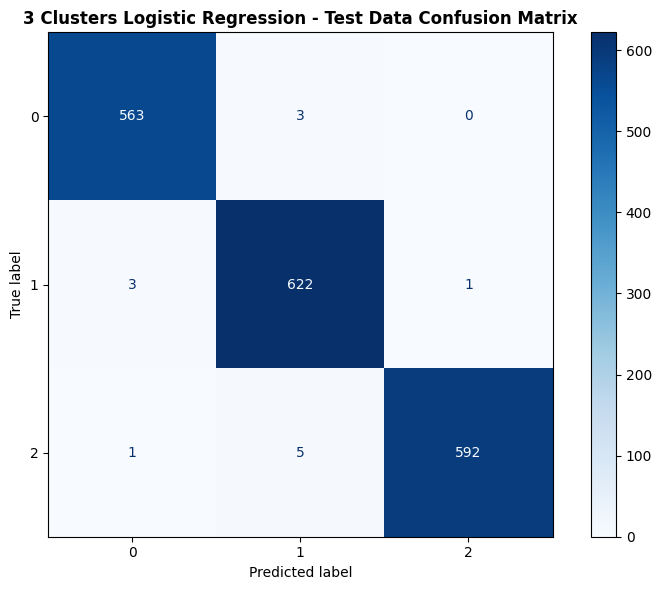


------------------------------------------------------------
3 Clusters FEATURE IMPORTANCE
------------------------------------------------------------
PURCHASES_TRX                       2.167735
PURCHASES_FREQUENCY                 2.069229
CASH_ADVANCE_TRX                    1.956678
PURCHASES                           1.919262
CASH_ADVANCE                        1.910139
INSTALLMENTS_PURCHASES              1.777220
BALANCE                             1.674199
ONEOFF_PURCHASES                    1.661316
ONEOFF_PURCHASES_FREQUENCY          1.617076
PURCHASES_INSTALLMENTS_FREQUENCY    1.443330
CASH_ADVANCE_FREQUENCY              1.411321
MINIMUM_PAYMENTS                    1.366063
PAYMENTS                            1.261652
BALANCE_FREQUENCY                   1.053218
CREDIT_LIMIT                        0.754538
PRC_FULL_PAYMENT                    0.752404
TENURE                              0.419674
dtype: float64



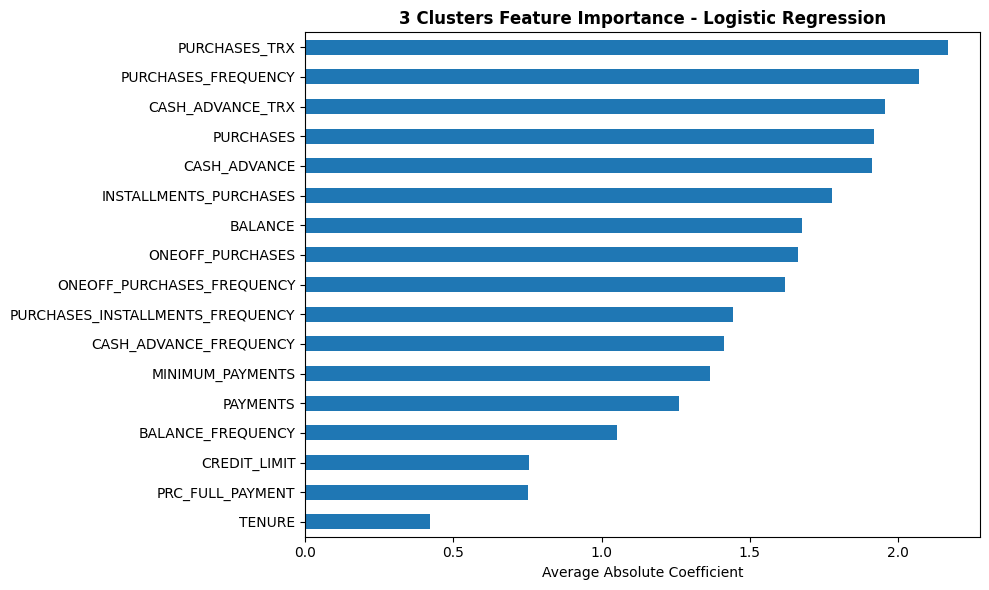

3 Clusters LinearRegression
Mean CV Accuracy: 0.9959 ± 0.0016
95% CI Accuracy: 0.9943 to 0.9975
Mean CV F1 Score: 0.9959 ± 0.0016
95% CI F1: 0.9943 to 0.9975
Train Accuracy: 0.9973
Test Accuracy: 0.9939
Test F1 Score: 0.9939


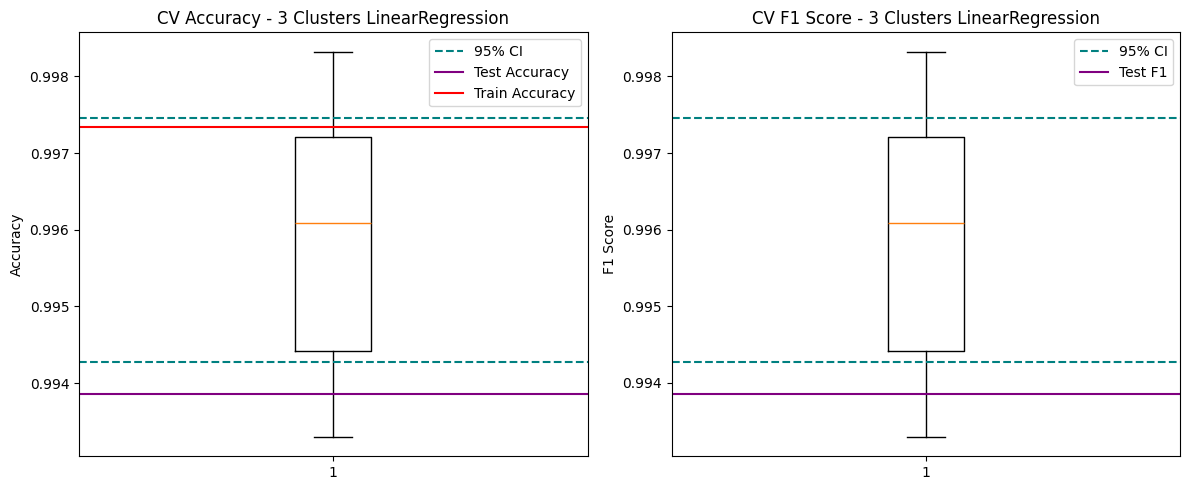





Logistic Regression - 4 Clusters
4 Clusters LOGISTIC REGRESSION RESULTS
Training Accuracy: 0.9944
Testing Accuracy:  0.9905
Testing F1 Score:  0.9905
Gap:               0.0039

------------------------------------------------------------
4 Clusters TEST DATA - Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       533
           1       0.98      0.99      0.99       348
           2       1.00      0.99      1.00       517
           3       0.98      0.99      0.99       392

    accuracy                           0.99      1790
   macro avg       0.99      0.99      0.99      1790
weighted avg       0.99      0.99      0.99      1790




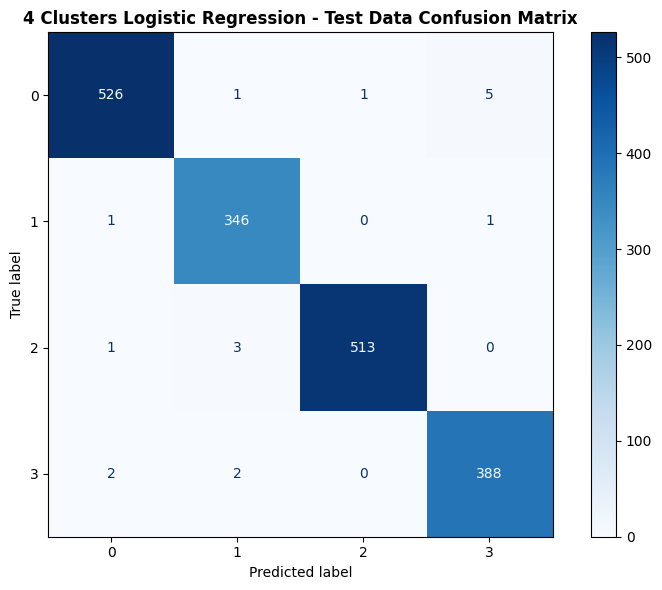


------------------------------------------------------------
4 Clusters FEATURE IMPORTANCE
------------------------------------------------------------
CASH_ADVANCE_TRX                    2.406731
CASH_ADVANCE                        2.080378
PURCHASES_TRX                       1.955502
ONEOFF_PURCHASES_FREQUENCY          1.857573
CASH_ADVANCE_FREQUENCY              1.830808
PURCHASES                           1.796923
PURCHASES_FREQUENCY                 1.782871
ONEOFF_PURCHASES                    1.641026
BALANCE                             1.344918
INSTALLMENTS_PURCHASES              1.256983
PURCHASES_INSTALLMENTS_FREQUENCY    1.184863
PAYMENTS                            1.103023
MINIMUM_PAYMENTS                    1.035528
PRC_FULL_PAYMENT                    0.842297
BALANCE_FREQUENCY                   0.810716
CREDIT_LIMIT                        0.793570
TENURE                              0.336463
dtype: float64



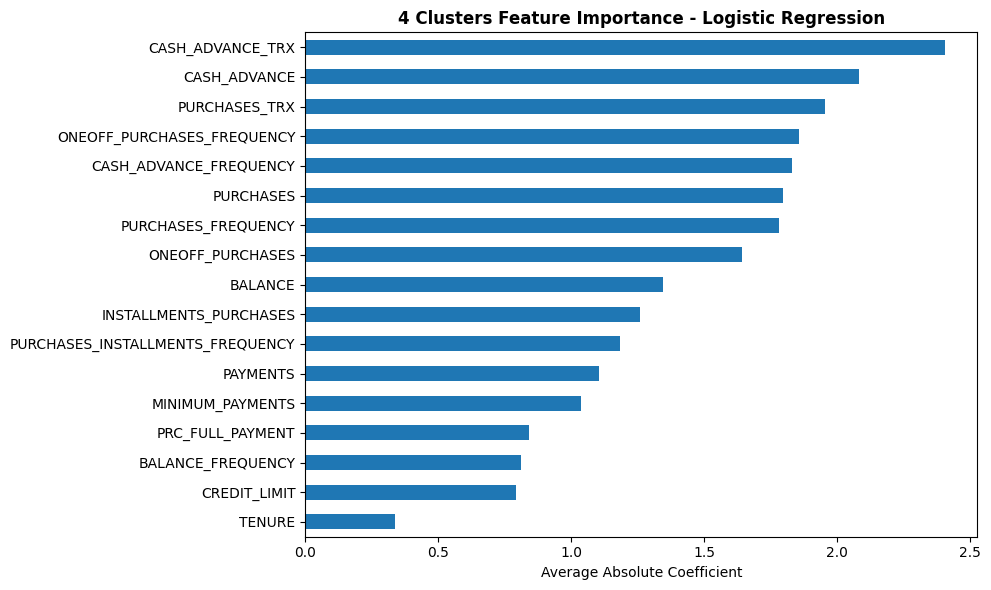

4 Clusters LinearRegression
Mean CV Accuracy: 0.9924 ± 0.0020
95% CI Accuracy: 0.9904 to 0.9944
Mean CV F1 Score: 0.9924 ± 0.0020
95% CI F1: 0.9904 to 0.9944
Train Accuracy: 0.9944
Test Accuracy: 0.9905
Test F1 Score: 0.9905


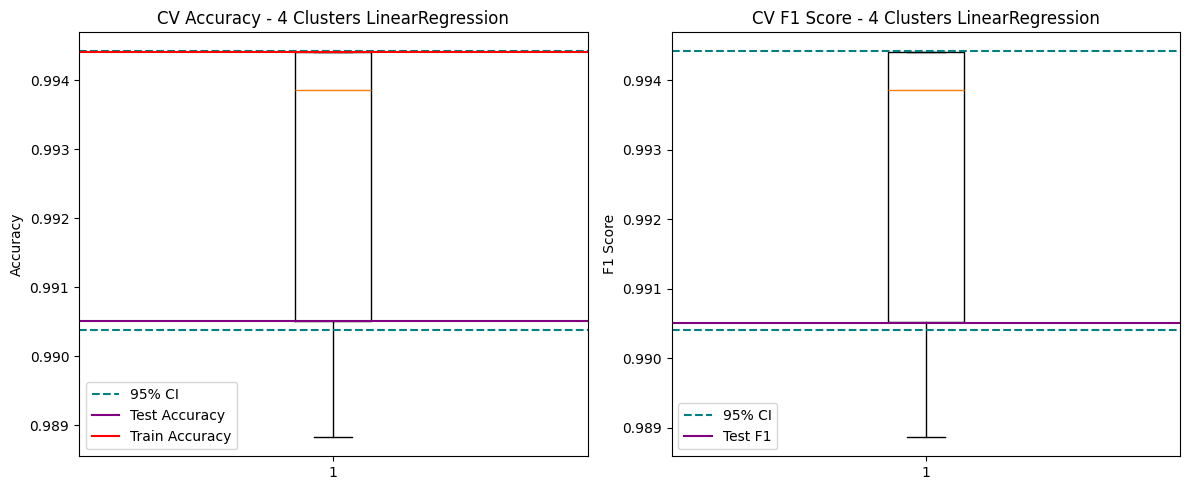





RandomForest Classifier - 3 Clusters
RANDOM FOREST CLASSIFIER RESULTS
Training Accuracy: 1.0000
Testing Accuracy:  0.9709
Testing F1 Score:  0.9709
Gap:               0.0291

------------------------------------------------------------
TEST DATA - Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       566
           1       0.96      0.97      0.97       626
           2       0.97      0.96      0.97       598

    accuracy                           0.97      1790
   macro avg       0.97      0.97      0.97      1790
weighted avg       0.97      0.97      0.97      1790




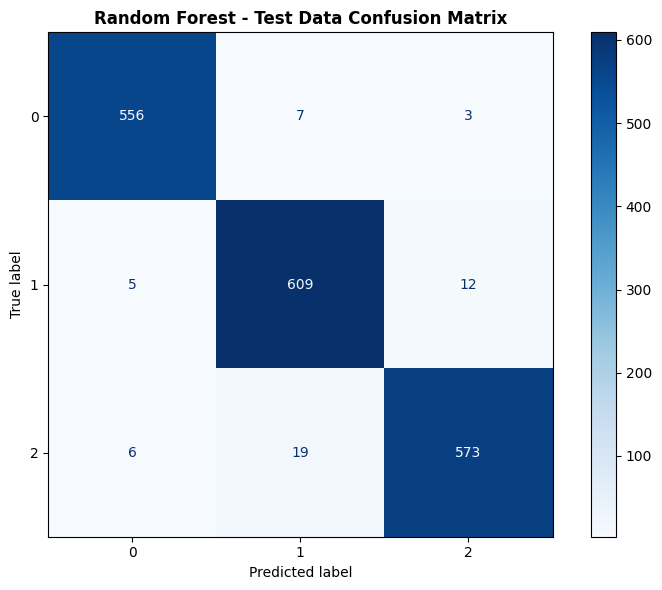


------------------------------------------------------------
FEATURE IMPORTANCE
------------------------------------------------------------
PURCHASES_TRX                       0.153766
PURCHASES_FREQUENCY                 0.108298
PURCHASES                           0.092881
CASH_ADVANCE_FREQUENCY              0.086595
BALANCE                             0.082111
CASH_ADVANCE                        0.079750
CASH_ADVANCE_TRX                    0.073458
ONEOFF_PURCHASES_FREQUENCY          0.068742
ONEOFF_PURCHASES                    0.056260
MINIMUM_PAYMENTS                    0.052343
INSTALLMENTS_PURCHASES              0.041424
PAYMENTS                            0.034358
PURCHASES_INSTALLMENTS_FREQUENCY    0.033839
BALANCE_FREQUENCY                   0.014276
CREDIT_LIMIT                        0.013537
PRC_FULL_PAYMENT                    0.005687
TENURE                              0.002674
dtype: float64



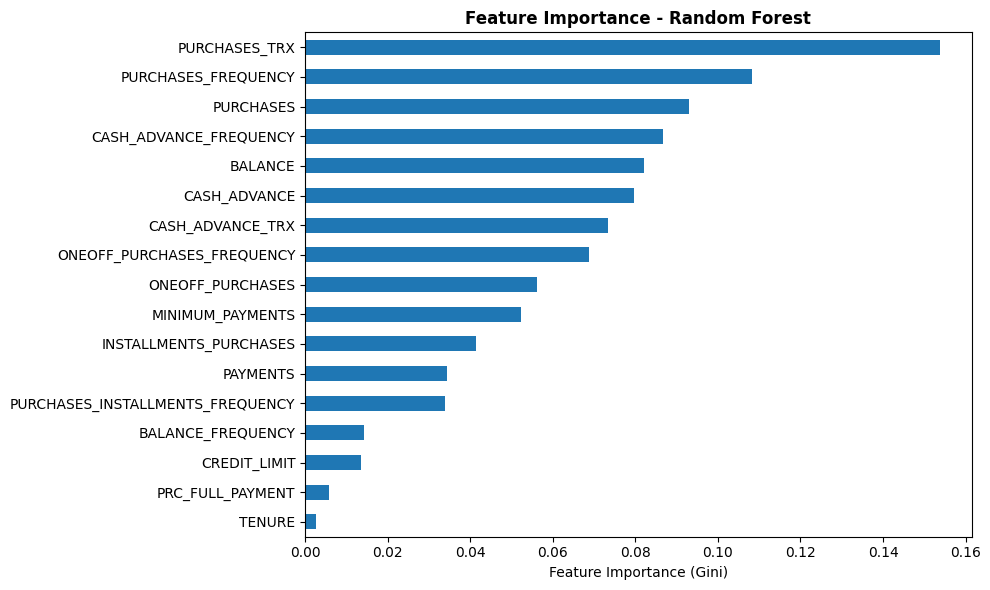

3 Clusters RandomForest
Mean CV Accuracy: 0.9684 ± 0.0019
95% CI Accuracy: 0.9665 to 0.9703
Mean CV F1 Score: 0.9684 ± 0.0019
95% CI F1: 0.9665 to 0.9703
Train Accuracy: 1.0000
Test Accuracy: 0.9709
Test F1 Score: 0.9709


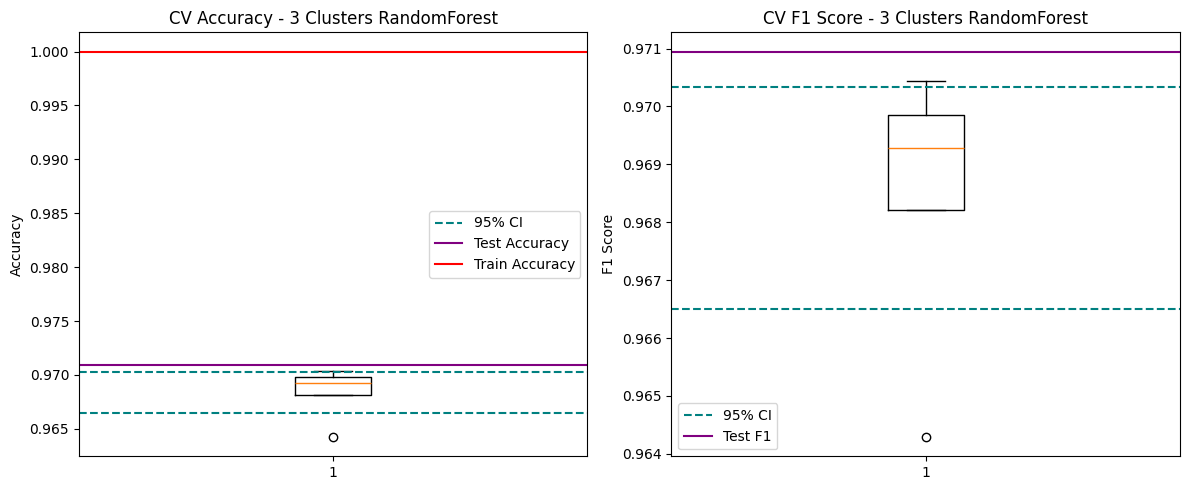





RandomForest Classifier - 4 Clusters
RANDOM FOREST CLASSIFIER RESULTS
Training Accuracy: 1.0000
Testing Accuracy:  0.9715
Testing F1 Score:  0.9715
Gap:               0.0285

------------------------------------------------------------
TEST DATA - Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       533
           1       0.97      0.98      0.97       348
           2       0.99      0.98      0.98       517
           3       0.97      0.95      0.96       392

    accuracy                           0.97      1790
   macro avg       0.97      0.97      0.97      1790
weighted avg       0.97      0.97      0.97      1790




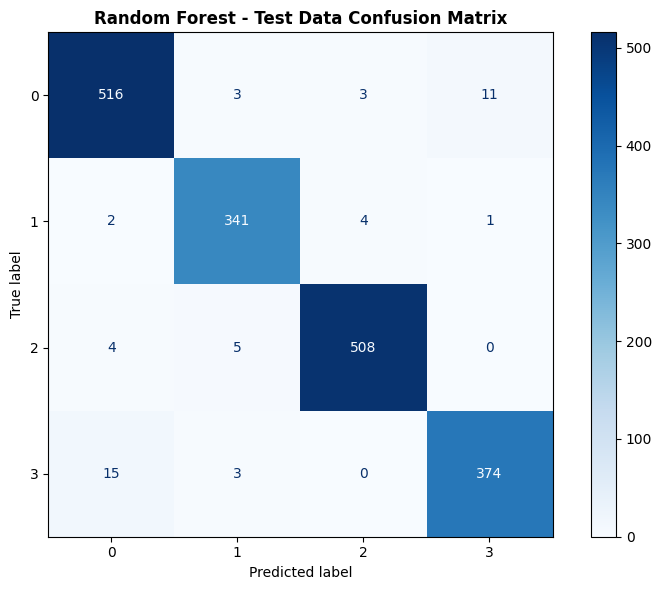


------------------------------------------------------------
FEATURE IMPORTANCE
------------------------------------------------------------
PURCHASES_TRX                       0.139248
CASH_ADVANCE                        0.115065
CASH_ADVANCE_FREQUENCY              0.107121
CASH_ADVANCE_TRX                    0.104083
PURCHASES                           0.099958
ONEOFF_PURCHASES                    0.081194
PURCHASES_FREQUENCY                 0.079052
ONEOFF_PURCHASES_FREQUENCY          0.065105
BALANCE                             0.055869
MINIMUM_PAYMENTS                    0.035897
PURCHASES_INSTALLMENTS_FREQUENCY    0.028681
INSTALLMENTS_PURCHASES              0.028295
PAYMENTS                            0.023280
BALANCE_FREQUENCY                   0.014034
CREDIT_LIMIT                        0.013532
PRC_FULL_PAYMENT                    0.008014
TENURE                              0.001571
dtype: float64



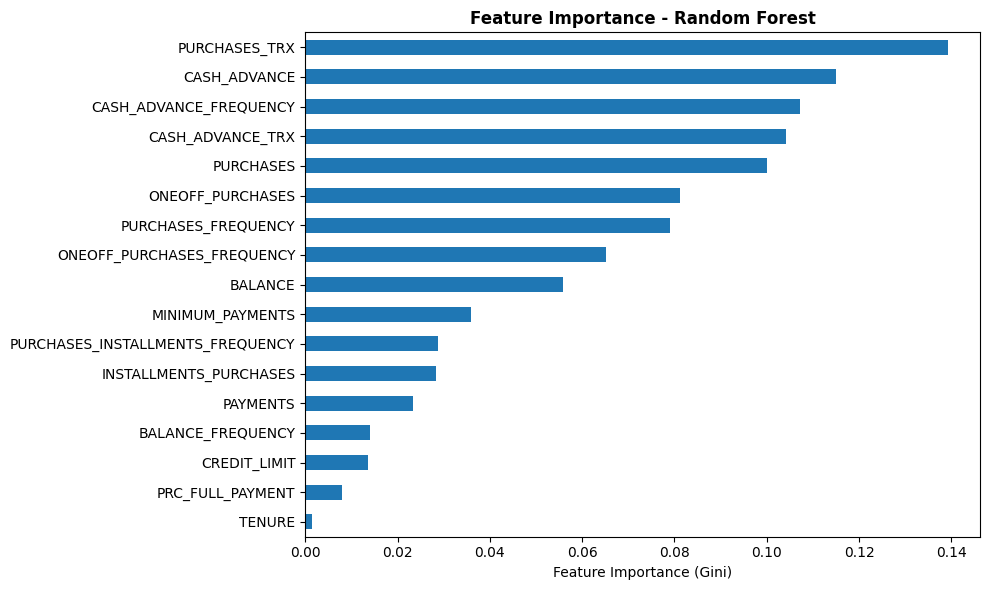

4 Clusters RandomForest
Mean CV Accuracy: 0.9703 ± 0.0025
95% CI Accuracy: 0.9677 to 0.9728
Mean CV F1 Score: 0.9703 ± 0.0025
95% CI F1: 0.9678 to 0.9728
Train Accuracy: 1.0000
Test Accuracy: 0.9715
Test F1 Score: 0.9715


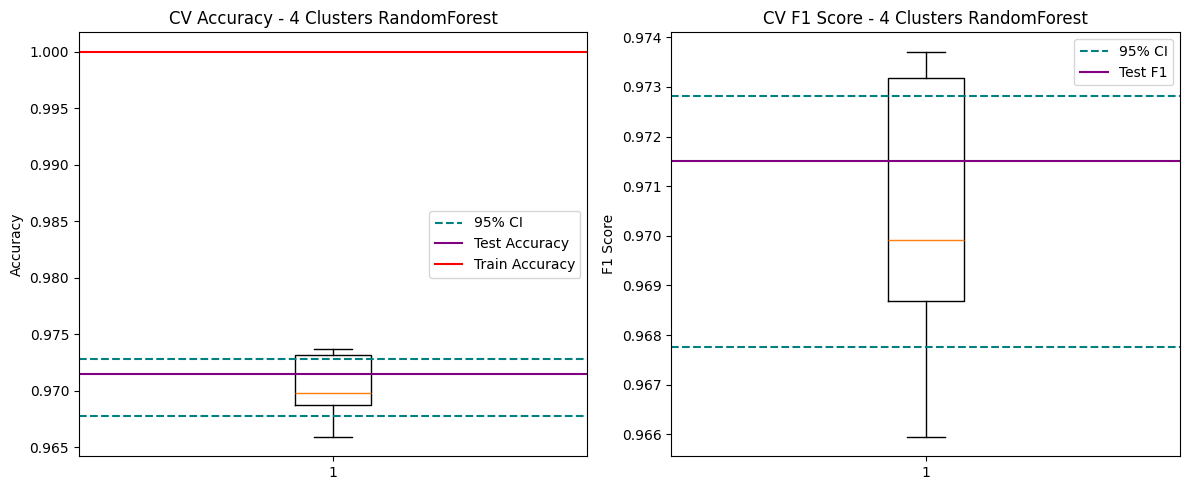





Double check the Classification Results


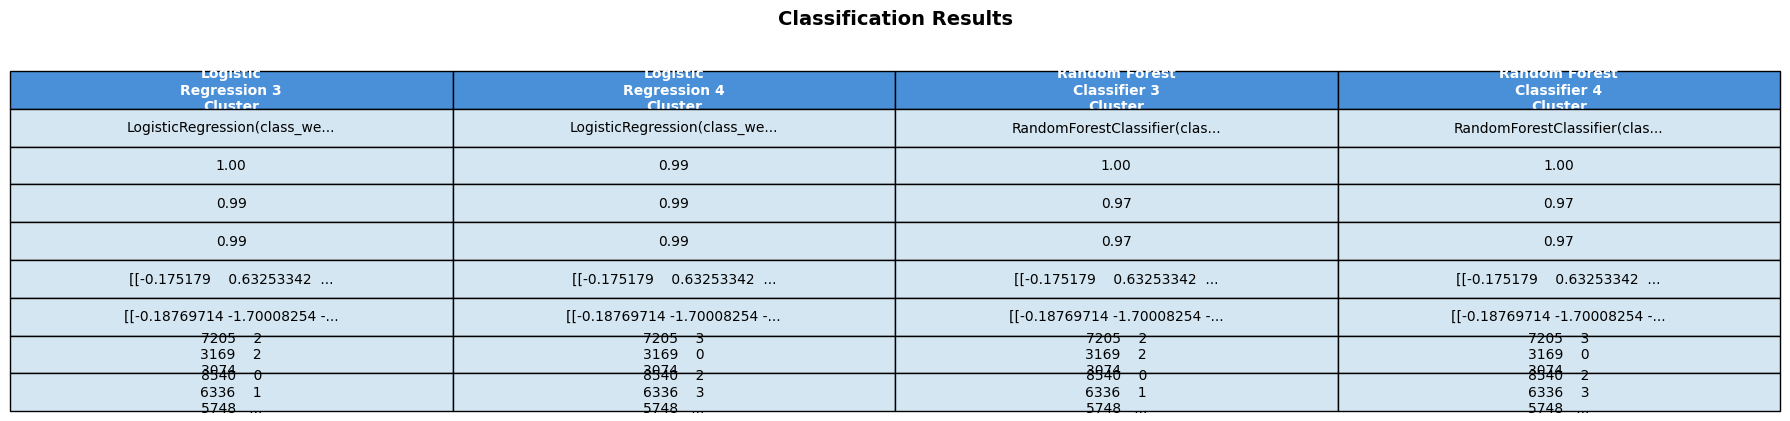



LogisticRegression vs RandomTreeClassifier Comparisons
                                    Train Accuracy  Test Accuracy  \
Model                                                               
Logistic Regression 3 Cluster               0.9975         0.9927   
Logistic Regression 4 Cluster               0.9944         0.9905   
Random Forest Classifier 3 Cluster          1.0000         0.9709   
Random Forest Classifier 4 Cluster          1.0000         0.9715   

                                    Balanced Accuracy  Precision  Recall  \
Model                                                                      
Logistic Regression 3 Cluster                  0.9871     0.9872  0.9872   
Logistic Regression 4 Cluster                  0.9889     0.9889  0.9888   
Random Forest Classifier 3 Cluster             0.9672     0.9672  0.9670   
Random Forest Classifier 4 Cluster             0.9727     0.9727  0.9726   

                                    F1 Score     Gap  
Model           

c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


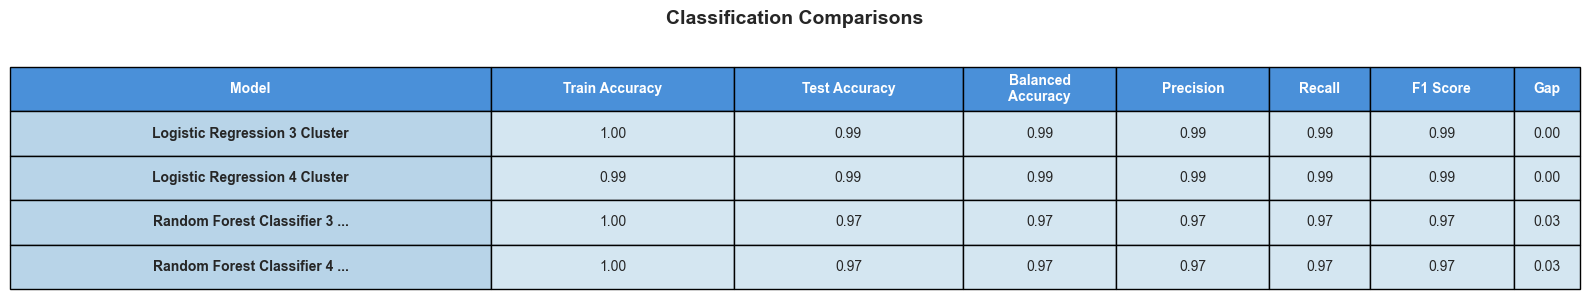

c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


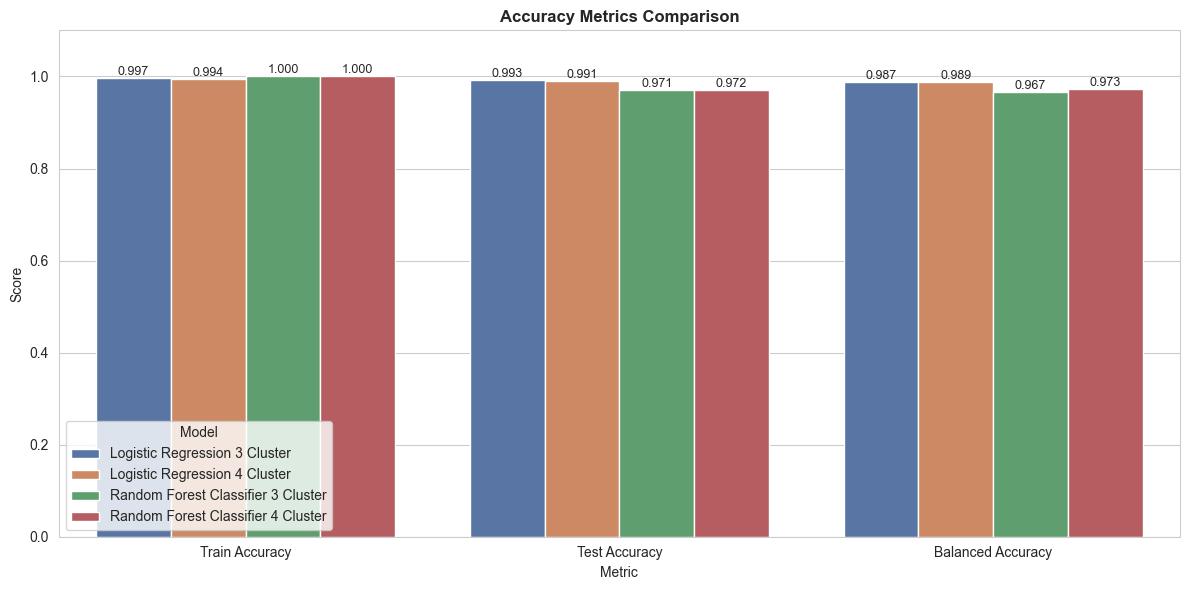

c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


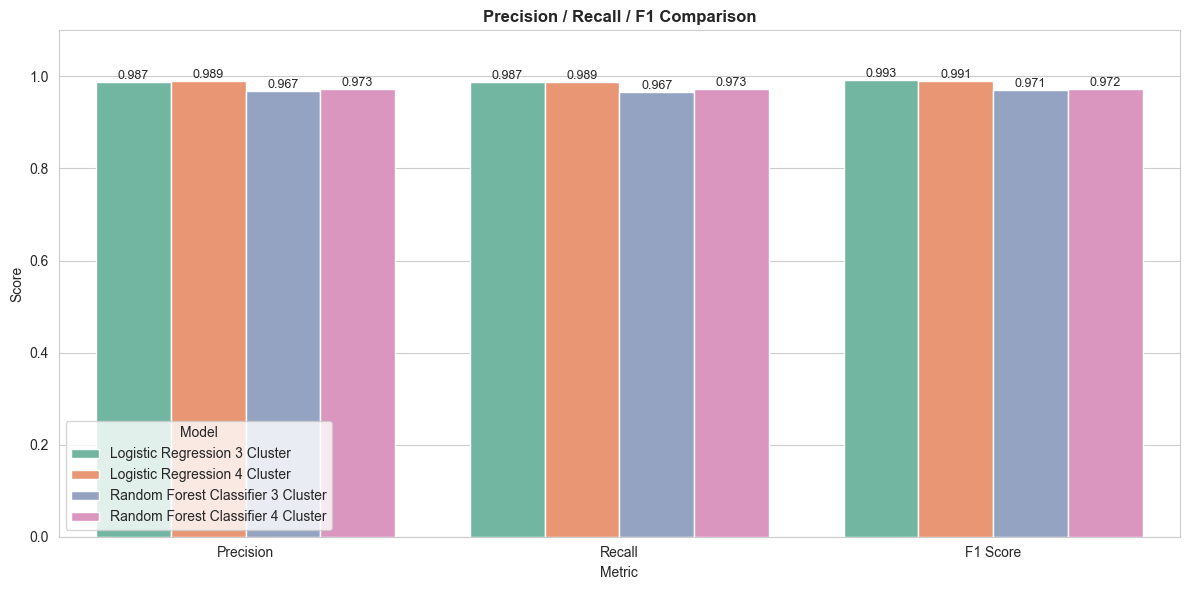

C:\Users\jxbma\AppData\Local\Temp\ipykernel_49556\1135420300.py:326: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gap_data, x='Model', y='Gap', palette='deep')


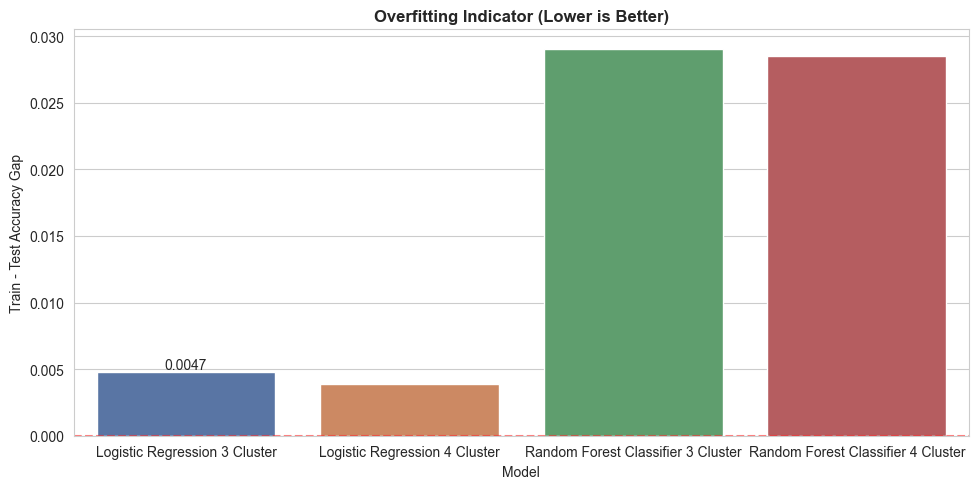

c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


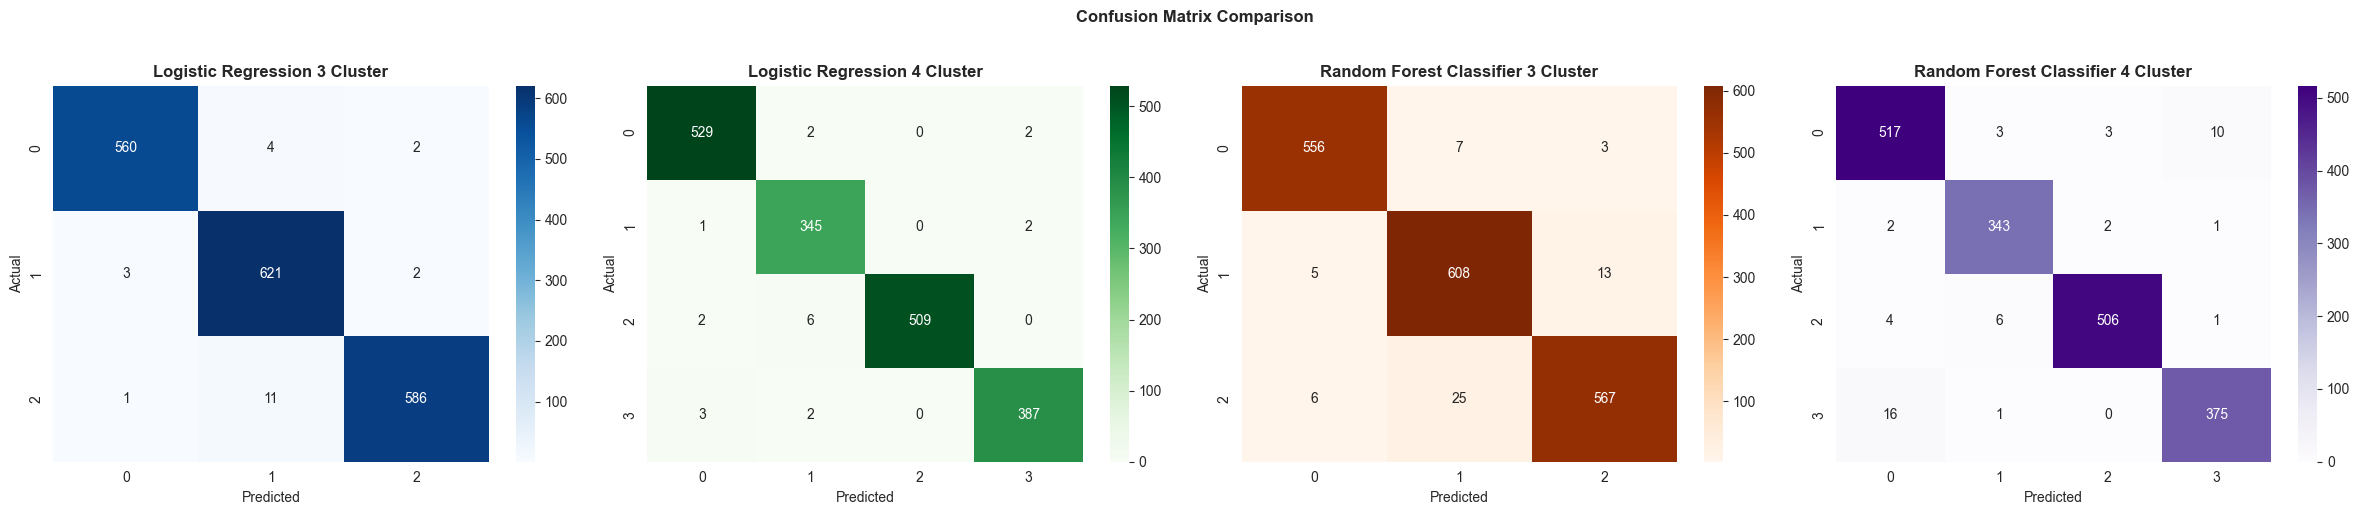

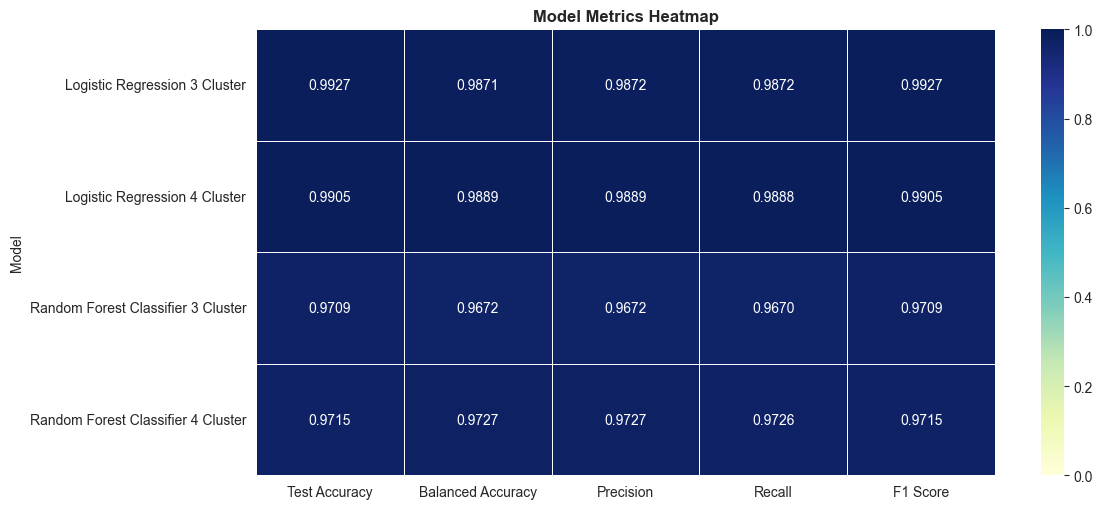

In [26]:
# df_CreditCardAgency has been imputed and optimized, but not scaled
df_CreditCardAgency_Target = df_CreditCardAgency.copy(deep=True)

if 'CUST_ID' in df_CreditCardAgency_Target:
    df_CreditCardAgency_Target.drop(columns=['CUST_ID'], inplace=True)

# Check for Imbalance
CheckClusterDistributions(df_CreditCardAgency_WithLabel, '3 Clusters', '3 Clusters')
CheckClusterDistributions(df_CreditCardAgency_WithLabel, '4 Clusters', '4 Clusters')

print('Logistic Regression - 3 Clusters')
df_CreditCardAgency_Target['Cluster'] = df_CreditCardAgency_WithLabel['3 Clusters']
results_logisticregression_3cluster = RunLogisticRegression(df_CreditCardAgency_Target, 'Cluster', plot_title='3 Clusters', apply_scaling=True)
ApplyCrossValidationClassification(results_logisticregression_3cluster['model'], df_CreditCardAgency_Target, 'Cluster', '3 Clusters LinearRegression')
print()
print()

print('Logistic Regression - 4 Clusters')
df_CreditCardAgency_Target['Cluster'] = df_CreditCardAgency_WithLabel['4 Clusters']
results_logisticregression_4cluster = RunLogisticRegression(df_CreditCardAgency_Target, 'Cluster', plot_title='4 Clusters', apply_scaling=True)
ApplyCrossValidationClassification(results_logisticregression_4cluster['model'], df_CreditCardAgency_Target, 'Cluster', '4 Clusters LinearRegression')
print()
print()


print('RandomForest Classifier - 3 Clusters')
df_CreditCardAgency_Target['Cluster'] = df_CreditCardAgency_WithLabel['3 Clusters']
results_randomforest_3cluster = RunRandomForestClassifier(df_CreditCardAgency_Target, 'Cluster', plot_title='3 Clusters', apply_scaling=True)
ApplyCrossValidationClassification(results_randomforest_3cluster['model'], df_CreditCardAgency_Target, 'Cluster', '3 Clusters RandomForest')
print()
print()

print('RandomForest Classifier - 4 Clusters')
df_CreditCardAgency_Target['Cluster'] = df_CreditCardAgency_WithLabel['4 Clusters']
results_randomforest_4cluster = RunRandomForestClassifier(df_CreditCardAgency_Target, 'Cluster', plot_title='4 Clusters', apply_scaling=True)
ApplyCrossValidationClassification(results_randomforest_4cluster['model'], df_CreditCardAgency_Target, 'Cluster', '4 Clusters RandomForest')
print()
print()


# Display Comparisons

results_dict = {
    'Logistic Regression 3 Cluster': results_logisticregression_3cluster,
    'Logistic Regression 4 Cluster': results_logisticregression_4cluster,
    'Random Forest Classifier 3 Cluster': results_randomforest_3cluster,
    'Random Forest Classifier 4 Cluster': results_randomforest_4cluster
}

print('Double check the Classification Results')
df_Results = pd.DataFrame(results_dict)
DisplayTable(df_Results, 'Classification Results')

CompareClassificationResults(results_dict, title='LogisticRegression vs RandomTreeClassifier Comparisons')
print()
print()


##### **Hyperparameter Tuning for 3 Cluster - LogisticRegression() and RandomForestClassifier()** #####
    - Find best parameters for models.
    - Compare model results to determine best model

In [27]:
def ApplyHyperParameterTuning(model, params, X_train, y_train):

    gridSearchCV = GridSearchCV(model, 
                                params, 
                                cv=5, 
                                scoring='r2')
    
    gridSearchCV.fit(X_train, y_train)
    return gridSearchCV


def PerformHyperParameterTuning(df_incomingData, df_incomingDataWithClusters, display_output=True):
    #
    # Split Data into Training/Test => 80/20
    #

    df_target = df_incomingData.copy(deep=True)

    if 'CUST_ID' in df_target:
        df_target.drop('CUST_ID', axis=1, inplace=True)
        
    df_target['Cluster'] = df_incomingDataWithClusters['3 Clusters']

    X = df_target.drop('Cluster', axis=1)
    y = df_target['Cluster']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

    # RandomForestClassifier
    randomforest_params = {
                            'n_estimators': [50, 100, 200],
                            'max_depth': [5, 10, 20, None],
                            'min_samples_split': [2, 5, 10],
                            'min_samples_leaf': [1, 2, 4],
                            'max_features': ['sqrt', 'log2']
                        }

    model = RandomForestClassifier(
                                    random_state=315,
                                    n_jobs=-1,
                                    class_weight='balanced'
                                )

    randomForestResults = ApplyHyperParameterTuning(model,
                                                    randomforest_params,
                                                    X_train,
                                                    y_train)

    df_RandomForest_BestResults = pd.DataFrame([randomForestResults.best_params_])
    df_RandomForest_BestResults['best_score'] = randomForestResults.best_score_

    if display_output == True:
        DisplayTable(df_RandomForest_BestResults, 'RandomForestClassifier Best Params')

    # Scale For LogisticRegression
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)  # fit + transform
    X_test = scaler.transform(X_test)        # transform only (uses training params)

    # LogisticRegression
    logistic_params = {
                        'C': [0.001, 0.01, 0.1, 1, 10, 100],
                        'solver': ['lbfgs', 'liblinear'],
                        'penalty': ['l1', 'l2'],
                        'max_iter': [500, 1000]
                    }

    model = LogisticRegression(random_state=315, class_weight='balanced')

    logisticResults = ApplyHyperParameterTuning(model,
                                                logistic_params,
                                                X_train,
                                                y_train)

    df_logistic_BestResults = pd.DataFrame([logisticResults.best_params_])
    df_logistic_BestResults['best_score'] = logisticResults.best_score_

    if display_output == True:
        DisplayTable(df_logistic_BestResults, 'LogisticRegression Best Params')

# 
# Hyperparameter Tuning is very, very, very, very slow
# Uncomment this line if you want full tuning on LogisticRegression() and RandForestClassifier()
#
#PerformHyperParameterTuning(df_CreditCardAgency, df_CreditCardAgency_WithLabel, display_output=True)

### **Create a Pipeline for Processing** ###

##### **Transform Class Definitions** #####

In [28]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    
    def __init__(self, ColumnsToDrop=None):
        self.ColumnsToDrop = ColumnsToDrop
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        return X_copy.drop(columns=self.ColumnsToDrop, errors='ignore')

class CreditCardImputer(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        self.CreditLimitMedian = None
    
    def fit(self, X, y=None):
        self.CreditLimitMedian = X['CREDIT_LIMIT'].median()
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy['MINIMUM_PAYMENTS'] = X_copy['MINIMUM_PAYMENTS'].fillna(0)
        X_copy['CREDIT_LIMIT'] = X_copy['CREDIT_LIMIT'].fillna(self.CreditLimitMedian)
        return X_copy
    
class CreditCardDataTypeConverter(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        self.FloatColumns = None
        self.IntColumns = None
    
    def fit(self, X, y=None):
        self.FloatColumns = ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
                            'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
                            'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
                            'CASH_ADVANCE_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
                            'PRC_FULL_PAYMENT']
        
        self.IntColumns = ['CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'TENURE']
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        X_copy[self.FloatColumns] = X_copy[self.FloatColumns].astype('float32')
        X_copy[self.IntColumns] = X_copy[self.IntColumns].astype('int16')
        return X_copy

##### **Pipeline Definition** #####

X_train shape: (7160, 18)
X_test shape: (1790, 18)


c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\jxbma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

Test Accuracy: 0.9966

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       0.99      1.00      0.99       265
           2       0.99      1.00      1.00       311

    accuracy                           1.00      1790
   macro avg       0.99      1.00      1.00      1790
weighted avg       1.00      1.00      1.00      1790



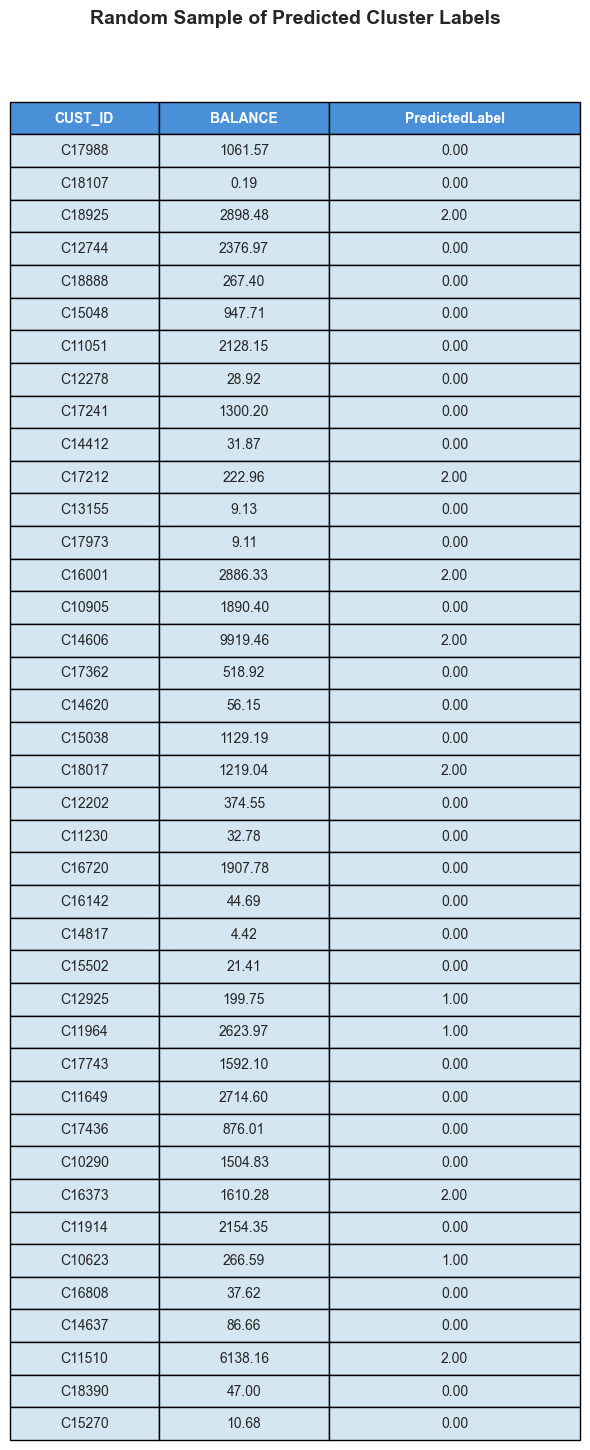

In [29]:
# ===========================================================================================
# Read in Data
# ===========================================================================================
df_CreditData = pd.read_csv('CC_GENERAL.csv')
df_CreditCardForTraining = df_CreditData.copy(deep=True)

#PrintDataFrameStatistics(df_CreditCardForTraining)

# ===========================================================================================
# Create Target Labels (Cluster) for Training
# ===========================================================================================
df_CreditCardForTraining = PerformColumnDropping(df_CreditCardForTraining, ['CUST_ID'])
df_CreditCardForTraining = PerformDataConversion(df_CreditCardForTraining, display_output=False)
df_CreditCardForTraining = PerformDataImputation(df_CreditCardForTraining, display_output=False)

# Scale and cluster
standardScaler = StandardScaler()
scaled = standardScaler.fit_transform(df_CreditCardForTraining)

kmeans = KMeans(n_clusters=3, random_state=315, n_init=10)
cluster_labels = kmeans.fit_predict(scaled)

# =============================================================================
# Test-Train Split
# =============================================================================

X = df_CreditData.copy()  # Keep original (pipeline will preprocess)
y = cluster_labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# ===========================================================================================
# Build Pipeline
# ===========================================================================================
pipeline = Pipeline([
    ('dropper', ColumnDropper(ColumnsToDrop=['CUST_ID'])),
    ('imputer', CreditCardImputer()),
    ('converter', CreditCardDataTypeConverter()),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=315))
])

# ===========================================================================================
# Hyperparameter Tuning - Wrap Pipeline
# Preface hyperparameters for pipeline with step name prefix they apply to
# Pipelines accept a list of dictionaries as paramaters
# sag can typically require 5000-10000 max iterations for convergence
# ===========================================================================================
logistic_params = [
                    {
                        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                        'model__solver': ['lbfgs', 'newton-cg', 'sag'],
                        'model__penalty': ['l2'],
                        'model__max_iter': [500, 1000]
                    },
                    {
                        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                        'model__solver': ['saga'],
                        'model__penalty': ['l1', 'l2'],
                        'model__max_iter': [500, 1000]
                    },
                                        {
                        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                        'model__solver': ['sag'],
                        'model__penalty': ['l2'],
                        'model__max_iter': [5000, 10000]
                    },

                ]

gridSearch = ApplyHyperParameterTuning(pipeline, logistic_params, X_train, y_train)

# ===========================================================================================
# Apply Pipeline to Test Data
# ===========================================================================================
bestPipeline = gridSearch.best_estimator_
y_pred = bestPipeline.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")


# ===========================================================================================
# Apply Pipeline to Full Dataset
# ===========================================================================================
predictedLabels = bestPipeline.predict(df_CreditData)

# Add predictions
df_CreditData['PredictedLabel'] = predictedLabels

#print(df_CreditData[['CUST_ID', 'PredictedLabel']].head())
DisplayTable(df_CreditData[['CUST_ID', 'BALANCE', 'PredictedLabel']].sample(n=40), 
             table_title='Random Sample of Predicted Cluster Labels')

#### **Final Analysis Of Supervised Learning With Cluster Labeling** ####

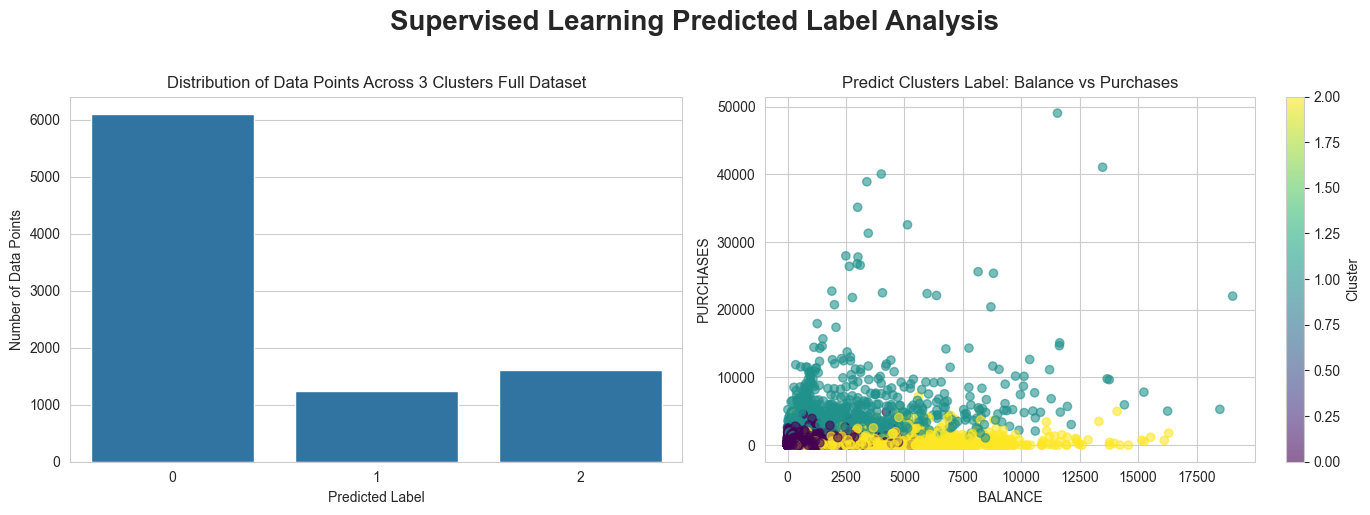

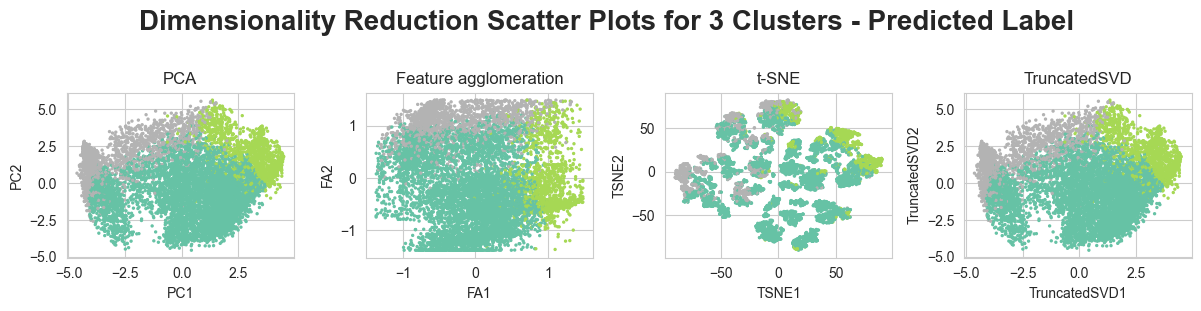

C:\Users\jxbma\AppData\Local\Temp\ipykernel_49556\59886026.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jxbma\AppData\Local\Temp\ipykernel_49556\59886026.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jxbma\AppData\Local\Temp\ipykernel_49556\59886026.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


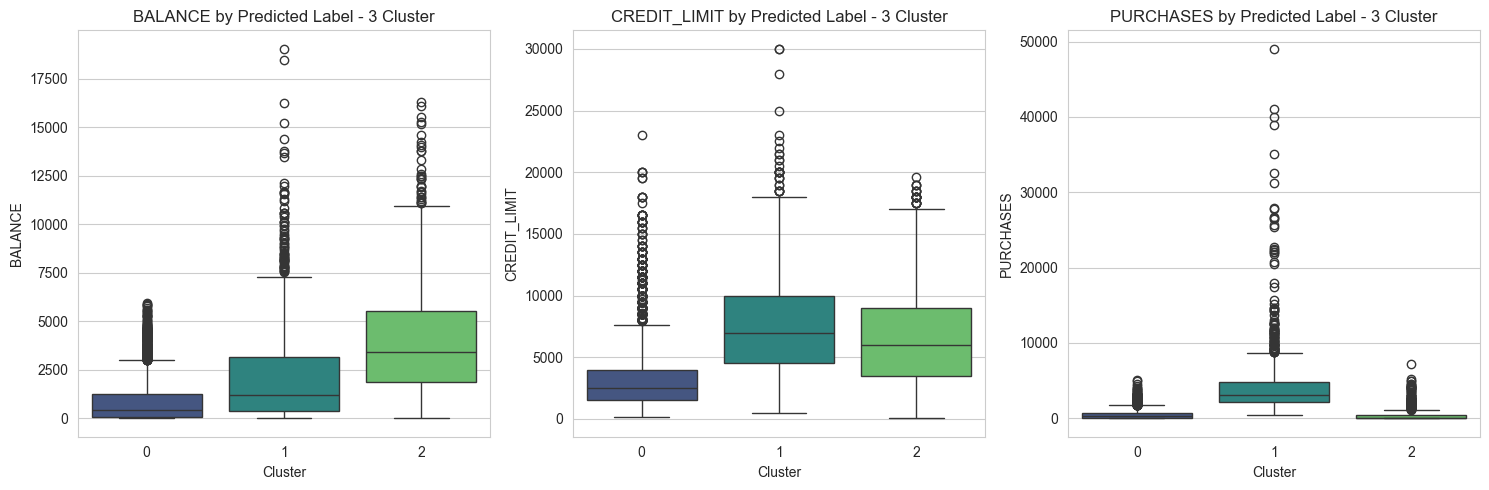

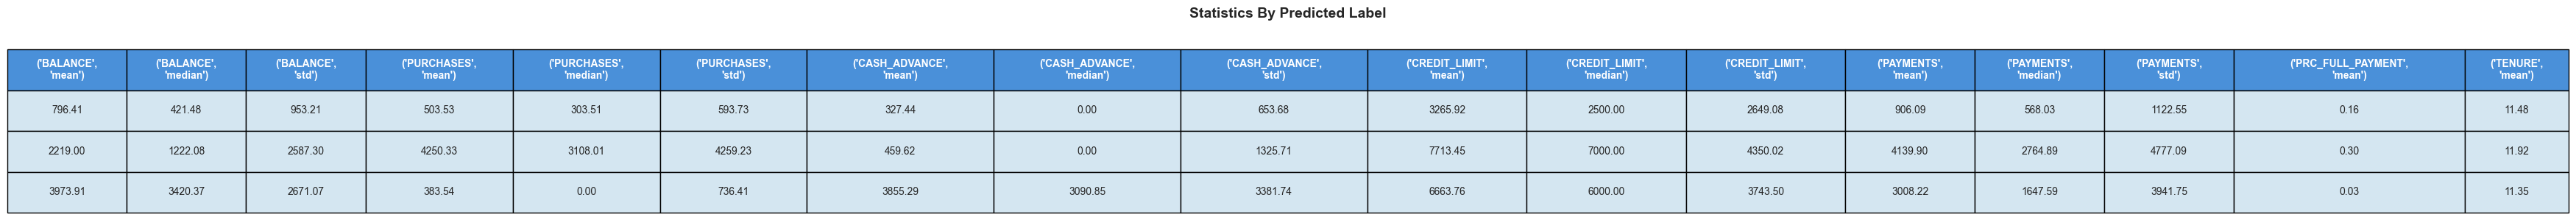

In [30]:
# Find Me

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()

# Create a visualization to show the distribution of data points across clusters
sns.countplot(x='PredictedLabel', data=df_CreditData, ax=axes[0])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Number of Data Points')
axes[0].set_title('Distribution of Data Points Across 3 Clusters Full Dataset')

scatter = axes[1].scatter(
                x=df_CreditData['BALANCE'],        # Feature 1
                y=df_CreditData['PURCHASES'],      # Feature 2
                c=df_CreditData['PredictedLabel'], # Color by cluster
                cmap='viridis',                    # Color scheme
                alpha=0.6                          # Transparency
            )
plt.colorbar(scatter, label='Cluster')
axes[1].set_xlabel('BALANCE')
axes[1].set_ylabel('PURCHASES')
axes[1].set_title('Predict Clusters Label: Balance vs Purchases')

plt.suptitle(f'Supervised Learning Predicted Label Analysis', y=1.02, fontsize=20, fontweight='bold')
plt.subplots_adjust(top=0.92)  

plt.tight_layout()
plt.show()
print()
print()

DisplayScatterPlots(df_CreditData['PredictedLabel'], '3 Clusters - Predicted Label')

features = ['BALANCE', 'CREDIT_LIMIT', 'PURCHASES']

df_melted = df_CreditData.melt(
    id_vars=['PredictedLabel'],
    value_vars=features,
    var_name='Feature',
    value_name='Value'
)

features = ['BALANCE', 'CREDIT_LIMIT', 'PURCHASES']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, features):
    sns.boxplot(
        data=df_CreditData,
        x='PredictedLabel',
        y=feature,
        palette='viridis',
        ax=ax
    )
    ax.set_title(f'{feature} by Predicted Label - 3 Cluster')
    ax.set_xlabel('Cluster')

plt.tight_layout()
plt.show()


# Aggregate statistics by cluster
df_ClusterProfile = df_CreditData.groupby('PredictedLabel').agg({
                        'BALANCE': ['mean', 'median', 'std'],
                        'PURCHASES': ['mean', 'median', 'std'],
                        'CASH_ADVANCE': ['mean', 'median', 'std'],
                        'CREDIT_LIMIT': ['mean', 'median', 'std'],
                        'PAYMENTS': ['mean', 'median', 'std'],
                        'PRC_FULL_PAYMENT': 'mean',
                        'TENURE': 'mean'
                    }).round(2)

DisplayTable(df_ClusterProfile, table_title='Statistics By Predicted Label')

### **Final Analysis and Recap** ##
In general I tried to sprinkle explanations and analysis through the workbook.

#### **Actions completed** ####
    - 	Performed Basic EDA
	- 	Imputed Missing Values
	- 	Data Type Conversion
	- 	Examined Feature Distributions
	- 	Identified Outliers
	- 	Analyzed Normalization Techniques
	- 	Normalized Distributions using Yeo-Johnson
	- 	Capped Outliers using Winsorization
	- 	Performed KMeans, Hierarchical and DBSCAN Clustering
	- 	Examined Clustering results using Elbow Method and Silhouette Analysis
	- 	Visualized Clusters with Dimensionality Reduction 
	- 	PCA, Feature Agglomeration, t-SNE, TruncatedSVD
	- 	KMeans - 3 Clusters
	- 	Supervised Learning - LogisticRegression() and RandomForestClassifier() 
	- 	Compared Supervised Learning Model Results
	- 	Cross Validation of model results
	- 	Hyperparameter Tuning for 3 Clusters - LogisticRegression() and RandomForestClassifier()
	- 	Created Pipeline
	- 	Applied Hyperparameter Tuning for optimal pipeline-model performance
	- 	Run Model against entire dataset (from disk)
	- 	Performed some basic analytical plotting of Predicted Labels
    
##### **Initial load and EDA analysis uncovering the following initial observations:** #####
    - 8950 rows of data
    - 18 columns of data:
        - 1 categorical feature
        - 17 numerical features
    - 314 rows with missing values
    - Needed to for some data type conversion for performance/memory considerations
    - Most features had a Right-Skewed distributions
    - Remaining features where Left-Skewed or Normal-ish distributions
##### **Which Clustering Algorithm worked the best** #####
    - KMeans with 3 clusters seemed to work the best.
    - It seemed to provided clearer sets of clusters.
    - Using 3 clusters made the data easier to visualize/understand (low, medium, high)
##### **Which Dimensionality Reduction Techniques you used / preferred** ######
    - Used PCA, Feature Agglomeration, t-SNE, TruncatedSVD for dimensionality reduction
    - Most features were numerical and PCA is well suited
    - KMeans and PCA distanced based and work together
##### **Summarize the Supervised Learning Process** #####
    - Despite predicting a numerical feature label, this was a Classification problem
    - Classification is used for discrete labels (0, 1, 2..) - Predicted label has a specific value, not values "between" labels
    - Regression is used for continuous numerical values
##### **Which Algorithm?** #####
    - Looked at LogisticRegression() and RandomForestClassifier()
    - Due to overfitting concerns, decided on Hyperparameter tuned LogisticRegression()
LogisticRegression performed better. </br>
Higher test accuracy (99.4% vs 97.1%)</br>
Higher CV accuracy (99.6% vs 96.8%)</br>
Less overfitting (smaller train-test gap)</br>
RandomForest's perfect 1.0 train accuracy = memorizing training data</br>
##### **How did you score your models?** #####
    - F1-Score and accuracy, examined confusion matrix
    - Probably should have looked at precision, recall and roc_auc_score
##### **Last Thoughts and Comments** #####
    - Realized that what I did was probably overkill (50lb sledge hammer for a finishing nail), but these capstones are a great vehicle for experimentation and continually refining the process of EDA and model building
    - Good vehicle for iteratively creating a useful library of software functions/methods/tools for future reuse
    - Pipelines are much more customizable and flexible than I thought (and once you understand the patterns, relatively straightforward)
    - Simpler is often better/easier to analyze in terms of model building and clustering
    - This applies to model/notebook buiding as well; as I refine my skillset the goal is streamline my notebook designs